#  Imports

In [ ]:
import numpy as np
from pathlib import Path
from itertools import combinations

from load_saved_model import load_all_folds, predict, verify_architecture

from xai_utils import (
    get_code_dir,
    load_outer_fold_test_data,
    compute_ig_attributions,
    aggregate_attributions_to_subjects,
    aggregate_group_importance,
    plot_subject_attribution,
    channel_names,
    anterior_to_posterior,
    get_correctly_classified_subset,
    LogitDiffWrapper,
)

from config import DATA_PATH

c:\Users\Online\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Path setup

In [ ]:
CODE_DIR = get_code_dir()
PROJECT_DIR = CODE_DIR.parent
MODELS_DIR = PROJECT_DIR / "output" / "models"

DATA_NPZ_PATH = DATA_PATH
FOLDS_DIR = PROJECT_DIR / "output" / "fold_indices"

# Load trained fold models and sanity-check architecture

In [3]:
all_models = load_all_folds(models_dir=str(MODELS_DIR))
print("Loaded folds:", list(all_models.keys()))

for fold_idx, loaded in all_models.items():
    print(f"\n{'=' * 20} OUTER FOLD {fold_idx} {'=' * 20}")
    print(verify_architecture(loaded))

Loaded folds: [0, 1, 2, 3, 4]

==================== OUTER FOLD 0 ====================
{'outer_fold': 0, 'declared_use_pooling': True, 'conv_config': [(32, 3), (64, 3), (128, 3)], 'final_feature_map_shape': (1, 128, 9, 9)}

==================== OUTER FOLD 1 ====================
{'outer_fold': 1, 'declared_use_pooling': True, 'conv_config': [(16, 3), (32, 3)], 'final_feature_map_shape': (1, 32, 9, 9)}

==================== OUTER FOLD 2 ====================
{'outer_fold': 2, 'declared_use_pooling': True, 'conv_config': [(16, 3), (32, 3)], 'final_feature_map_shape': (1, 32, 9, 9)}

==================== OUTER FOLD 3 ====================
{'outer_fold': 3, 'declared_use_pooling': True, 'conv_config': [(16, 3), (32, 3), (64, 3)], 'final_feature_map_shape': (1, 64, 9, 9)}

==================== OUTER FOLD 4 ====================
{'outer_fold': 4, 'declared_use_pooling': True, 'conv_config': [(32, 3), (64, 3)], 'final_feature_map_shape': (1, 64, 9, 9)}


# Compute IG subject maps fold by fold

In [4]:
all_subject_ig = {}
subject_meta = {}

for fold_idx, loaded in all_models.items():

    X_raw_test, y_test, epoch_subject_ids = load_outer_fold_test_data(
        fold_idx=fold_idx,
        data_npz_path=str(DATA_NPZ_PATH),
        folds_dir=str(FOLDS_DIR),
    )

    # Epoch-level probabilities
    probs = predict(loaded, X_raw_test)

    # ---------------------------------------------------------
    # Determine SUBJECT-level predictions first
    # ---------------------------------------------------------
    unique_subjects = np.unique(epoch_subject_ids)

    subject_pred_for_epoch = np.empty(len(epoch_subject_ids), dtype=int)

    for subj in unique_subjects:

        mask = epoch_subject_ids == subj

        subj_true = int(y_test[mask][0])
        subj_mean_prob_ad = float(probs[mask, 1].mean())
        subj_pred = int(subj_mean_prob_ad >= 0.5)

        # Assign the SUBJECT prediction to every epoch
        # belonging to that subject
        subject_pred_for_epoch[mask] = subj_pred

        subject_meta[subj] = {
            "y_true": subj_true,
            "y_pred": subj_pred,
            "mean_prob_ad": subj_mean_prob_ad,
            "fold": fold_idx,
        }

    # ---------------------------------------------------------
    # IG using the SUBJECT PREDICTED LABEL as target
    # ---------------------------------------------------------
    A_ig = compute_ig_attributions(
        loaded,
        X_raw_test,
        target=subject_pred_for_epoch,
        batch_size=4,
        n_steps=100
    )

    # Average epoch attributions -> subject attribution map
    subj_ig = aggregate_attributions_to_subjects(
        A_ig,
        epoch_subject_ids
    )

    all_subject_ig.update(subj_ig)

    print(
        f"Fold {fold_idx}: "
        f"{len(unique_subjects)} subjects -> "
        f"{sorted(unique_subjects.tolist())}"
    )


[data] Filtered to binary task AD vs CN: 4875 epochs from 65 subjects (36 AD, 29 CN)
[load_outer_fold_test_data] Fold 0: 975 test epochs across 13 subjects.
Fold 0: 13 subjects -> [17, 18, 20, 23, 25, 34, 36, 43, 45, 50, 54, 60, 64]
[data] Filtered to binary task AD vs CN: 4875 epochs from 65 subjects (36 AD, 29 CN)
[load_outer_fold_test_data] Fold 1: 975 test epochs across 13 subjects.
Fold 1: 13 subjects -> [1, 9, 10, 19, 22, 29, 30, 32, 40, 48, 49, 56, 62]
[data] Filtered to binary task AD vs CN: 4875 epochs from 65 subjects (36 AD, 29 CN)
[load_outer_fold_test_data] Fold 2: 975 test epochs across 13 subjects.
Fold 2: 13 subjects -> [2, 7, 8, 24, 26, 27, 31, 42, 44, 46, 57, 58, 63]
[data] Filtered to binary task AD vs CN: 4875 epochs from 65 subjects (36 AD, 29 CN)
[load_outer_fold_test_data] Fold 3: 975 test epochs across 13 subjects.
Fold 3: 13 subjects -> [3, 4, 6, 12, 14, 16, 21, 37, 47, 51, 52, 55, 65]
[data] Filtered to binary task AD vs CN: 4875 epochs from 65 subjects (36 AD

# Inspect subject-level attribution map :

## Confusion matrix subject-level maps

### True Positive

Correctly classified AD subjects: 23
[np.int64(17), np.int64(18), np.int64(20), np.int64(34), np.int64(1), np.int64(19), np.int64(22), np.int64(29), np.int64(30), np.int64(7), np.int64(8), np.int64(24), np.int64(26), np.int64(27), np.int64(4), np.int64(12), np.int64(14), np.int64(16), np.int64(21), np.int64(5), np.int64(13), np.int64(28), np.int64(35)]

Subject: 17 | True: AD | Predicted: AD | Mean P(AD): 0.548


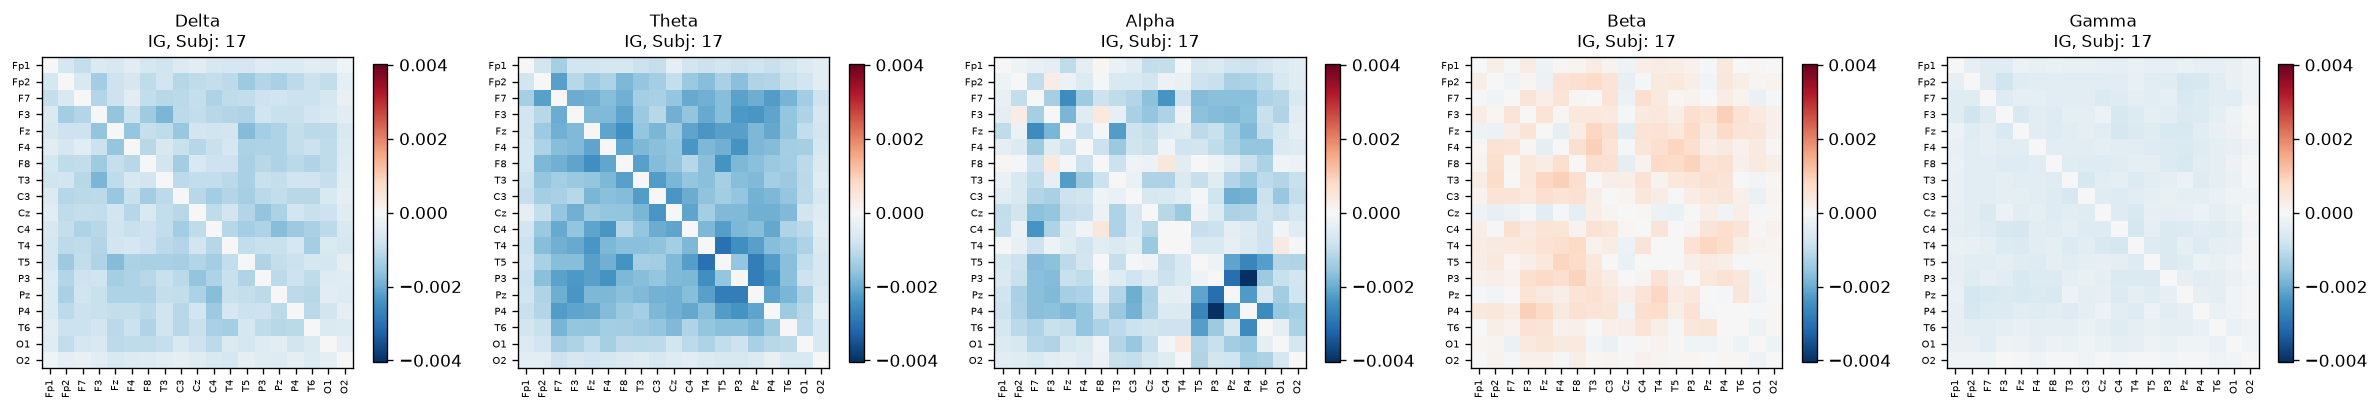


Subject: 18 | True: AD | Predicted: AD | Mean P(AD): 0.505


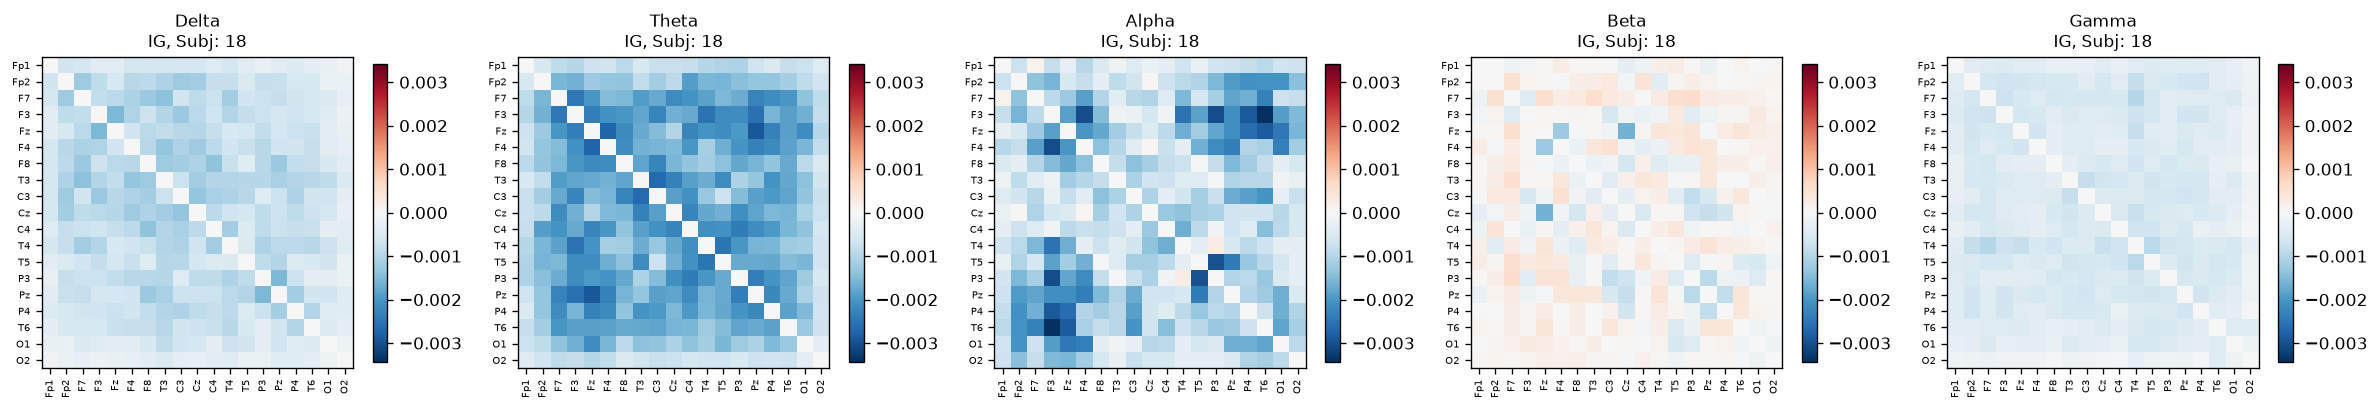


Subject: 20 | True: AD | Predicted: AD | Mean P(AD): 0.522


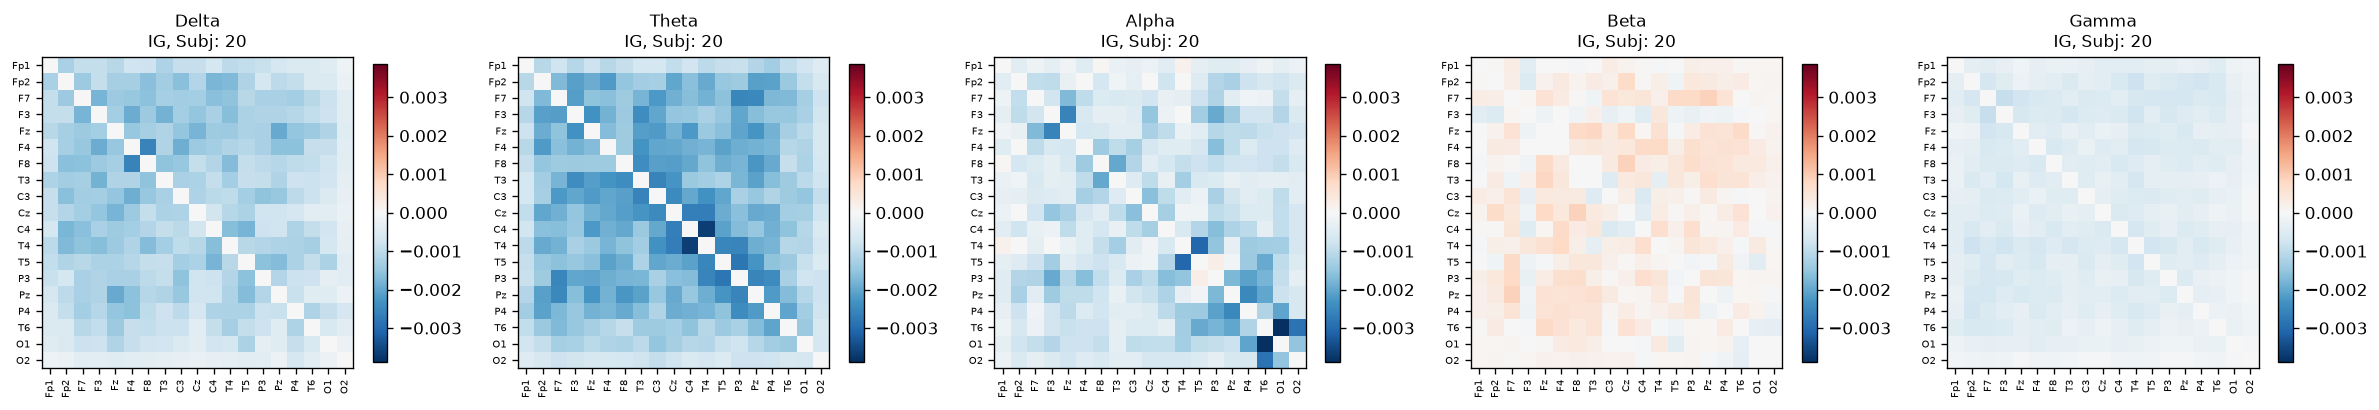


Subject: 34 | True: AD | Predicted: AD | Mean P(AD): 0.541


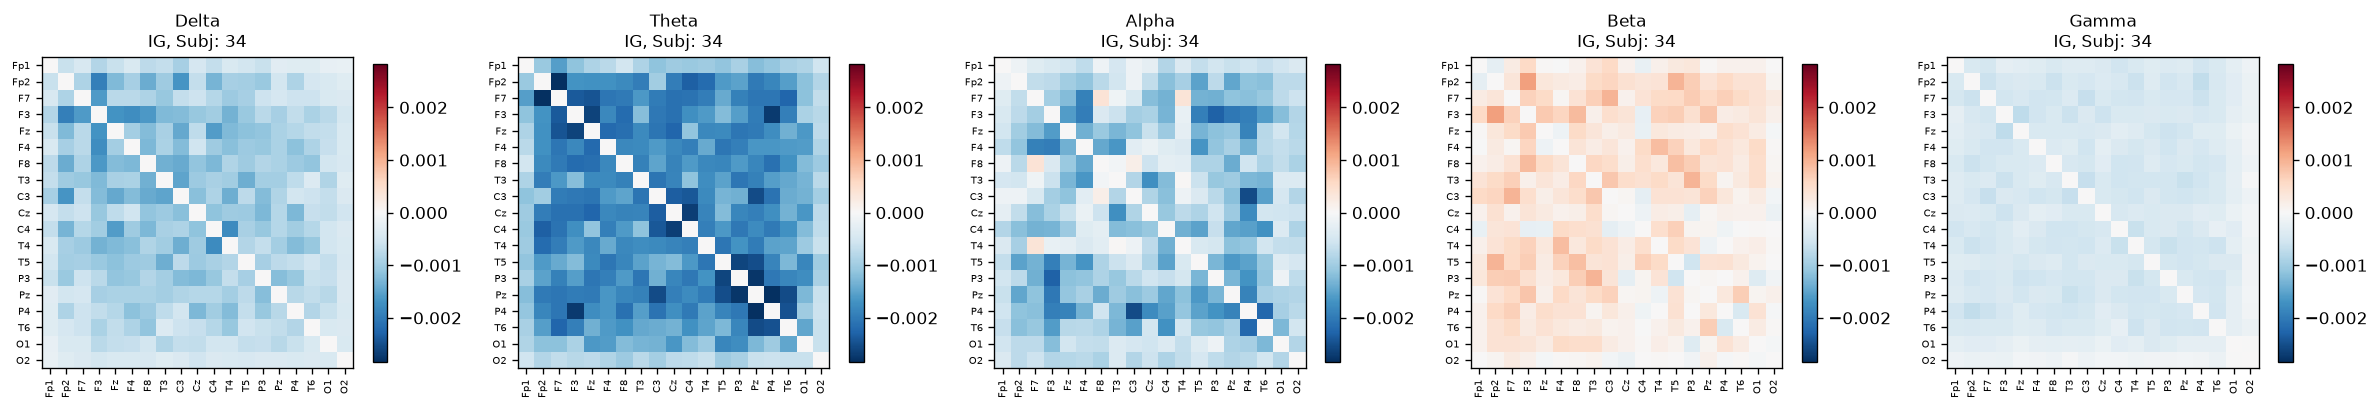


Subject: 1 | True: AD | Predicted: AD | Mean P(AD): 0.622


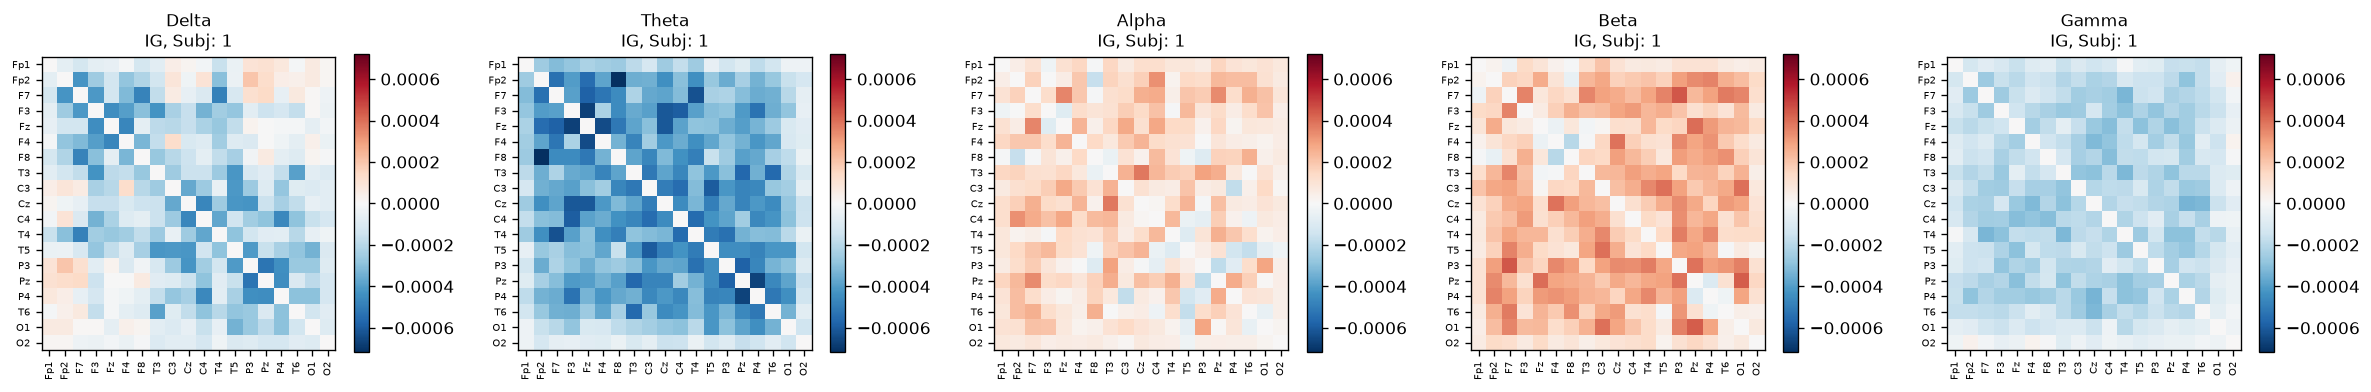


Subject: 19 | True: AD | Predicted: AD | Mean P(AD): 0.507


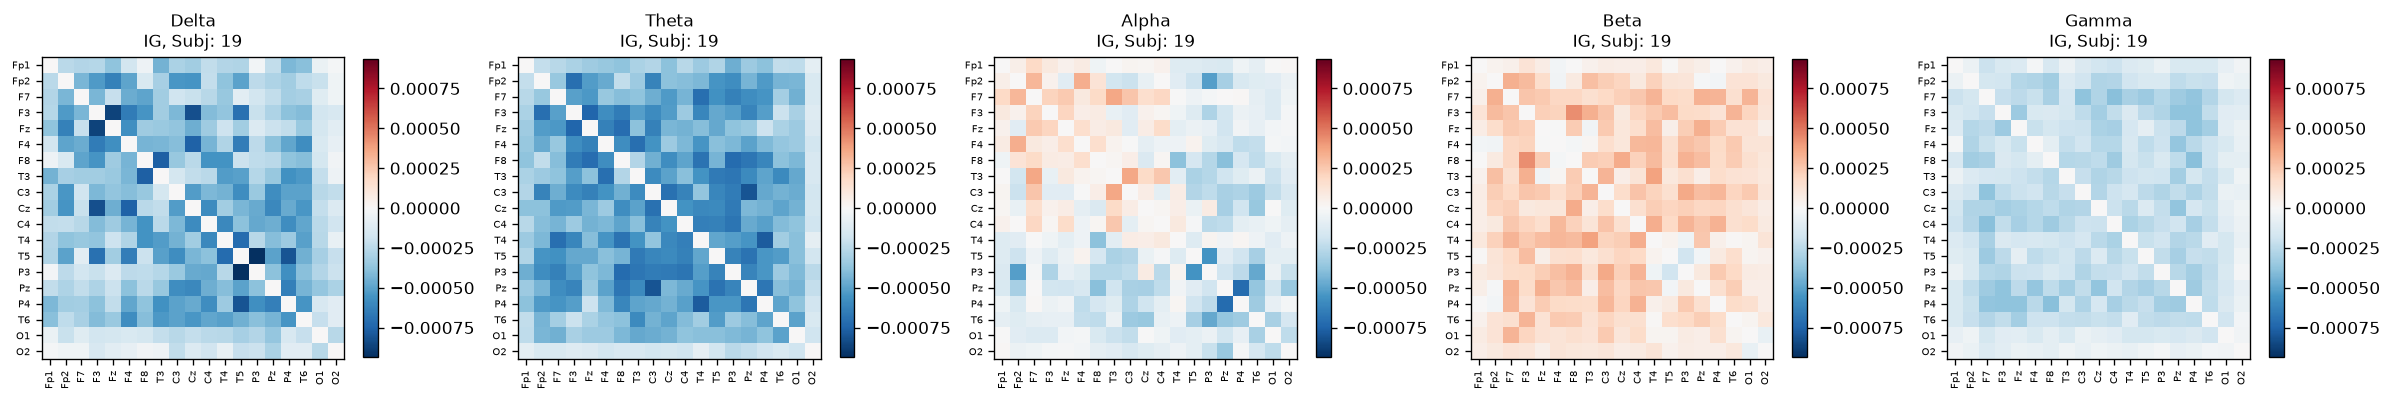


Subject: 22 | True: AD | Predicted: AD | Mean P(AD): 0.559


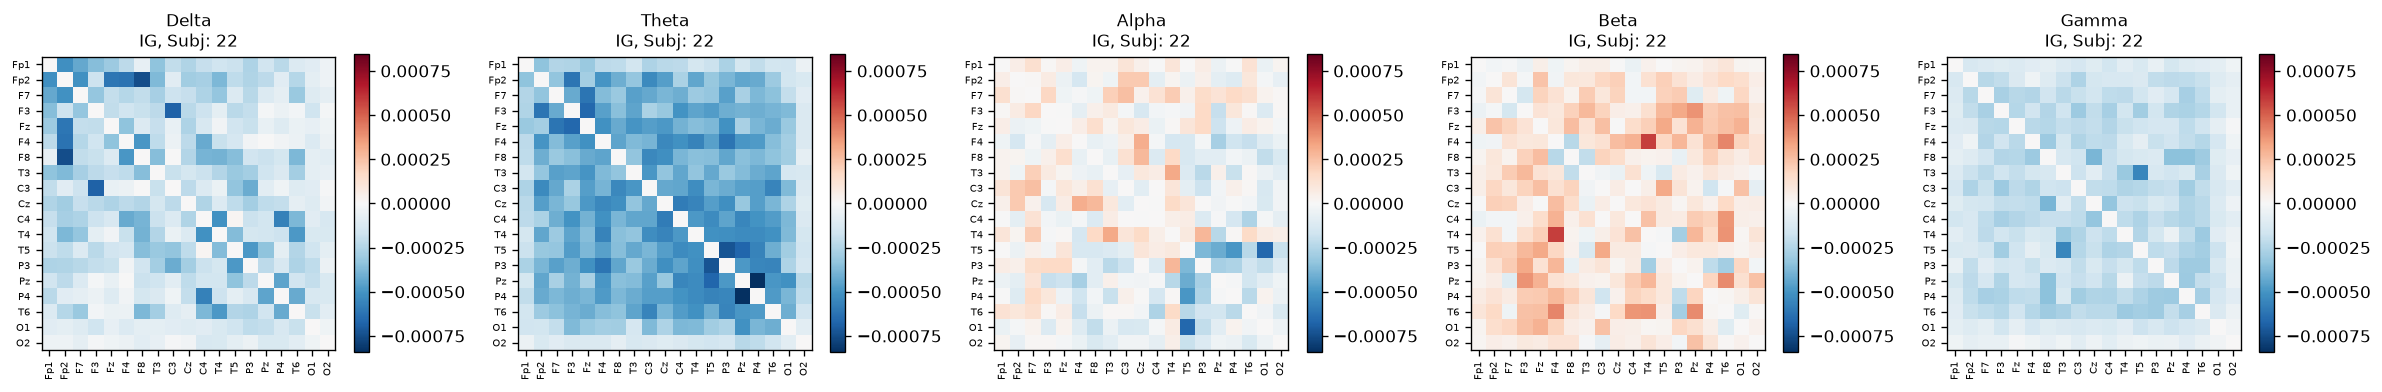


Subject: 29 | True: AD | Predicted: AD | Mean P(AD): 0.592


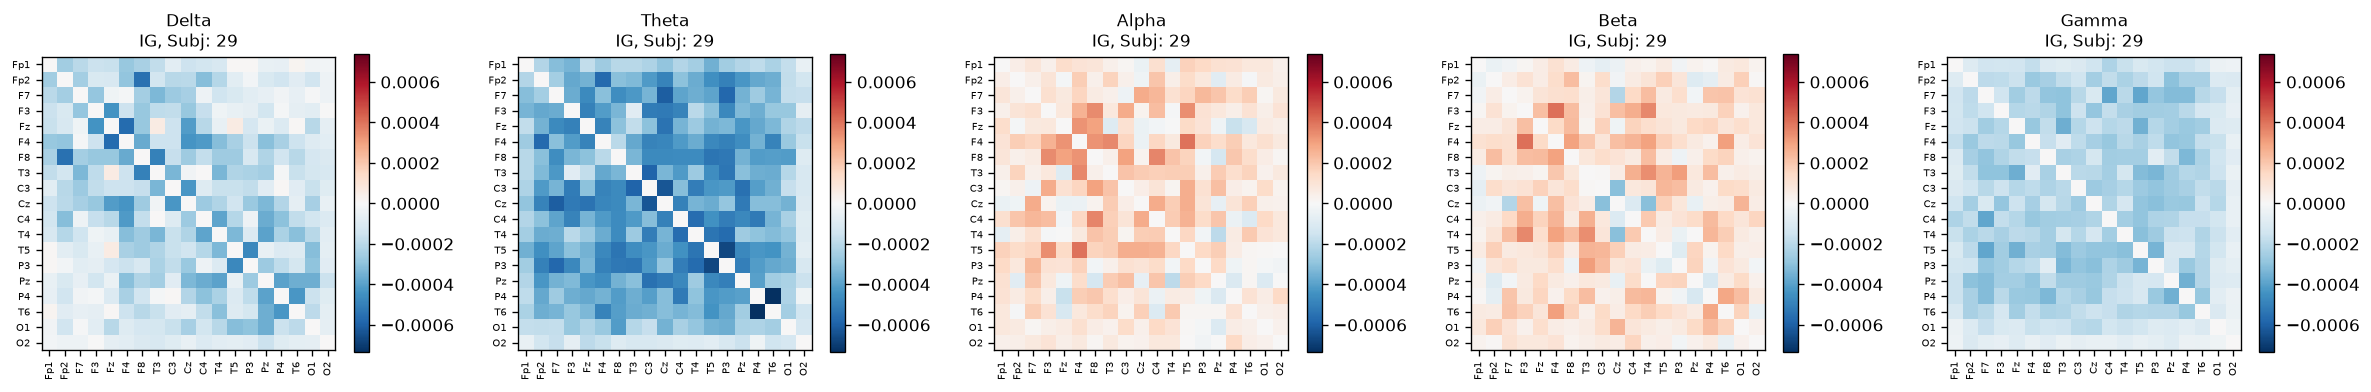


Subject: 30 | True: AD | Predicted: AD | Mean P(AD): 0.545


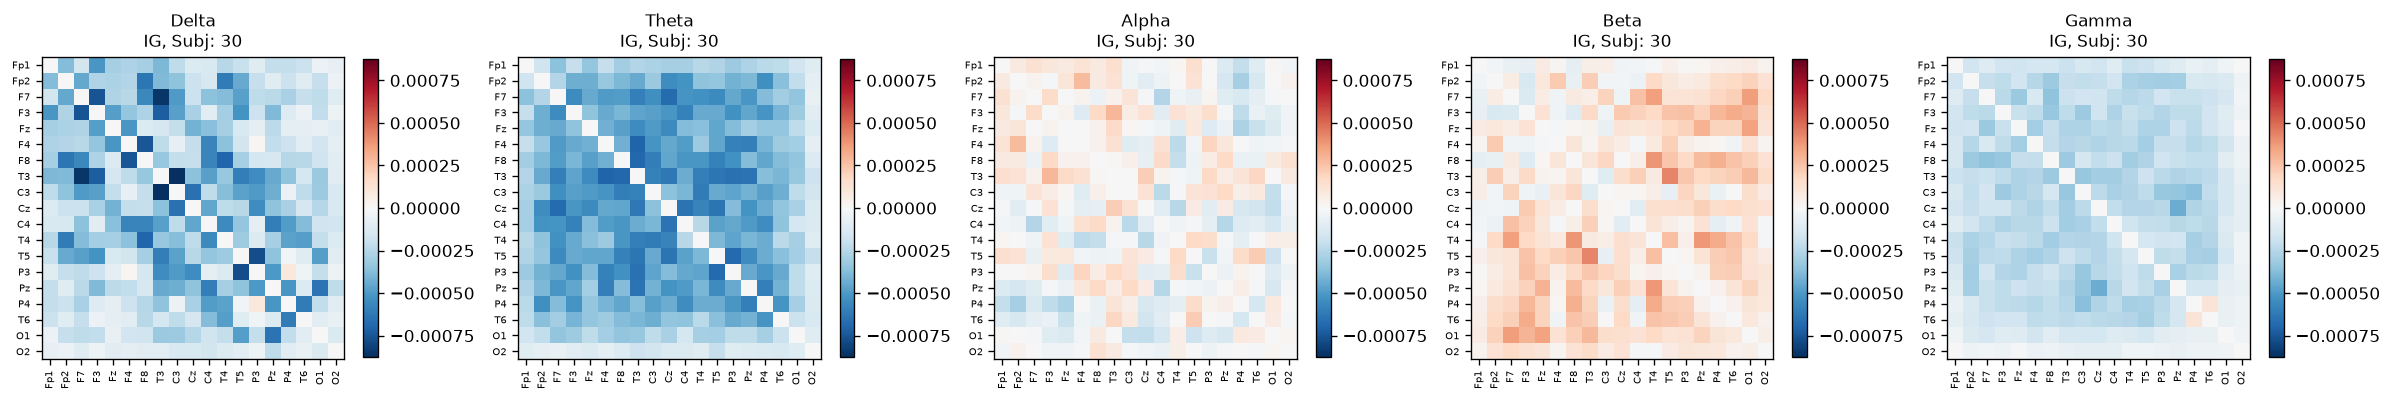


Subject: 7 | True: AD | Predicted: AD | Mean P(AD): 0.554


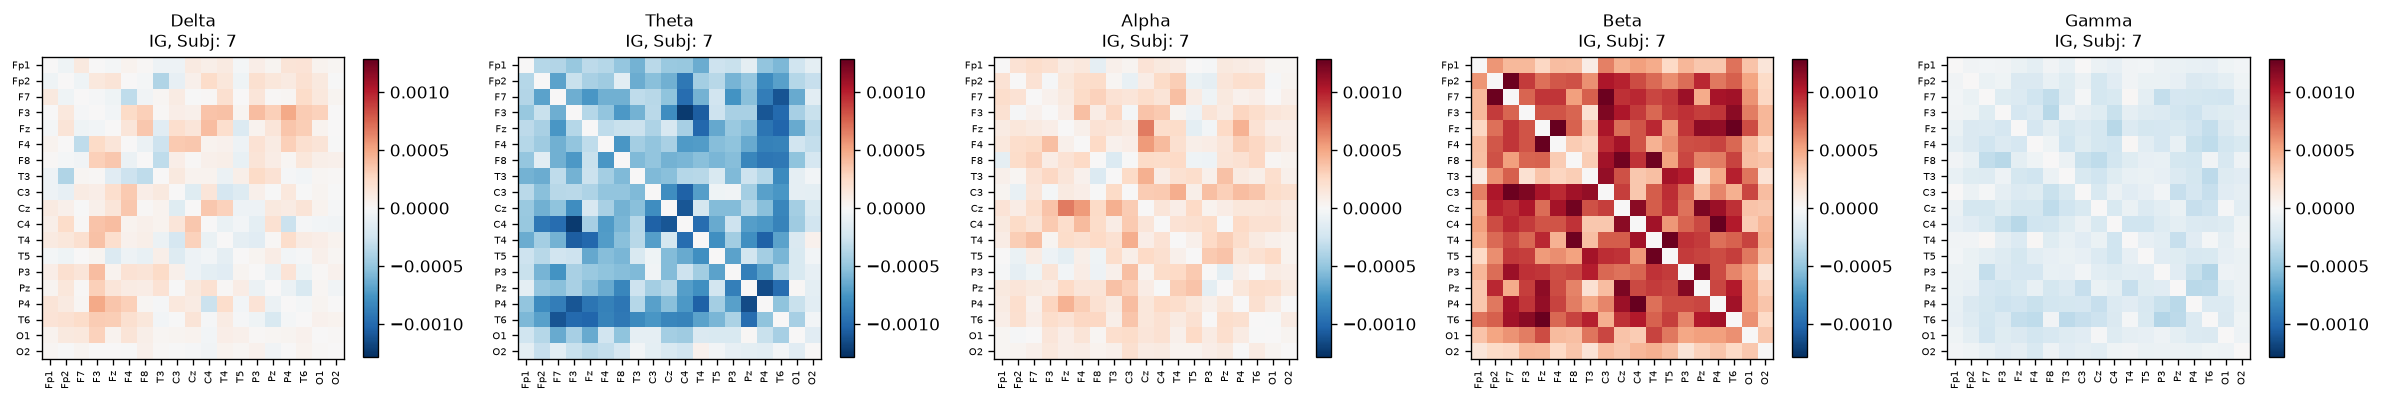


Subject: 8 | True: AD | Predicted: AD | Mean P(AD): 0.515


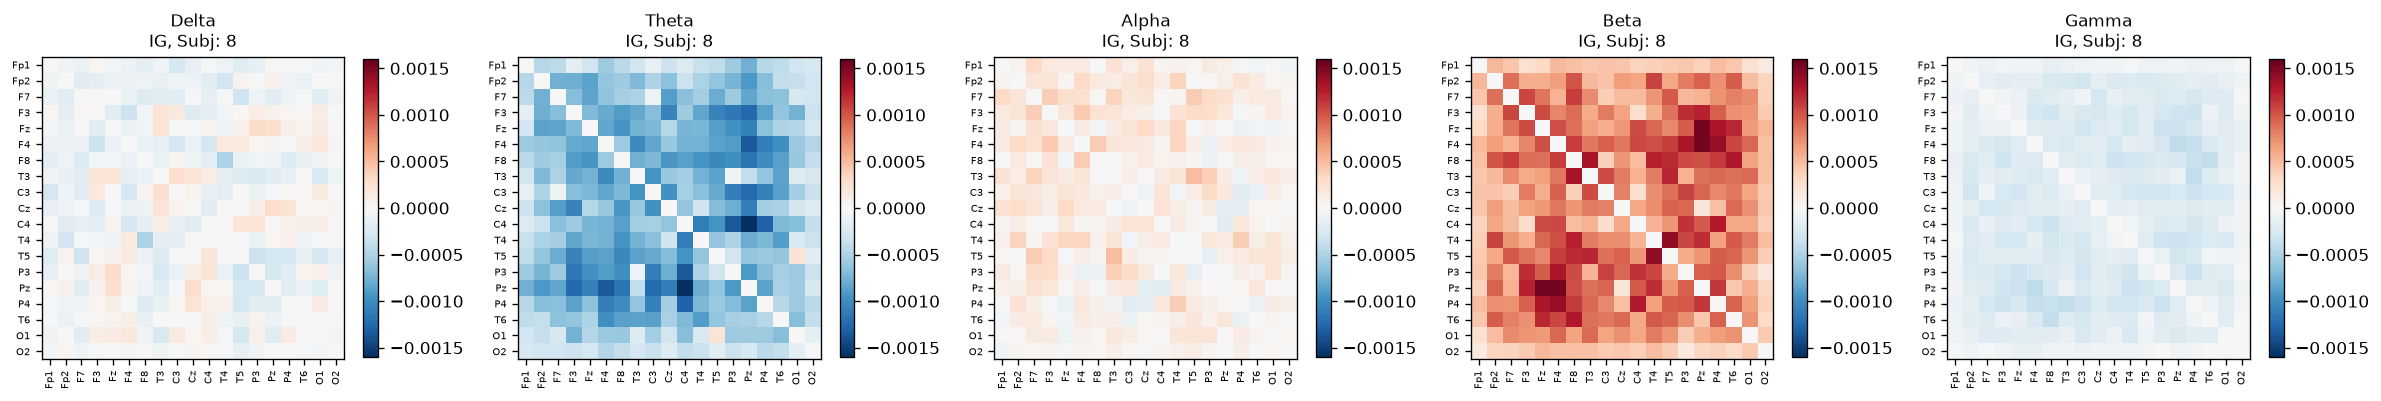


Subject: 24 | True: AD | Predicted: AD | Mean P(AD): 0.541


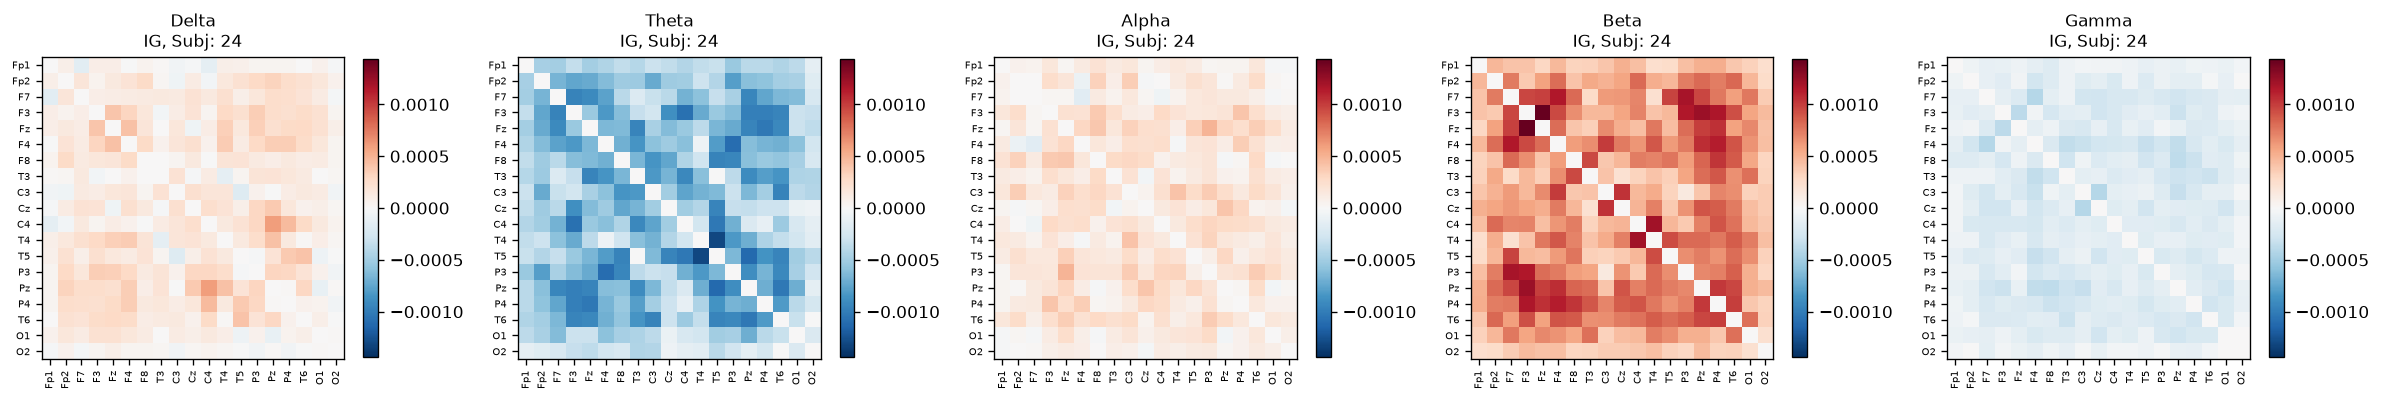


Subject: 26 | True: AD | Predicted: AD | Mean P(AD): 0.537


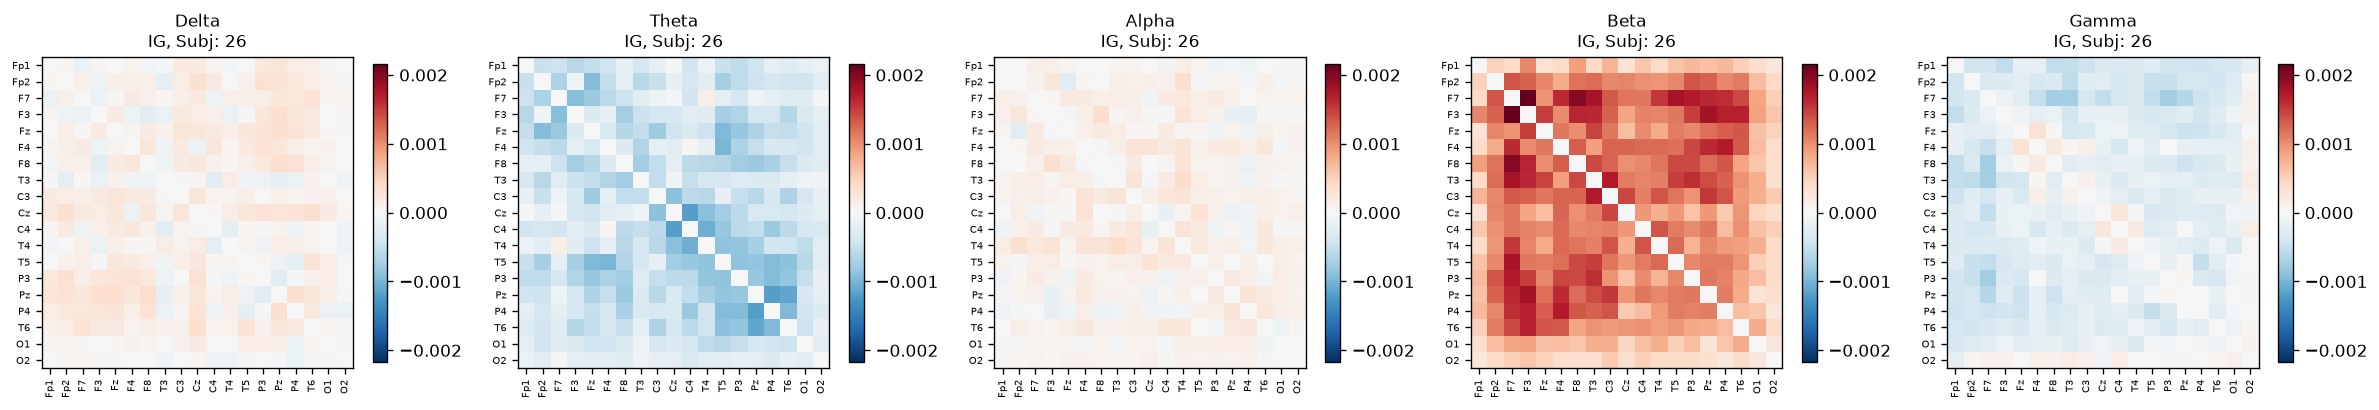


Subject: 27 | True: AD | Predicted: AD | Mean P(AD): 0.627


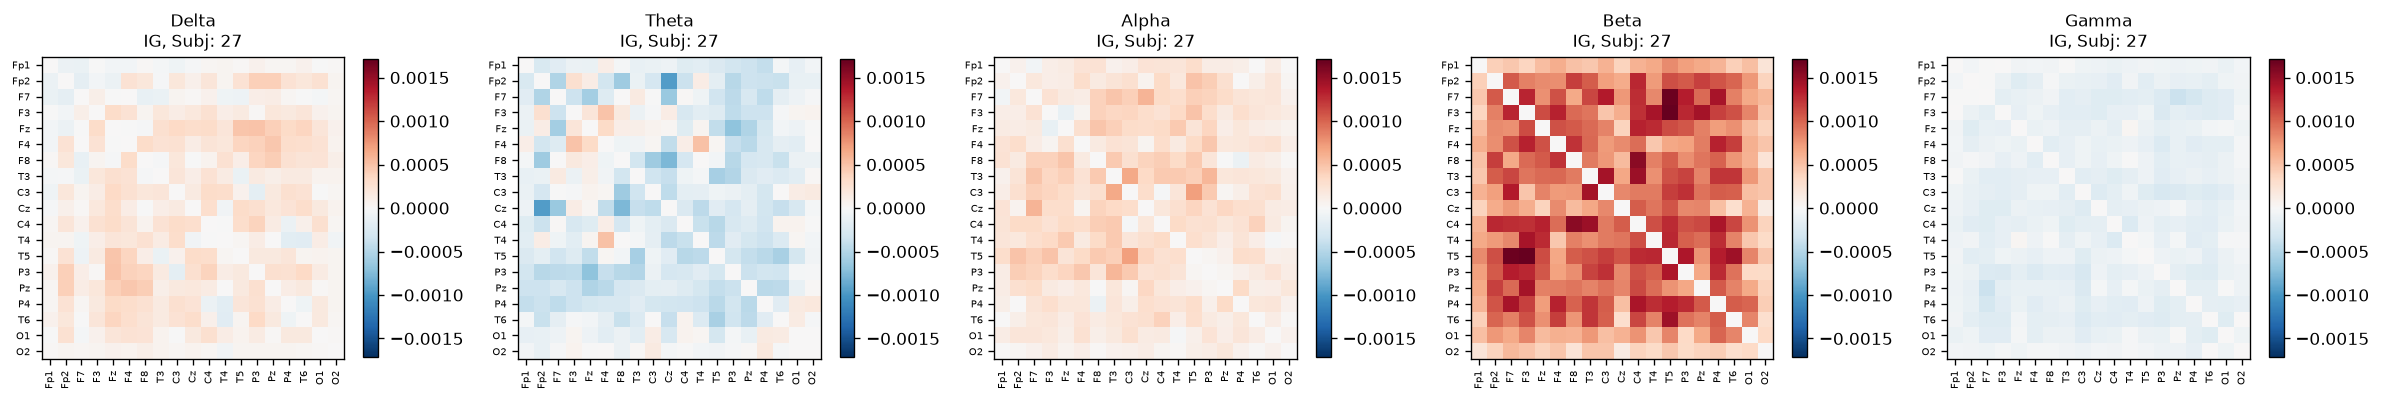


Subject: 4 | True: AD | Predicted: AD | Mean P(AD): 0.563


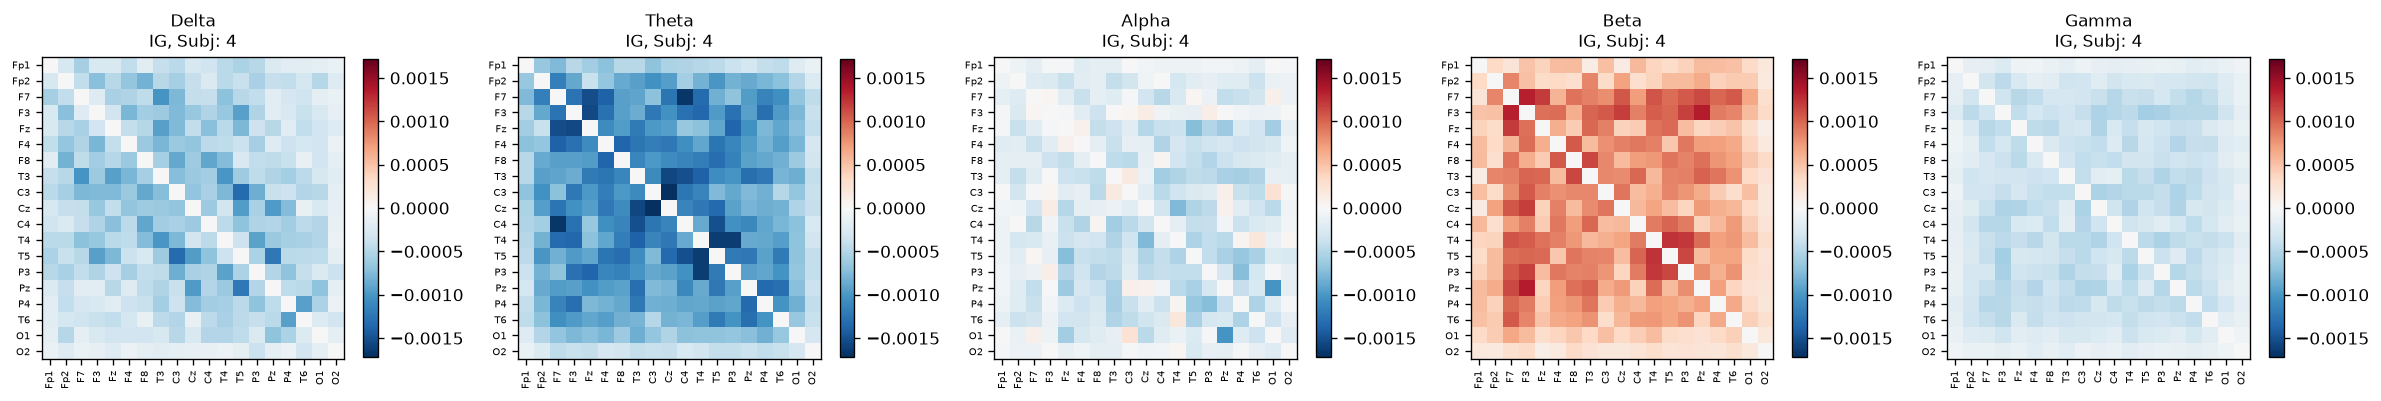


Subject: 12 | True: AD | Predicted: AD | Mean P(AD): 0.516


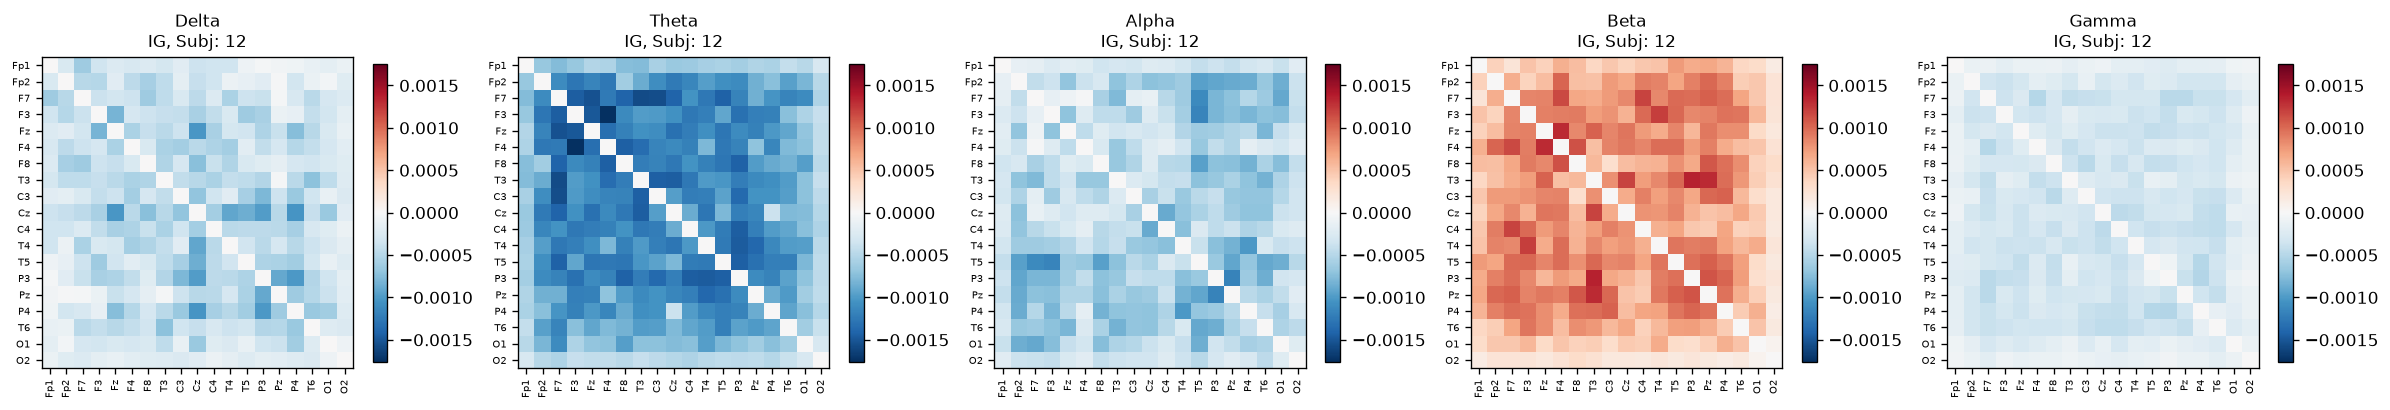


Subject: 14 | True: AD | Predicted: AD | Mean P(AD): 0.567


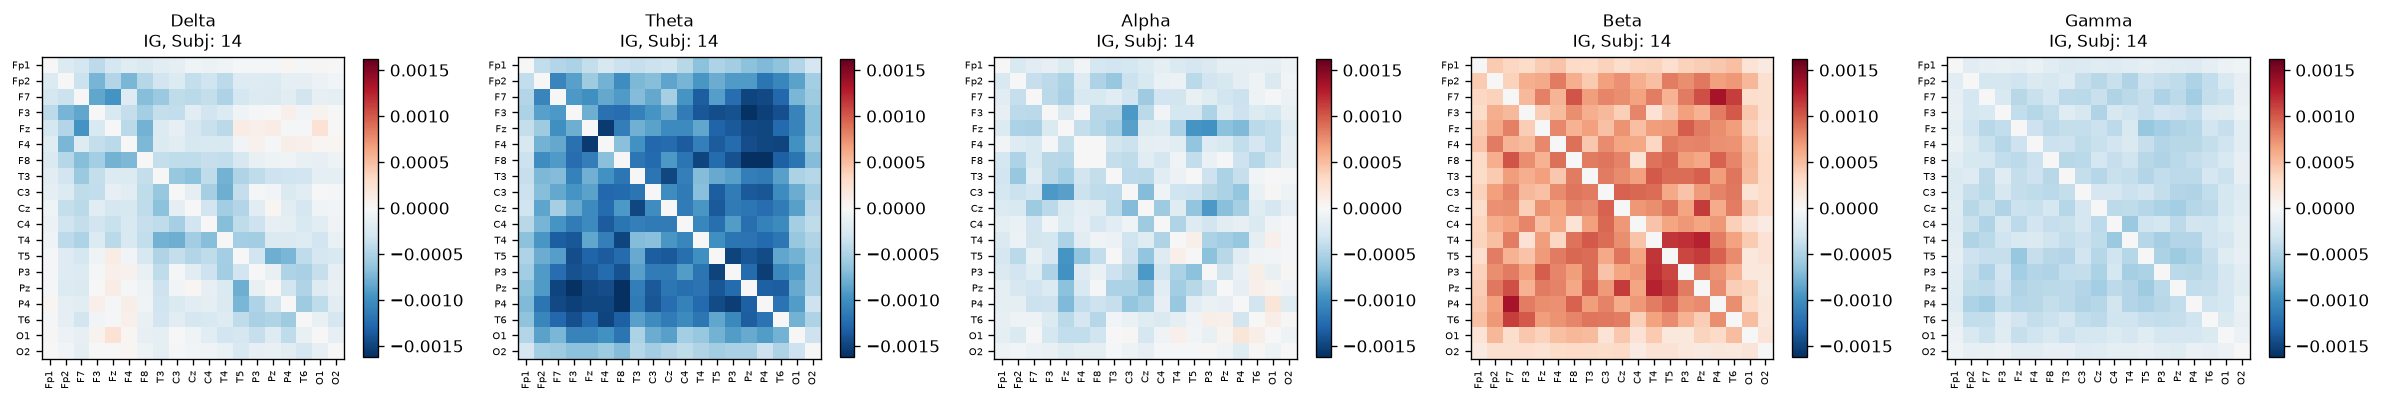


Subject: 16 | True: AD | Predicted: AD | Mean P(AD): 0.554


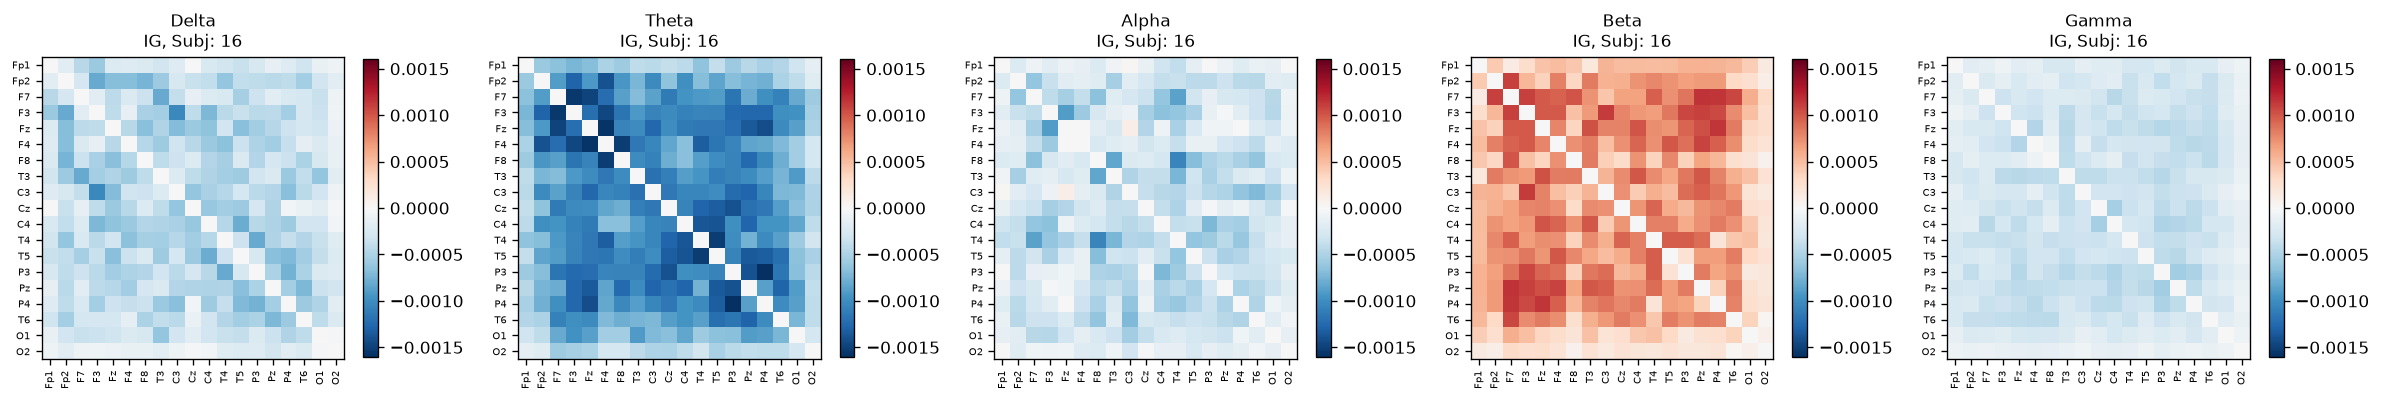


Subject: 21 | True: AD | Predicted: AD | Mean P(AD): 0.522


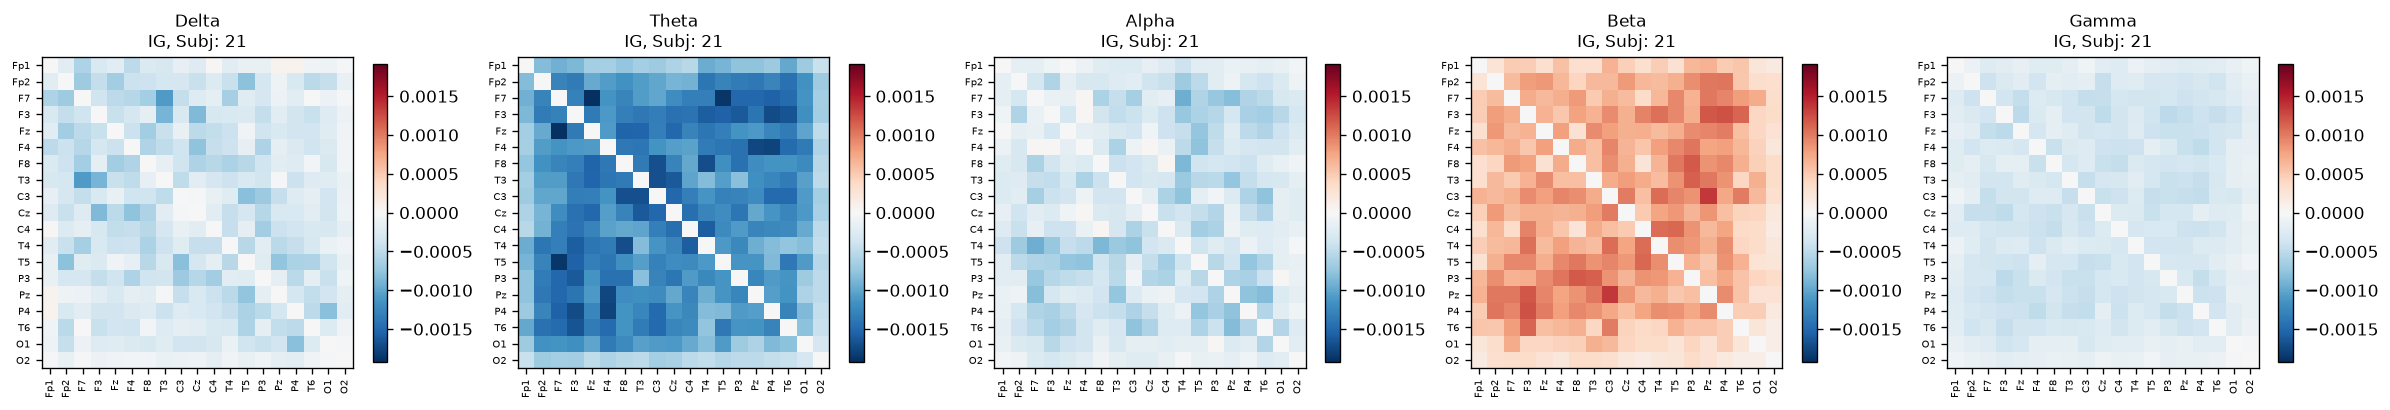


Subject: 5 | True: AD | Predicted: AD | Mean P(AD): 0.511


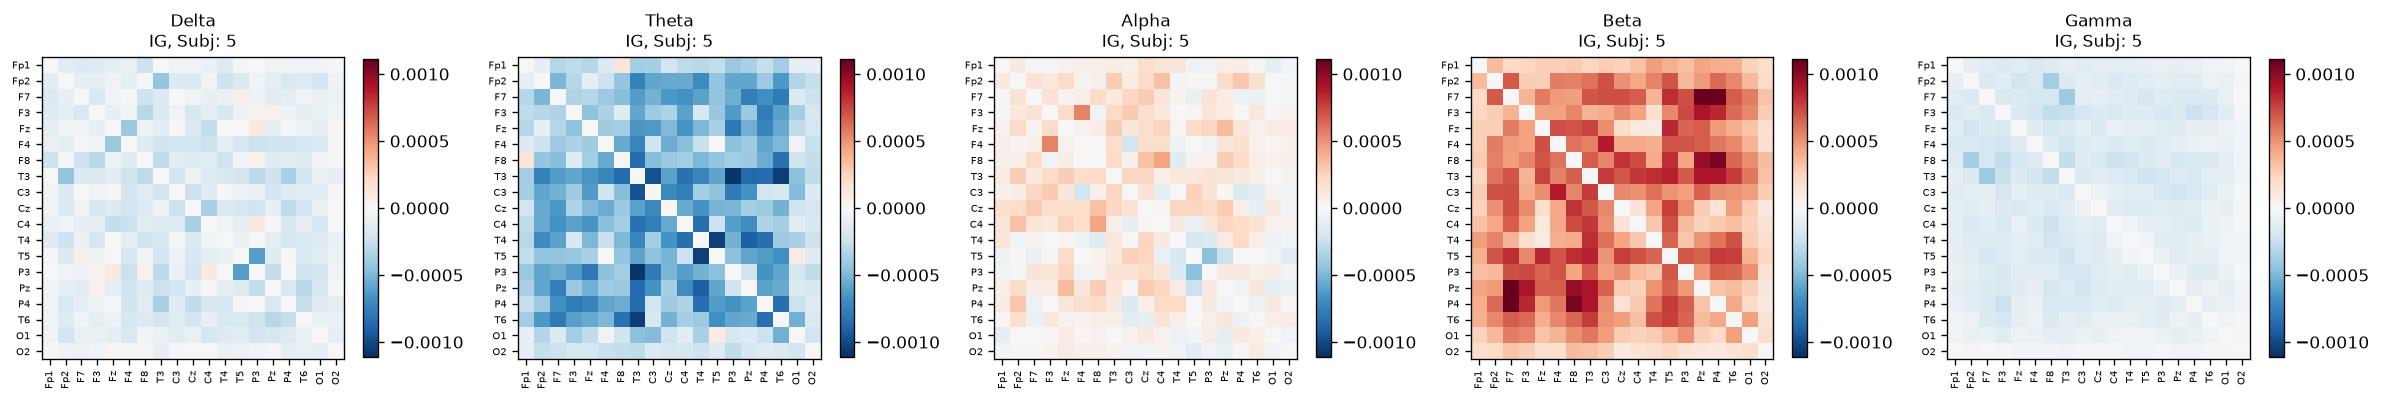


Subject: 13 | True: AD | Predicted: AD | Mean P(AD): 0.531


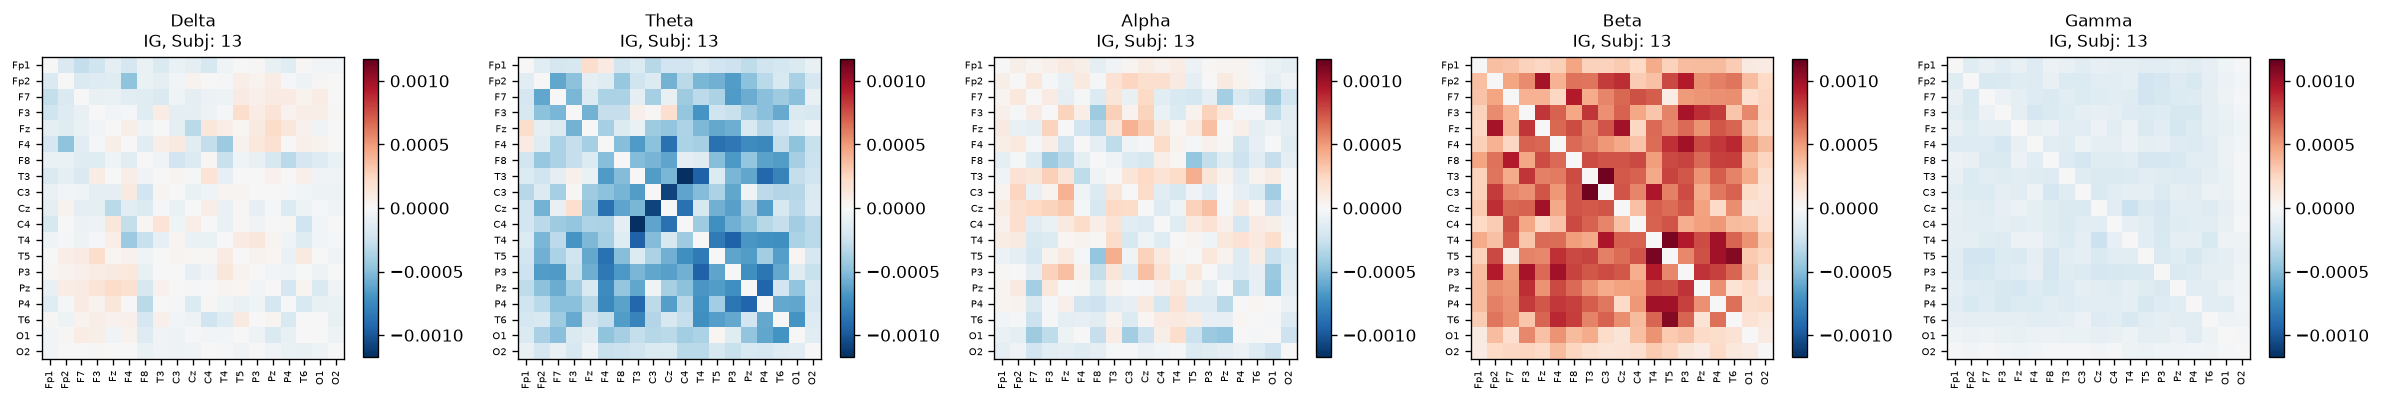


Subject: 28 | True: AD | Predicted: AD | Mean P(AD): 0.531


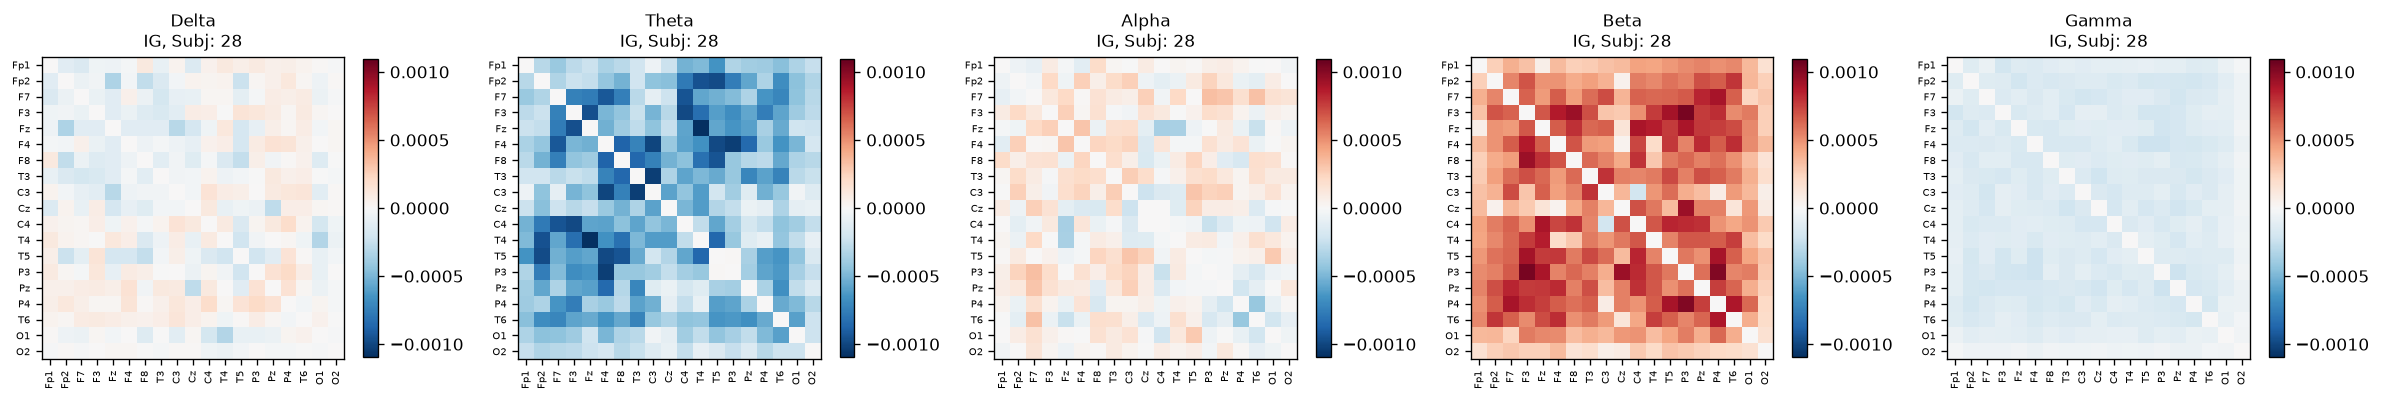


Subject: 35 | True: AD | Predicted: AD | Mean P(AD): 0.519


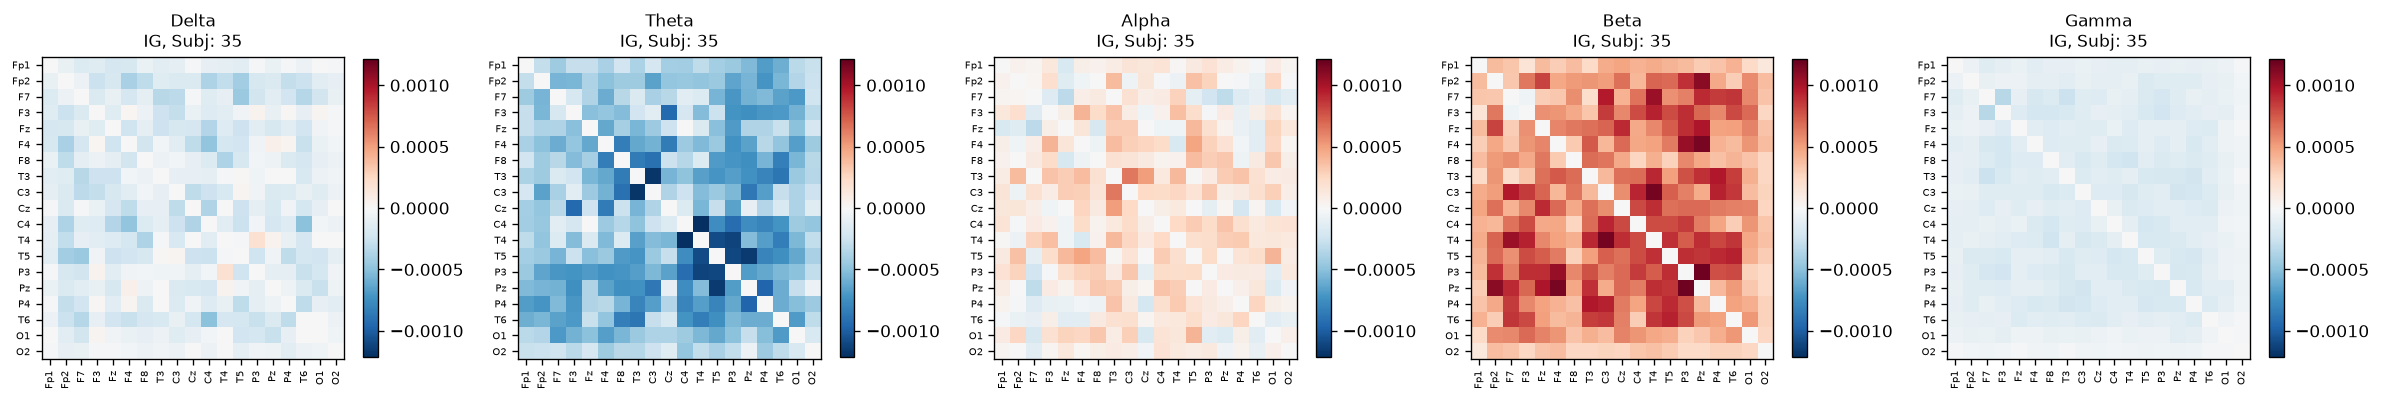

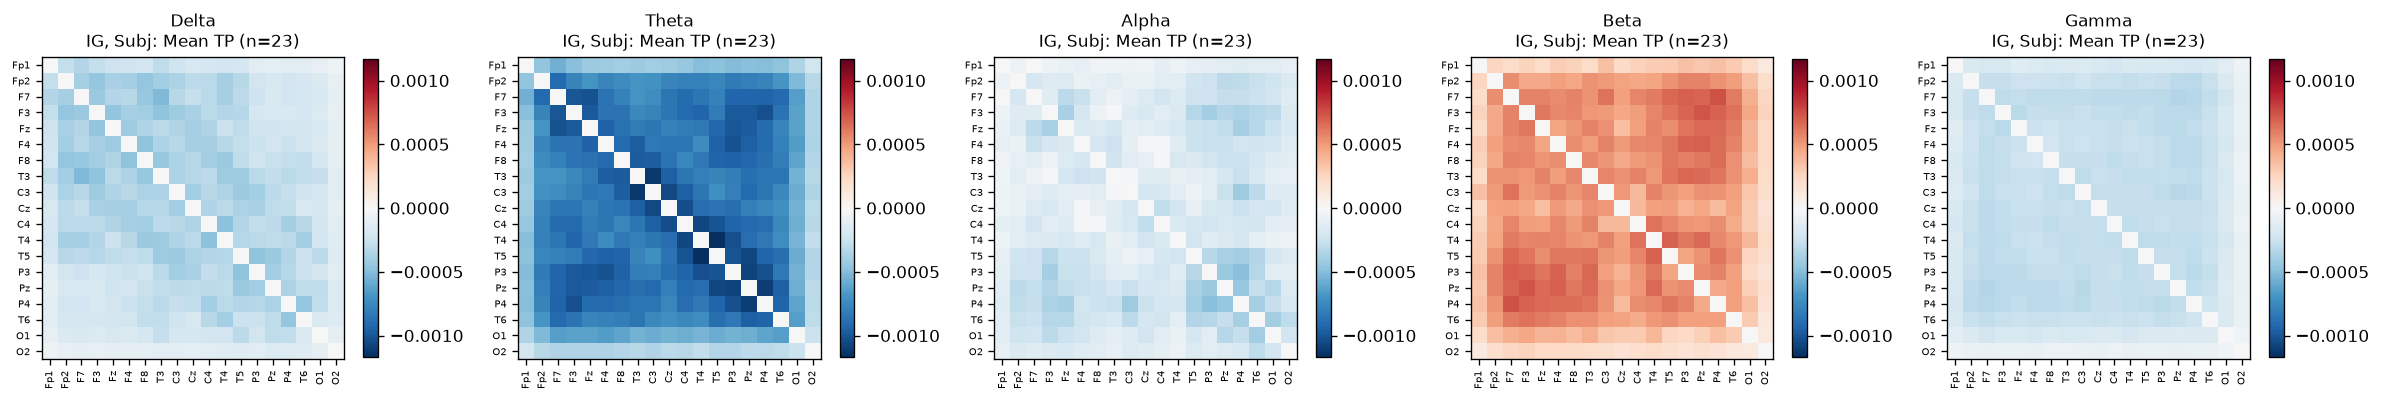

In [5]:
# 1. CORRECTLY CLASSIFIED AD : True = AD, Predicted = AD
# ============================================================

correct_ad = [
subj for subj, meta in subject_meta.items()
if meta["y_true"] == 1 and meta["y_pred"] == 1
]

print(f"Correctly classified AD subjects: {len(correct_ad)}")
print(correct_ad)

for subj in correct_ad:
    attrib_subj = all_subject_ig[subj]

    print(
        f"\nSubject: {subj} | "
        f"True: AD | "
        f"Predicted: AD | "
        f"Mean P(AD): {subject_meta[subj]['mean_prob_ad']:.3f}"
    )

    plot_subject_attribution(
        attrib_subj,
        subject_id=subj,
        method="IG",
        channel_labels=channel_names,
    )

# Mean map across all TP subjects
mean_correct_ad = np.mean(
    [all_subject_ig[subj] for subj in correct_ad],
    axis=0
)

plot_subject_attribution(
    mean_correct_ad,
    subject_id=f"Mean TP (n={len(correct_ad)})",
    method="IG",
    channel_labels=channel_names,
)

### True Negative

Correctly classified CN subjects: 22
[np.int64(45), np.int64(50), np.int64(54), np.int64(64), np.int64(40), np.int64(48), np.int64(49), np.int64(56), np.int64(62), np.int64(42), np.int64(44), np.int64(46), np.int64(58), np.int64(63), np.int64(37), np.int64(47), np.int64(51), np.int64(38), np.int64(39), np.int64(41), np.int64(53), np.int64(59)]

Subject: 45 | True: CN | Predicted: CN | Mean P(AD): 0.483


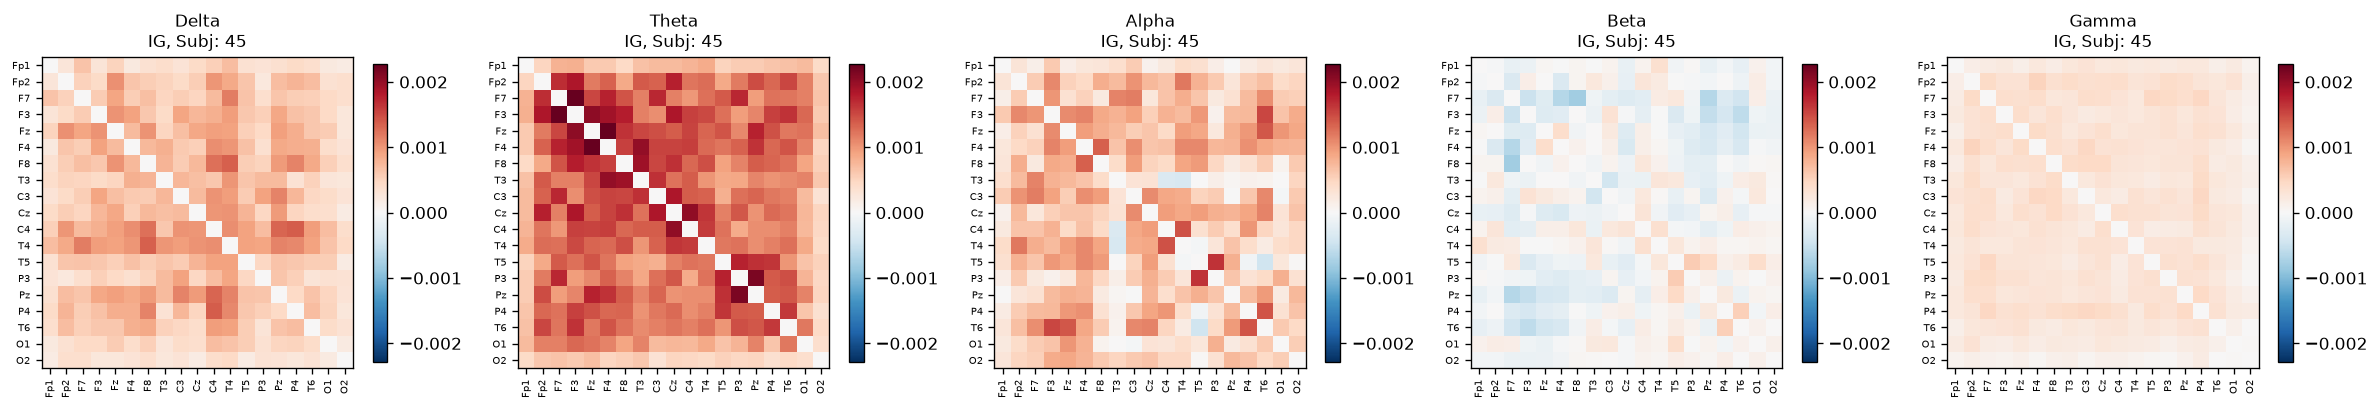


Subject: 50 | True: CN | Predicted: CN | Mean P(AD): 0.451


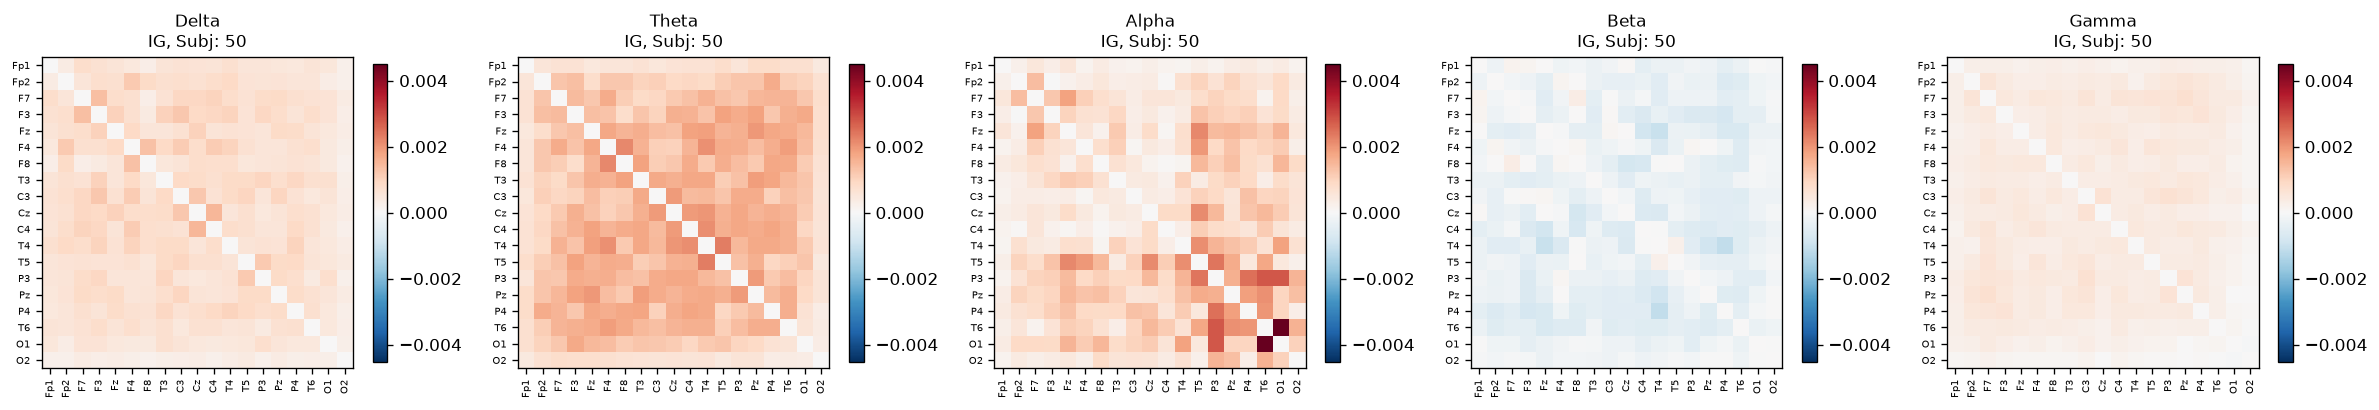


Subject: 54 | True: CN | Predicted: CN | Mean P(AD): 0.410


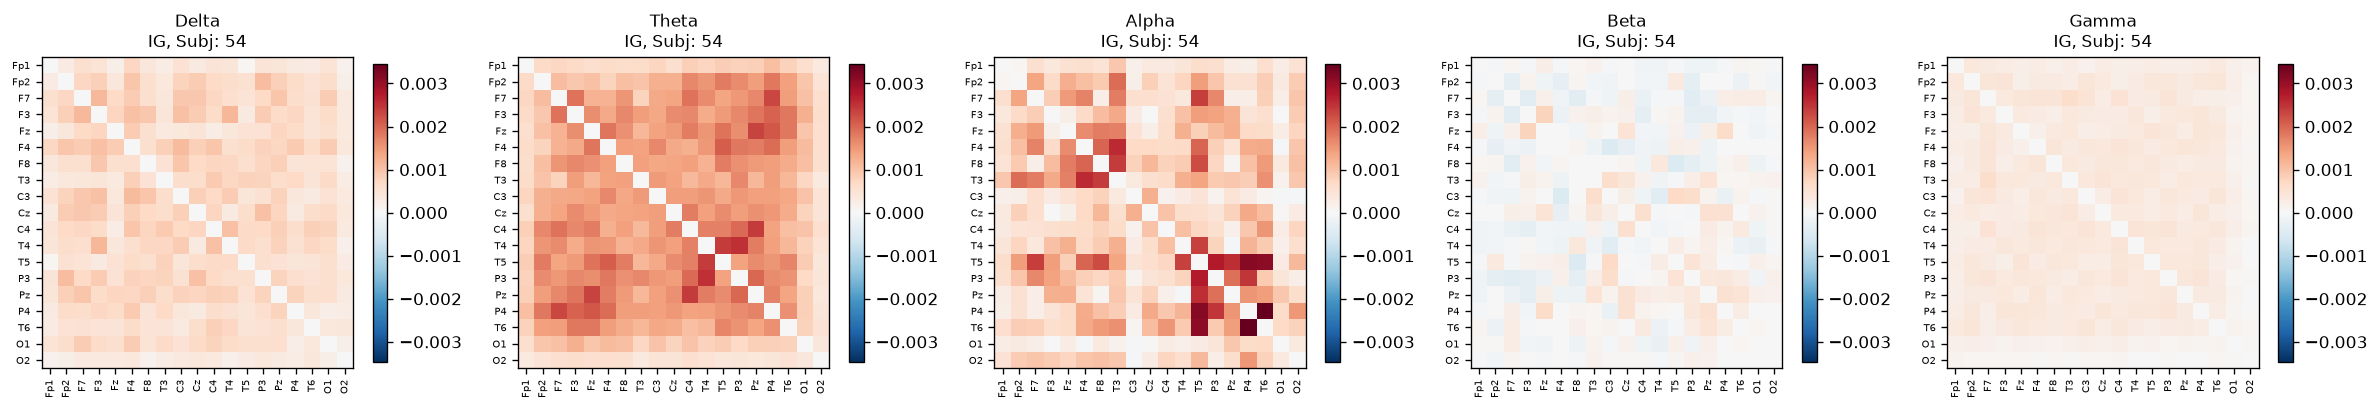


Subject: 64 | True: CN | Predicted: CN | Mean P(AD): 0.380


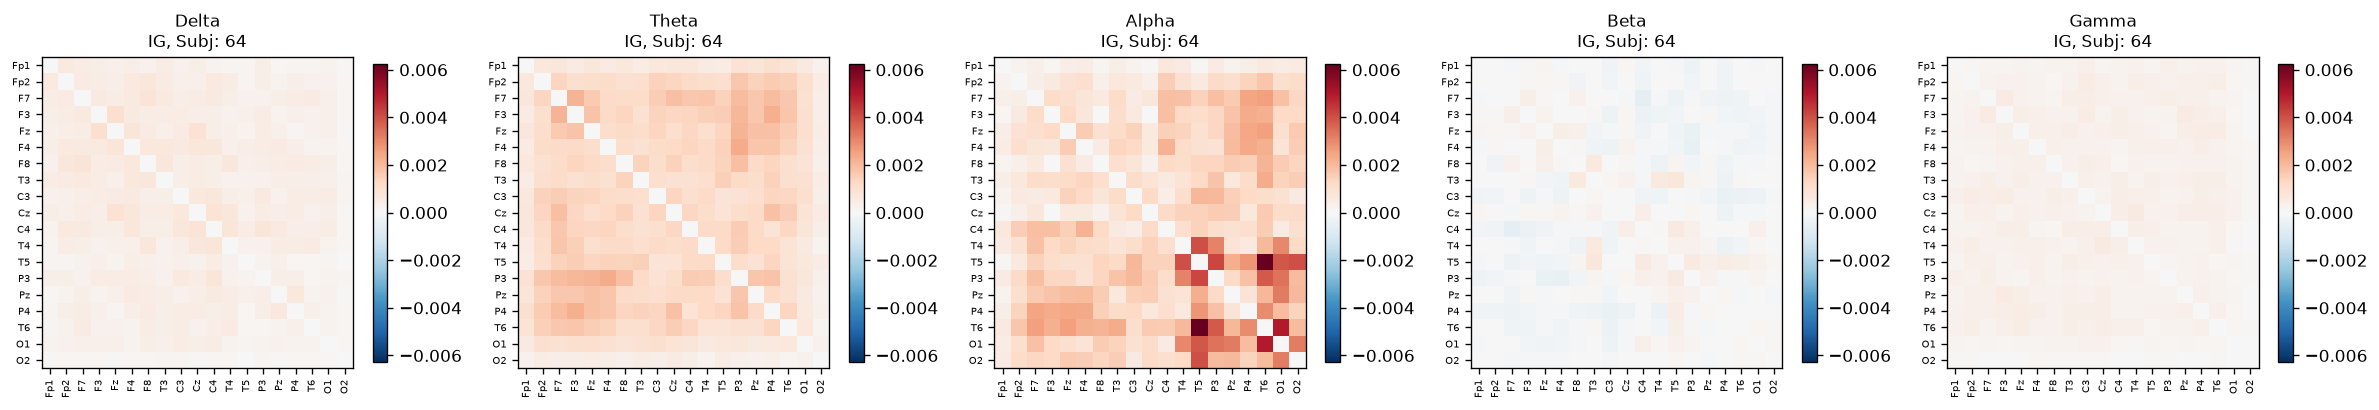


Subject: 40 | True: CN | Predicted: CN | Mean P(AD): 0.468


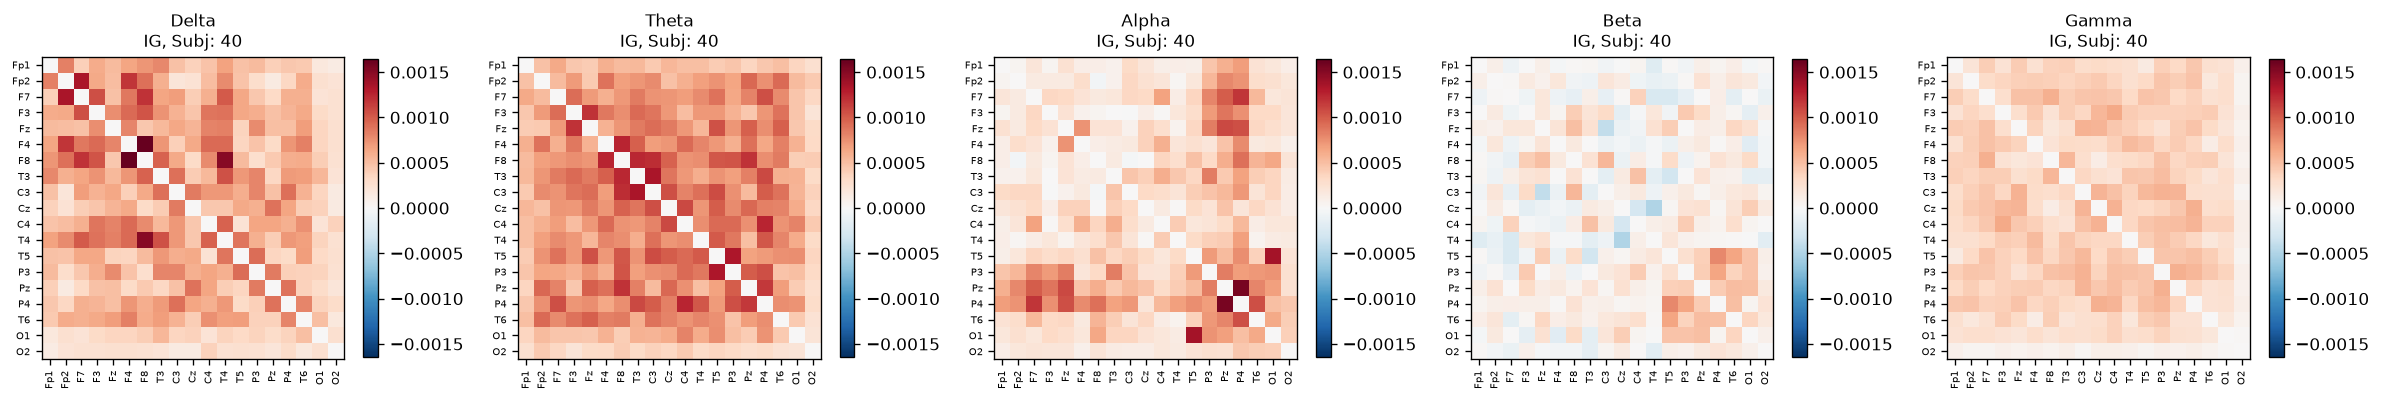


Subject: 48 | True: CN | Predicted: CN | Mean P(AD): 0.497


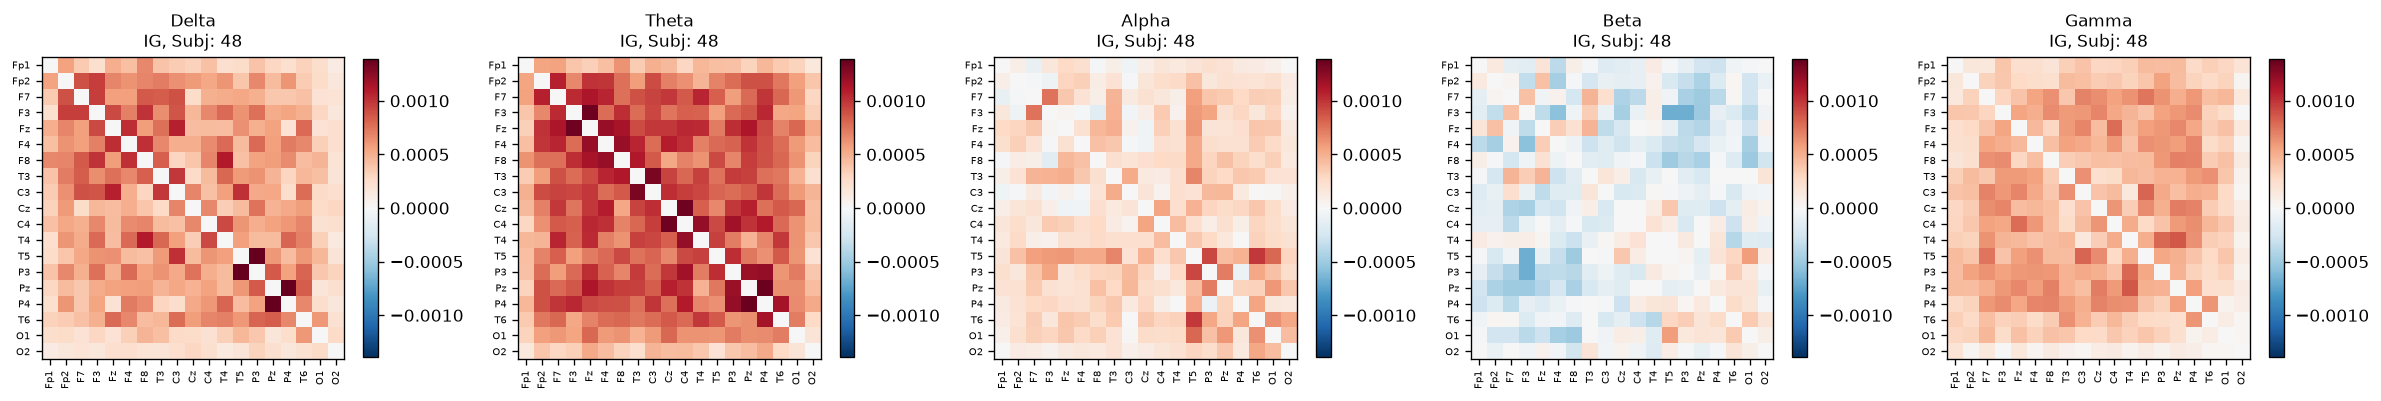


Subject: 49 | True: CN | Predicted: CN | Mean P(AD): 0.491


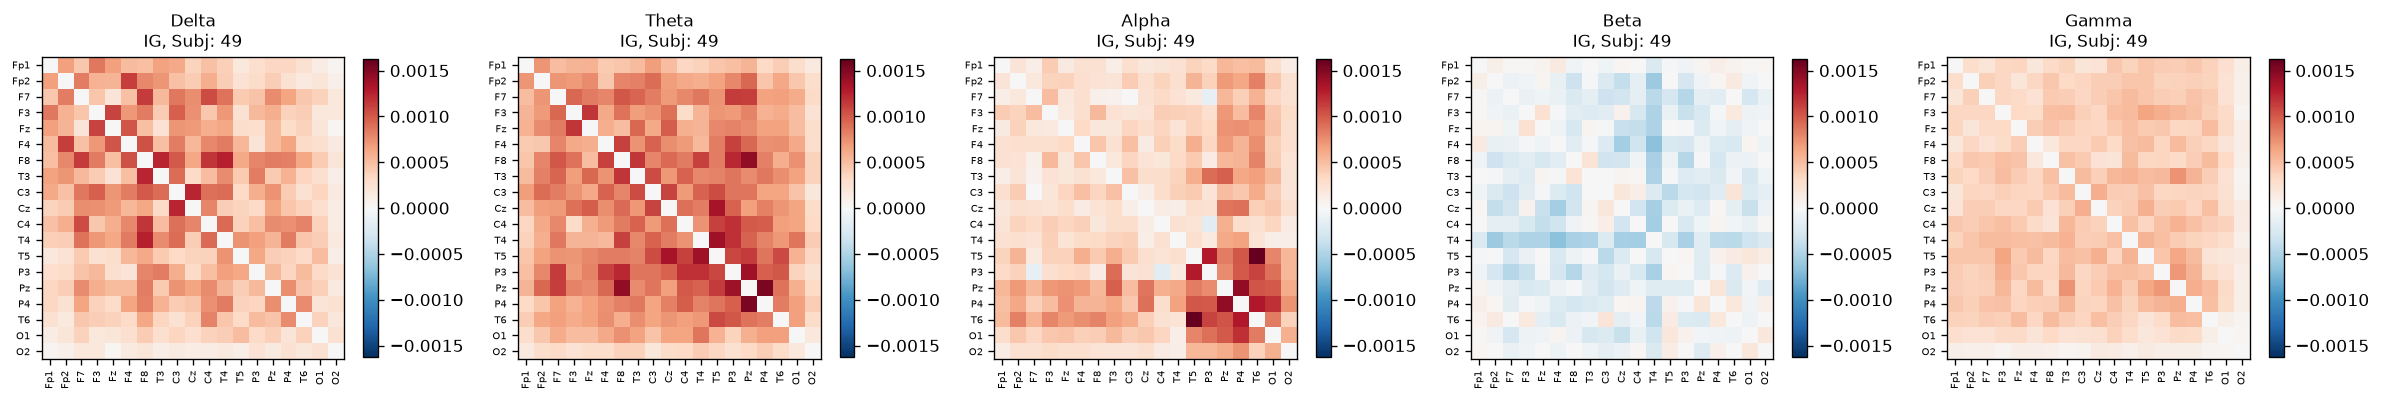


Subject: 56 | True: CN | Predicted: CN | Mean P(AD): 0.463


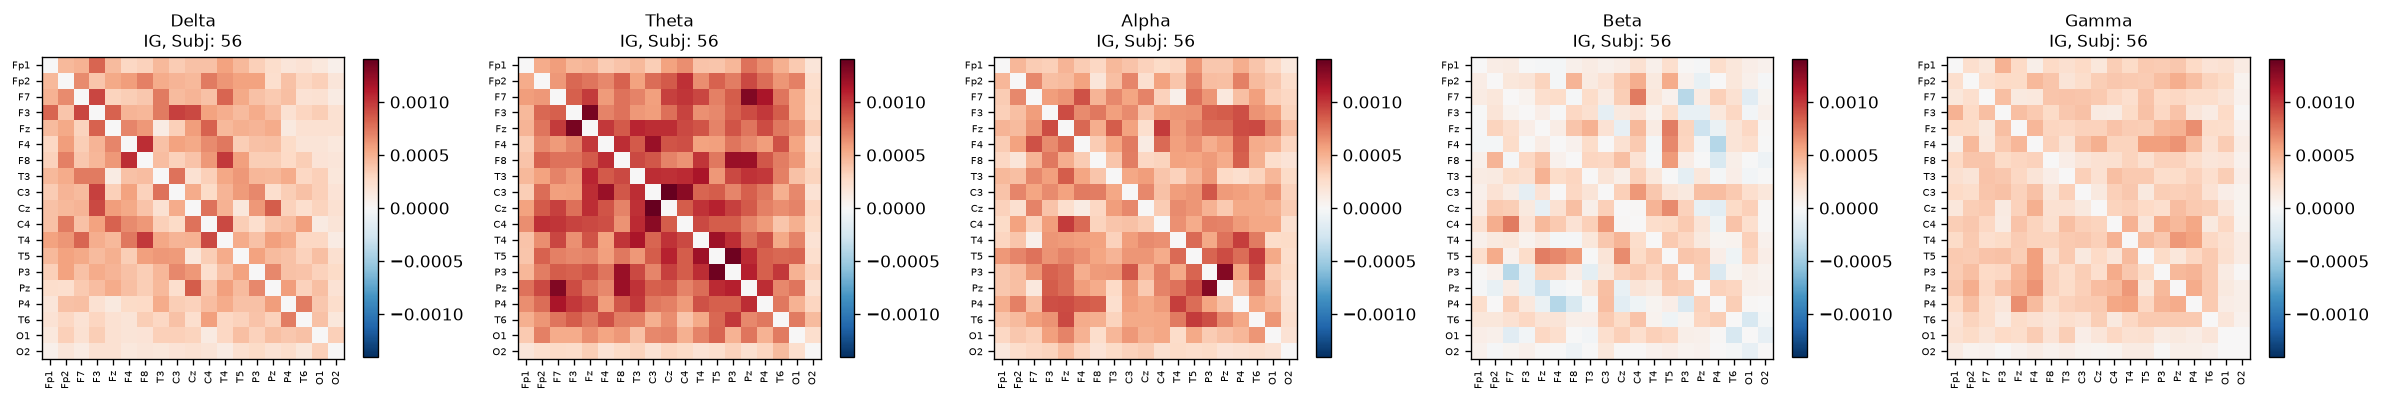


Subject: 62 | True: CN | Predicted: CN | Mean P(AD): 0.445


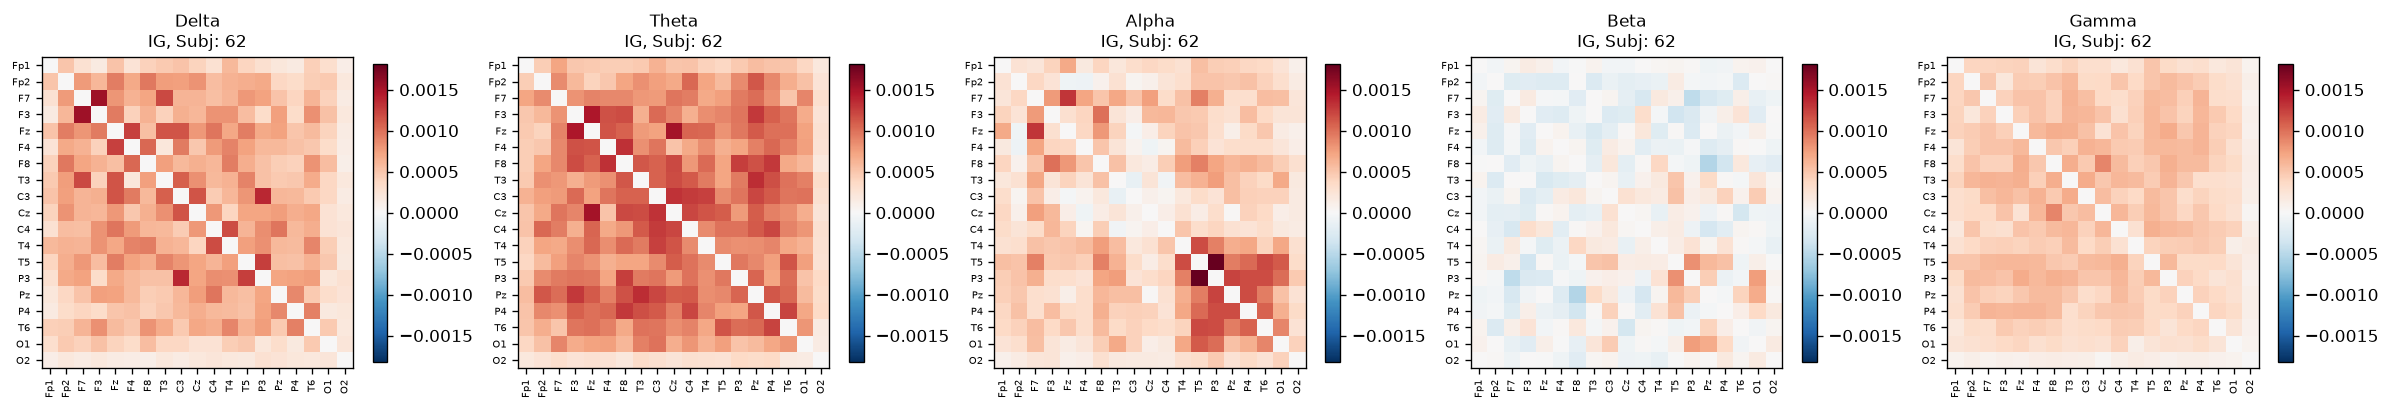


Subject: 42 | True: CN | Predicted: CN | Mean P(AD): 0.460


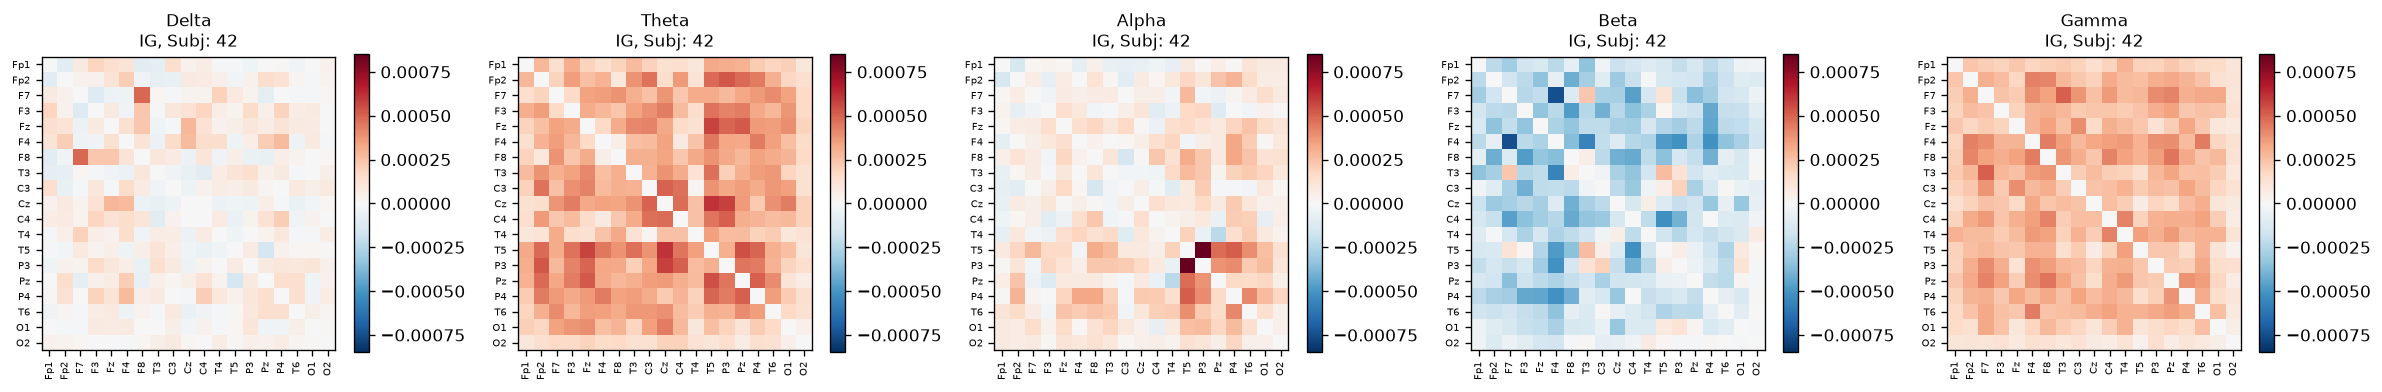


Subject: 44 | True: CN | Predicted: CN | Mean P(AD): 0.453


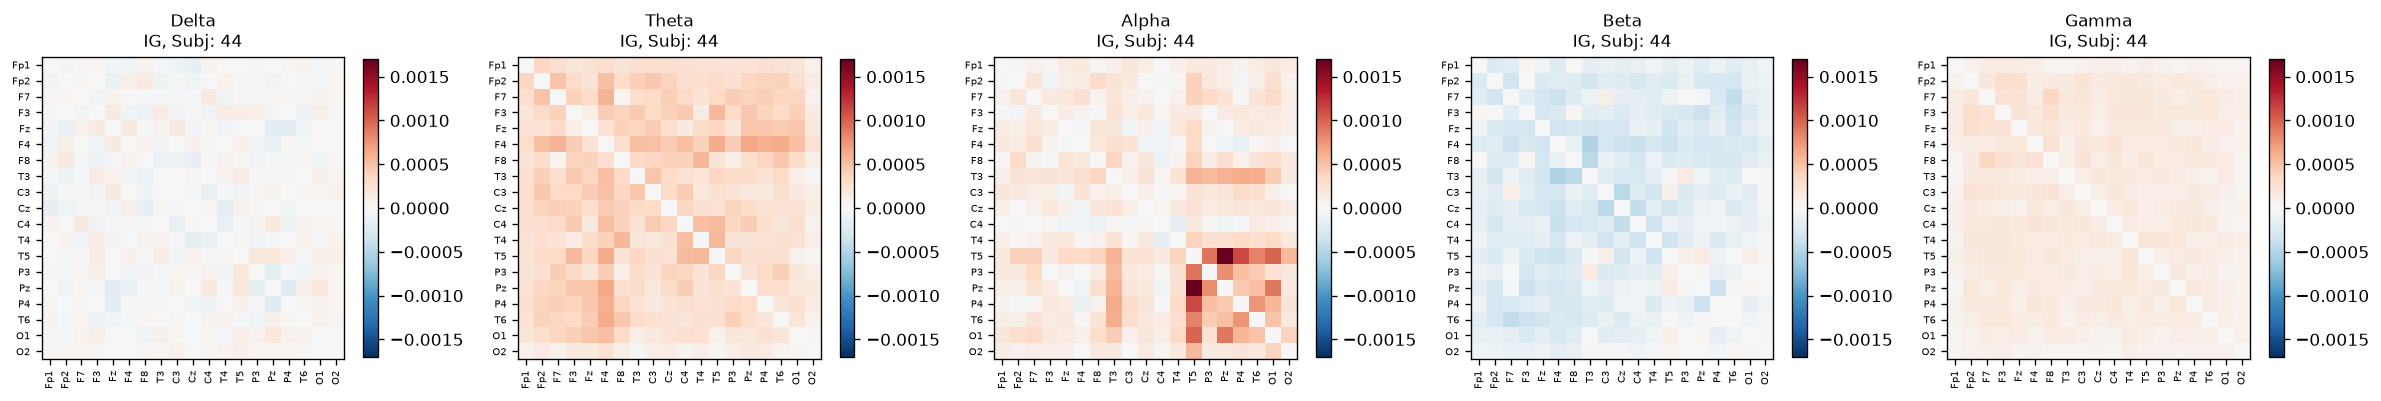


Subject: 46 | True: CN | Predicted: CN | Mean P(AD): 0.458


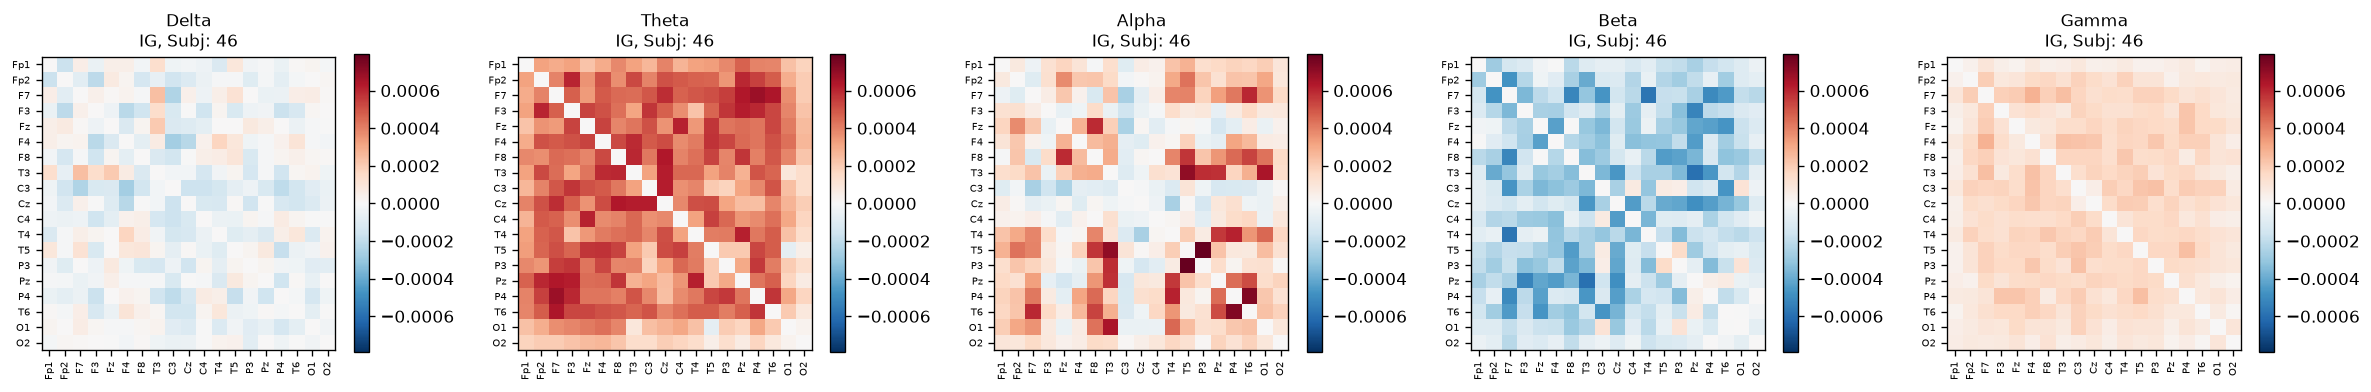


Subject: 58 | True: CN | Predicted: CN | Mean P(AD): 0.442


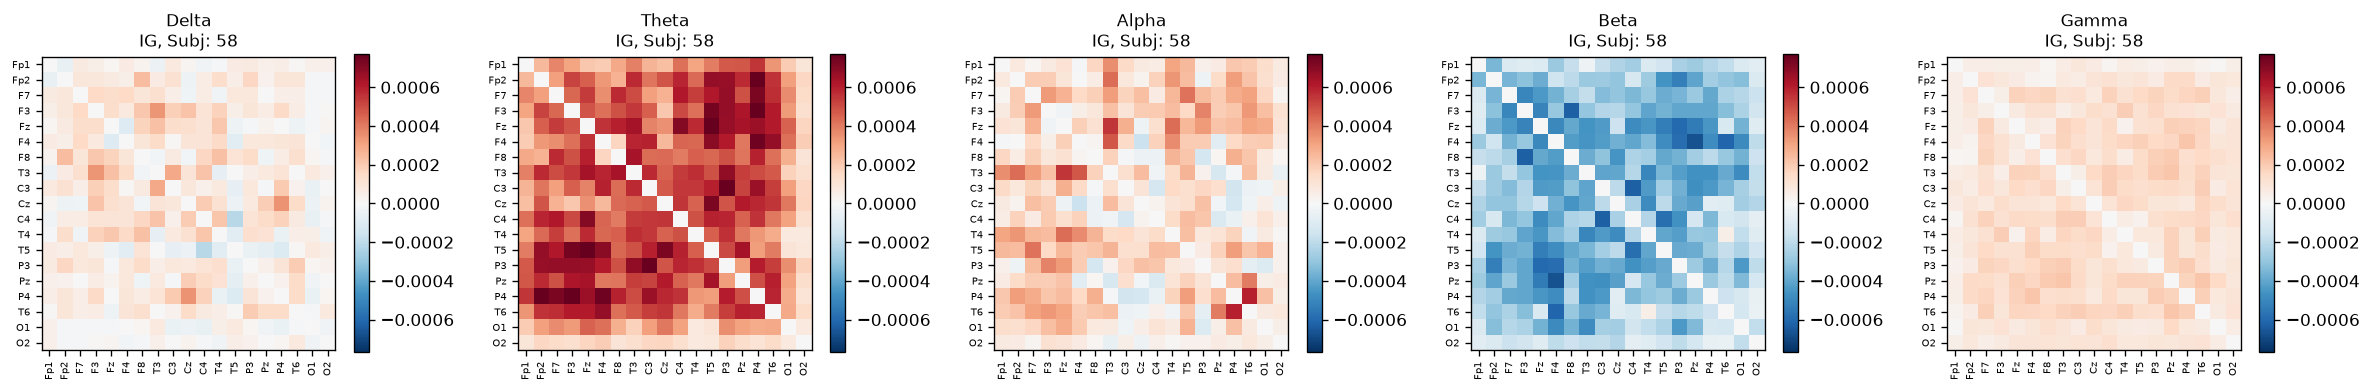


Subject: 63 | True: CN | Predicted: CN | Mean P(AD): 0.481


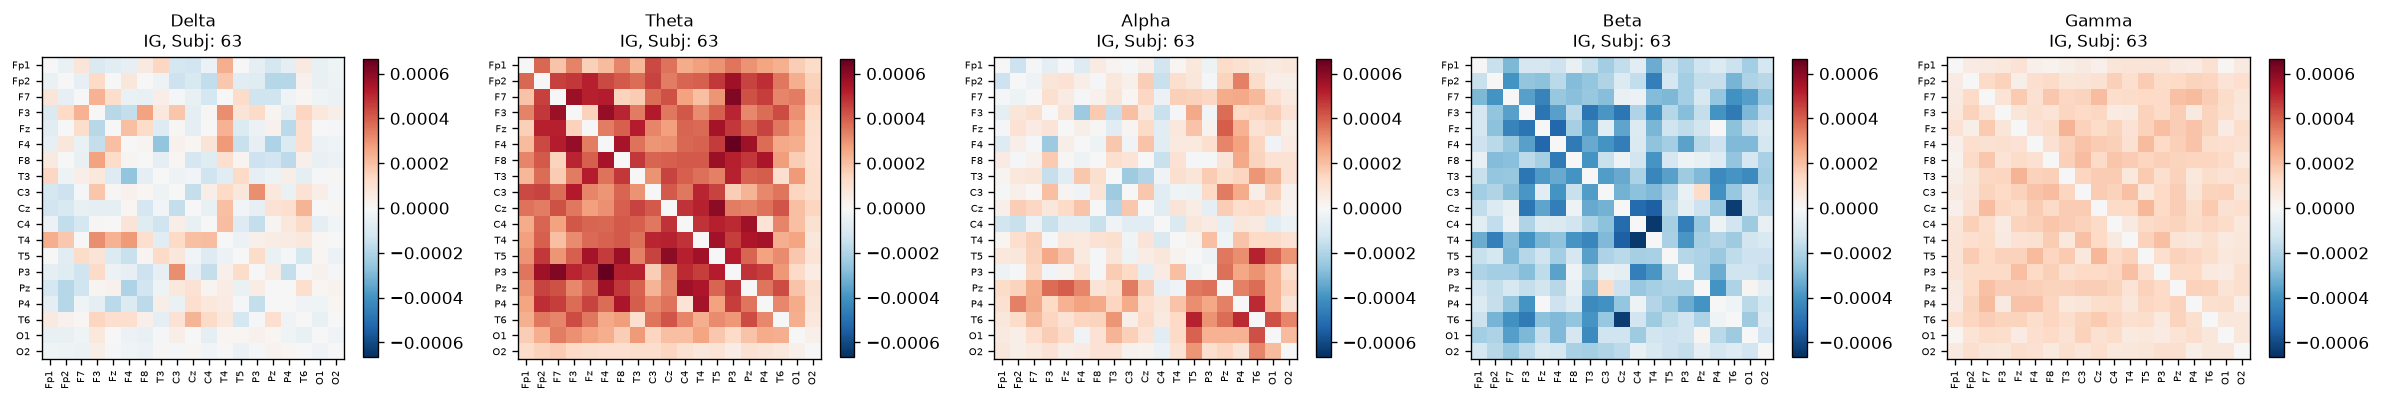


Subject: 37 | True: CN | Predicted: CN | Mean P(AD): 0.420


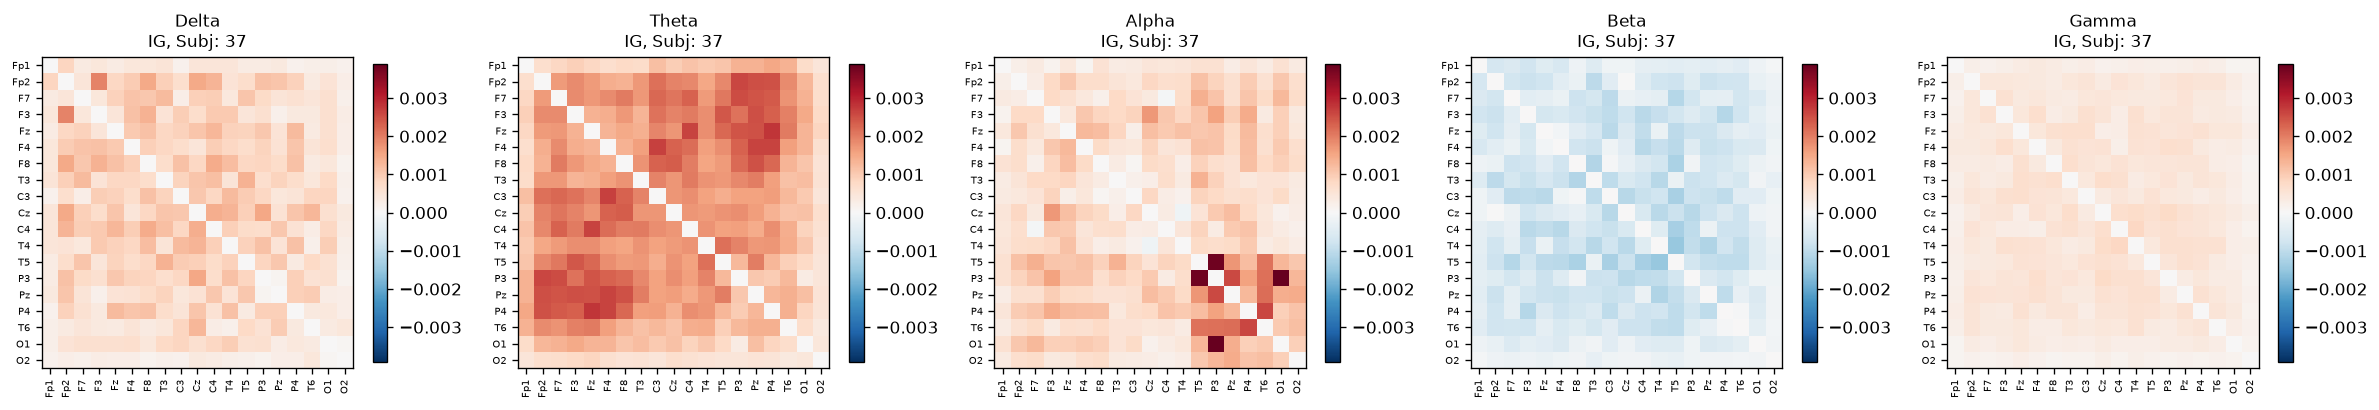


Subject: 47 | True: CN | Predicted: CN | Mean P(AD): 0.466


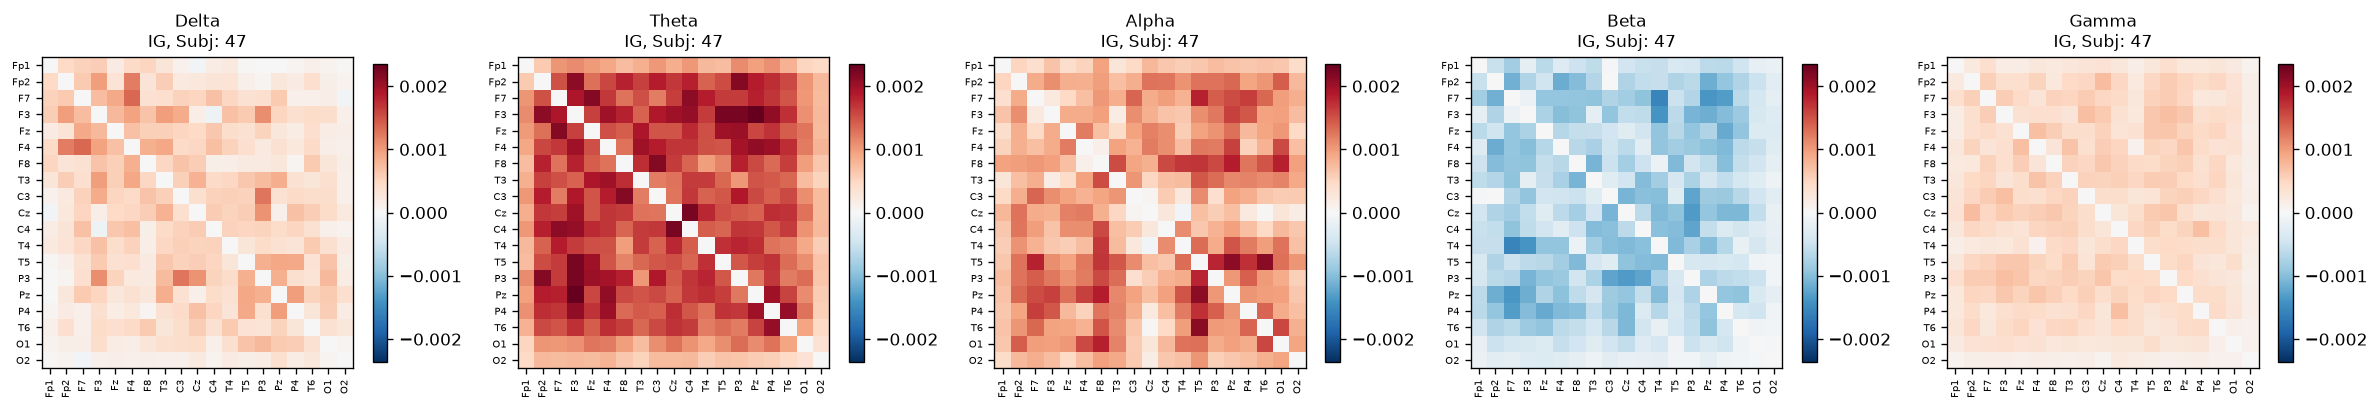


Subject: 51 | True: CN | Predicted: CN | Mean P(AD): 0.488


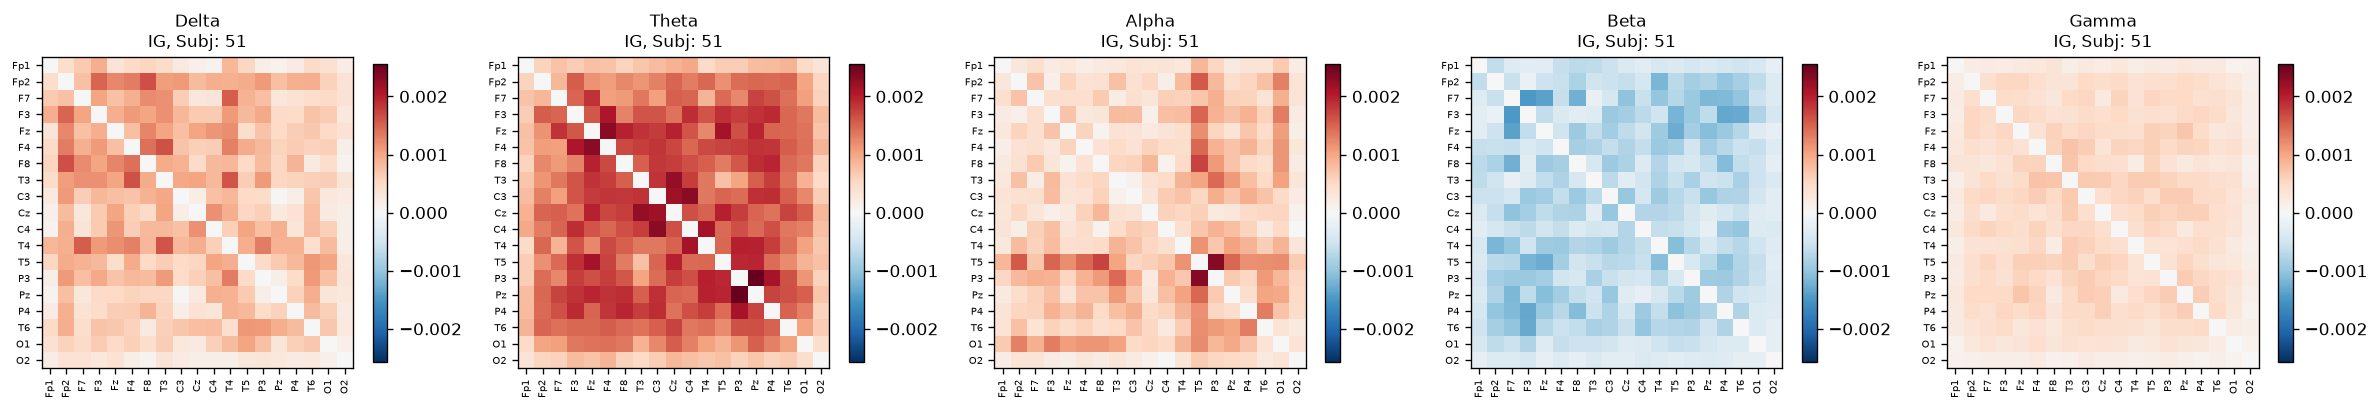


Subject: 38 | True: CN | Predicted: CN | Mean P(AD): 0.471


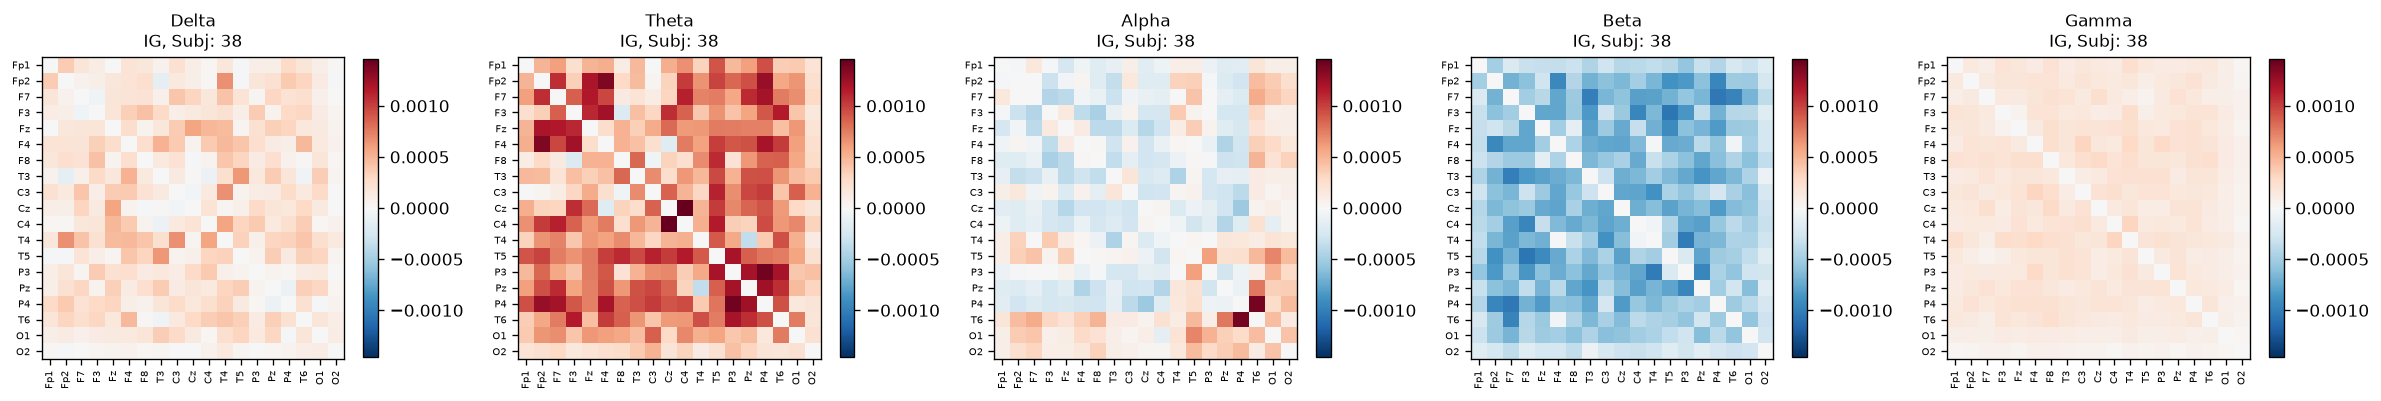


Subject: 39 | True: CN | Predicted: CN | Mean P(AD): 0.408


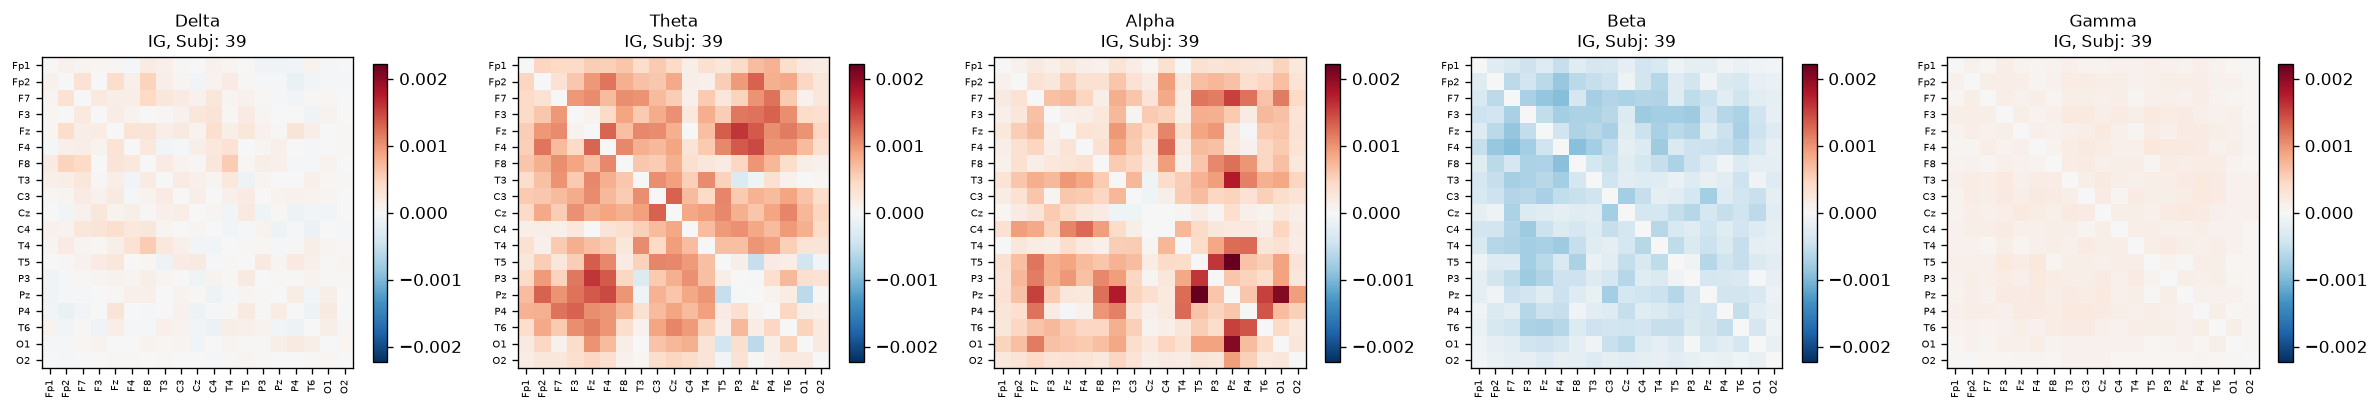


Subject: 41 | True: CN | Predicted: CN | Mean P(AD): 0.495


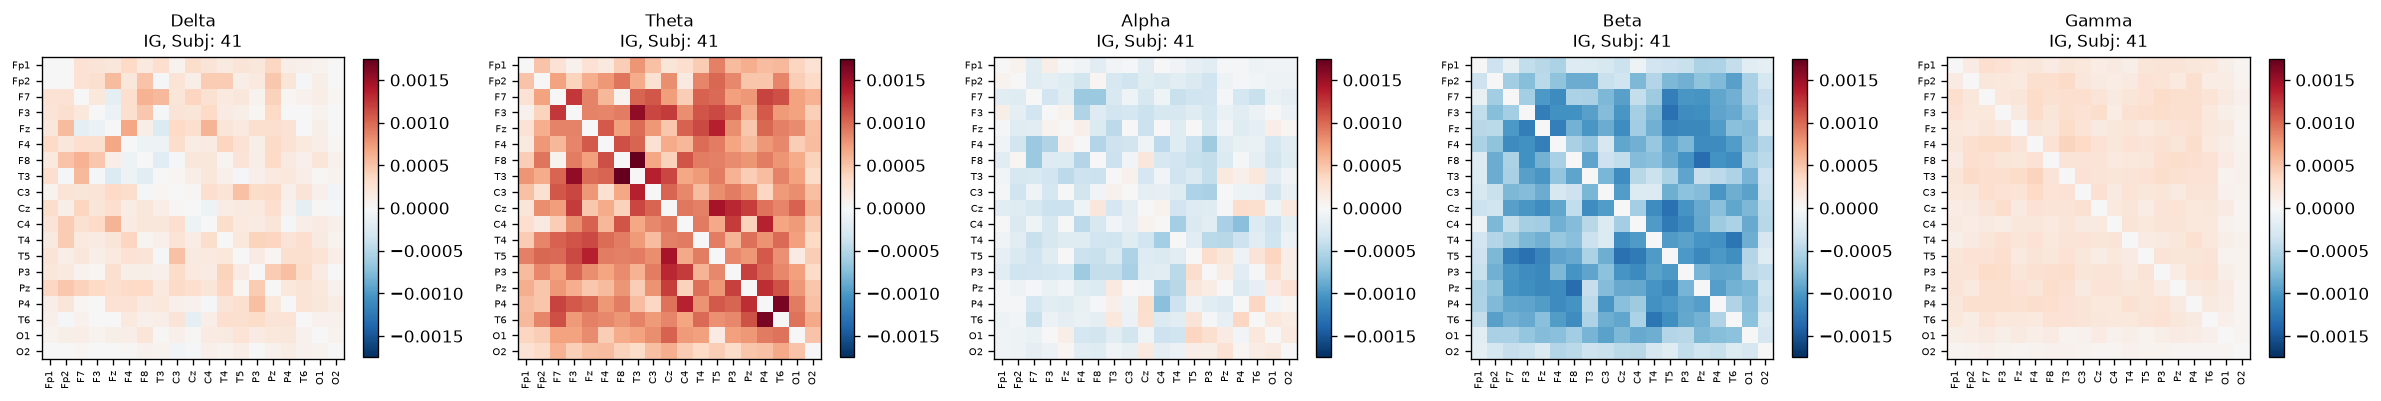


Subject: 53 | True: CN | Predicted: CN | Mean P(AD): 0.448


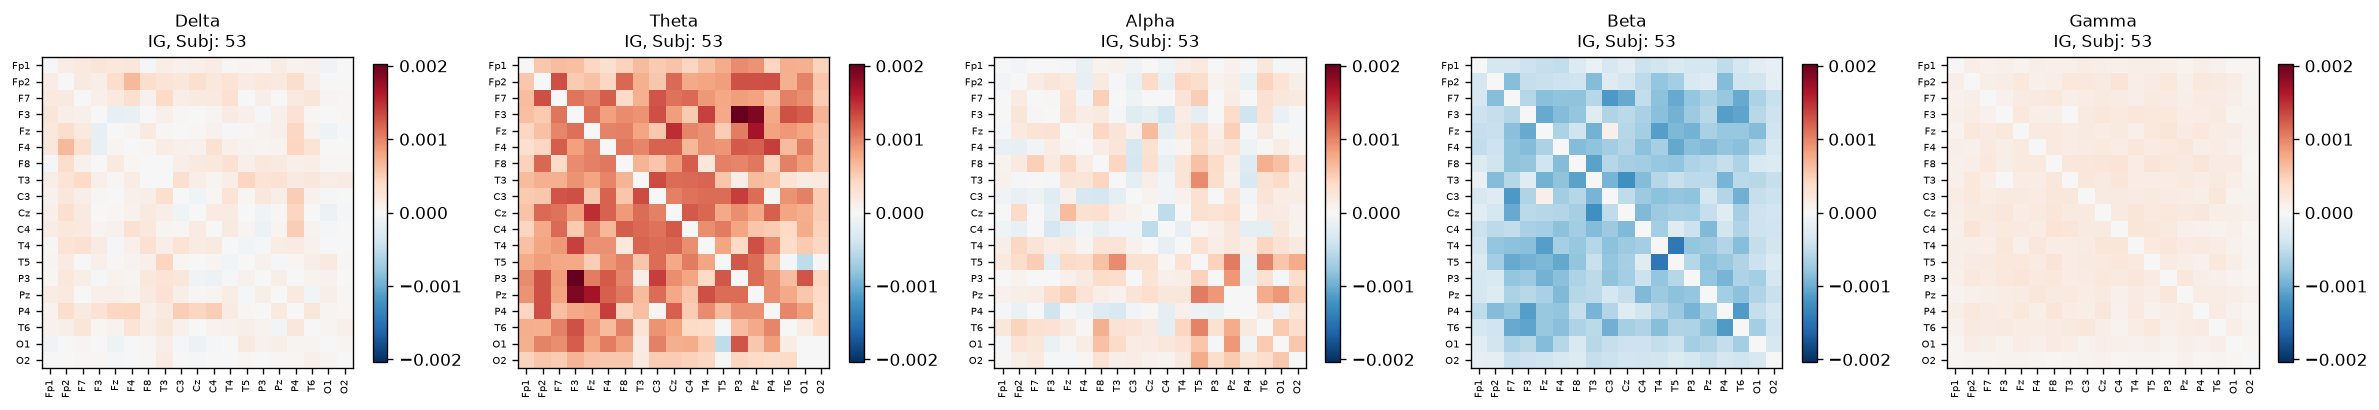


Subject: 59 | True: CN | Predicted: CN | Mean P(AD): 0.486


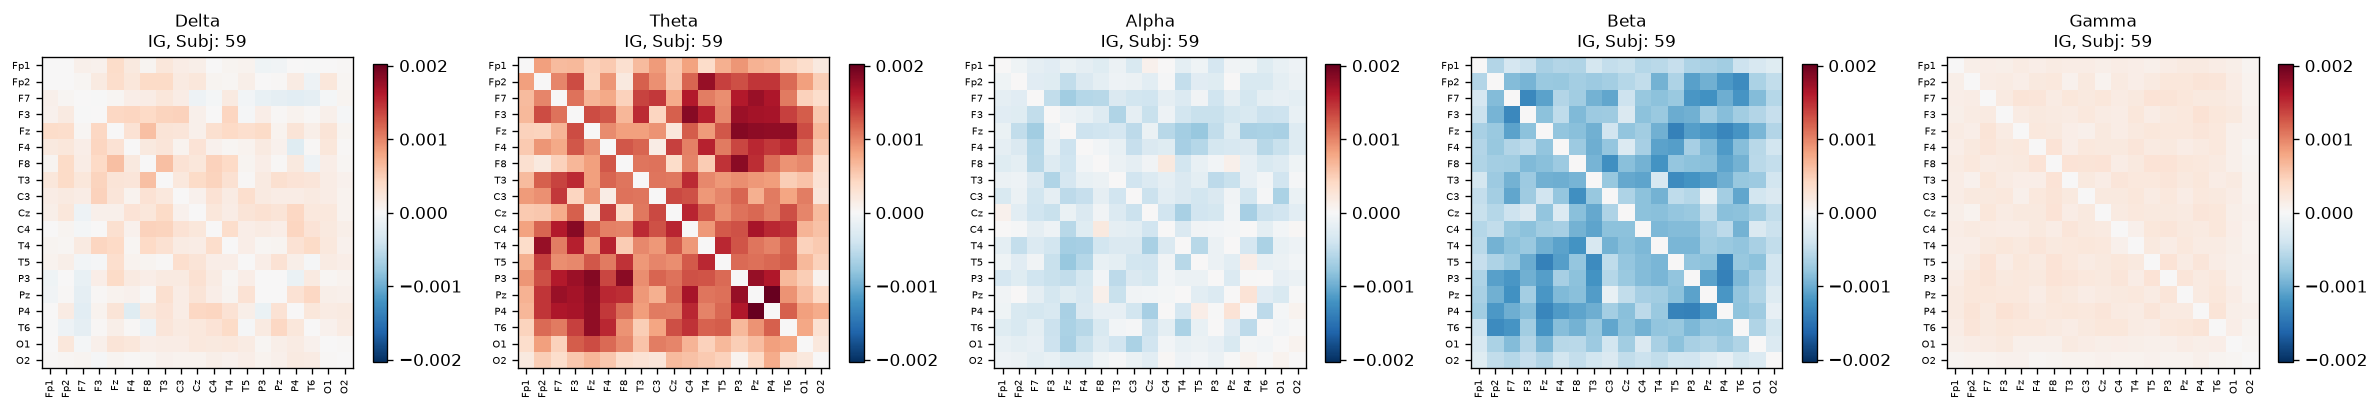

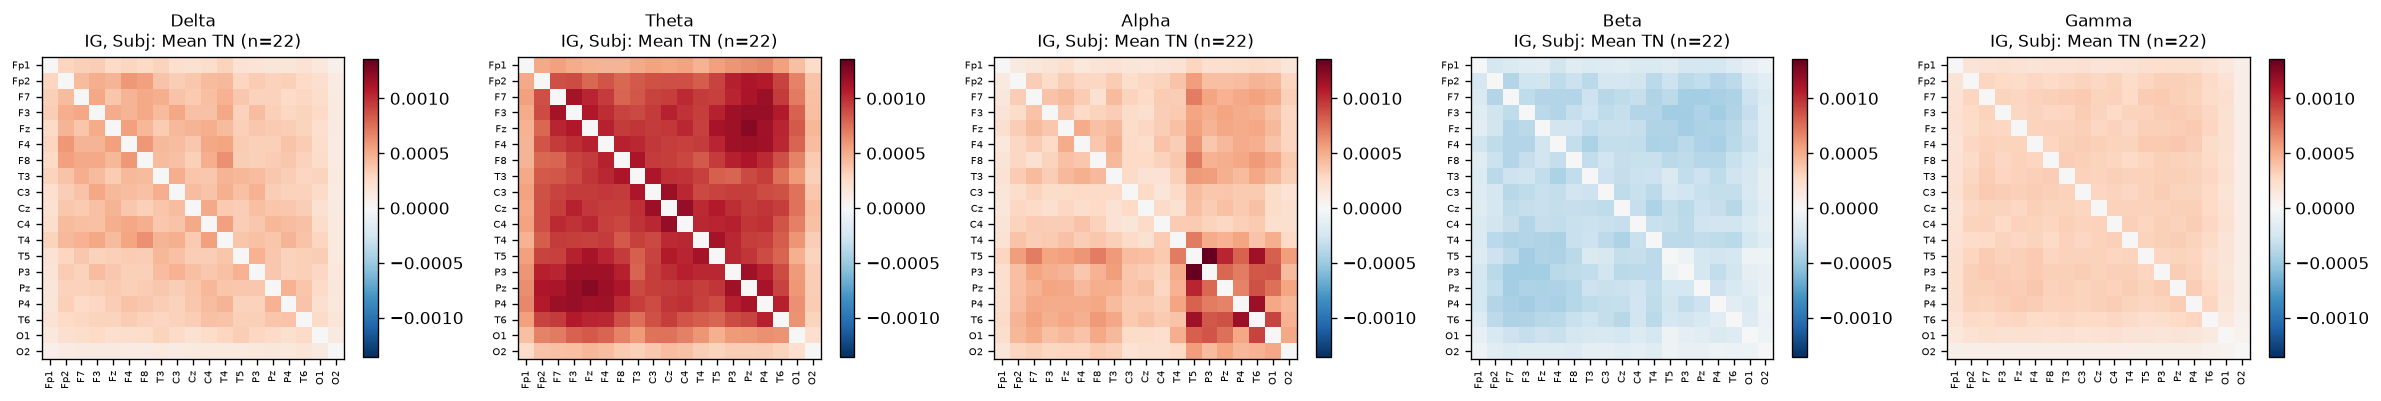

In [6]:
# 2. CORRECTLY CLASSIFIED CN : True = CN, Predicted = CN
# ============================================================

correct_cn = [
subj for subj, meta in subject_meta.items()
if meta["y_true"] == 0 and meta["y_pred"] == 0
]

print(f"Correctly classified CN subjects: {len(correct_cn)}")
print(correct_cn)

for subj in correct_cn:
    attrib_subj = all_subject_ig[subj]


    print(
        f"\nSubject: {subj} | "
        f"True: CN | "
        f"Predicted: CN | "
        f"Mean P(AD): {subject_meta[subj]['mean_prob_ad']:.3f}"
    )

    plot_subject_attribution(
        attrib_subj,
        subject_id=subj,
        method="IG",
        channel_labels=channel_names,
    )

# Mean map across all TN subjects
mean_correct_cn = np.mean(
    [all_subject_ig[subj] for subj in correct_cn],
    axis=0
)

plot_subject_attribution(
    mean_correct_cn,
    subject_id=f"Mean TN (n={len(correct_cn)})",
    method="IG",
    channel_labels=channel_names,
)


### False Negative

Wrongly classified AD subjects: 13
[np.int64(23), np.int64(25), np.int64(36), np.int64(9), np.int64(10), np.int64(32), np.int64(2), np.int64(31), np.int64(3), np.int64(6), np.int64(11), np.int64(15), np.int64(33)]

Subject: 23 | True: AD | Predicted: CN | Mean P(AD): 0.492


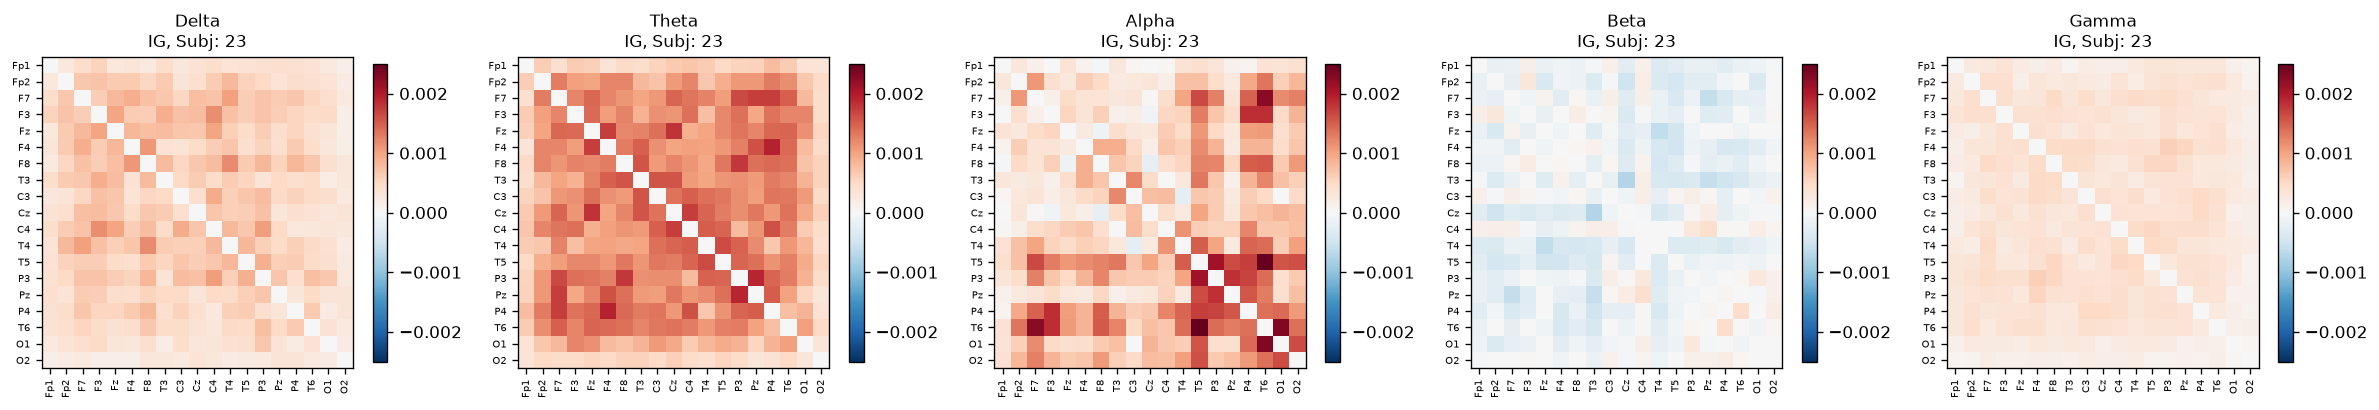


Subject: 25 | True: AD | Predicted: CN | Mean P(AD): 0.409


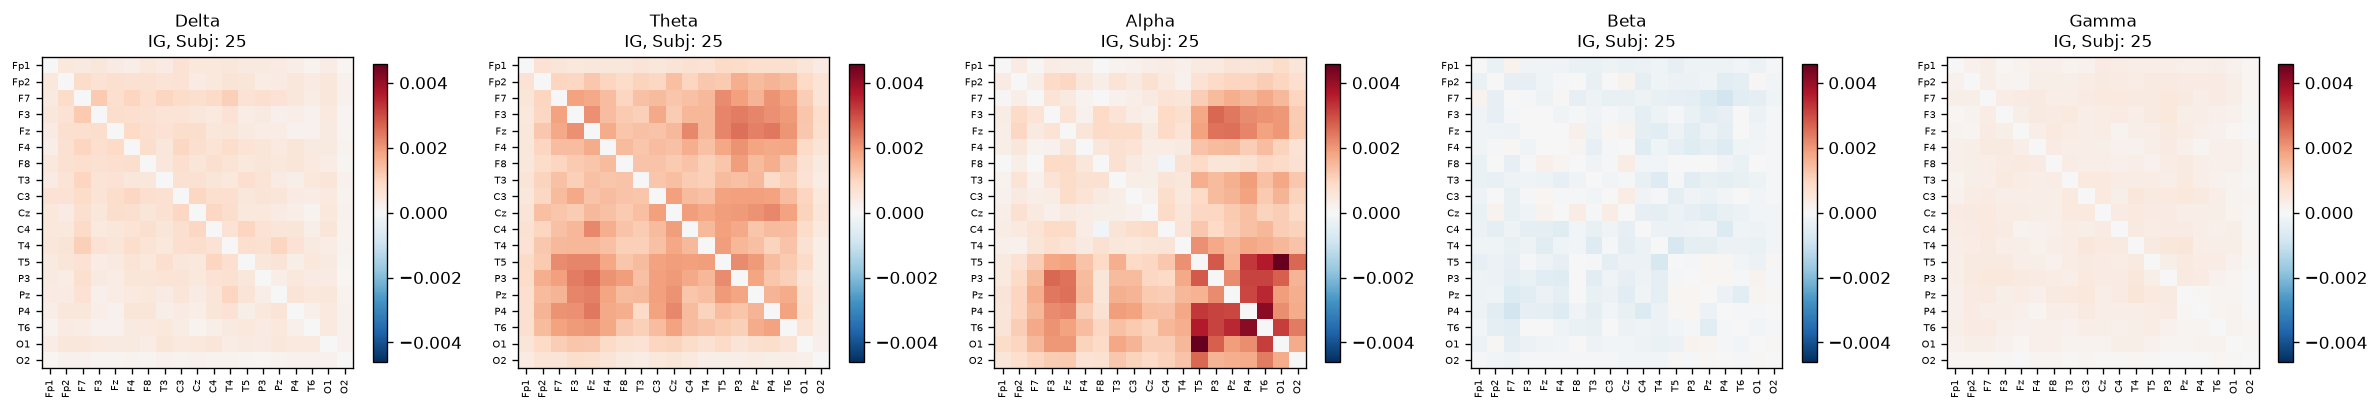


Subject: 36 | True: AD | Predicted: CN | Mean P(AD): 0.444


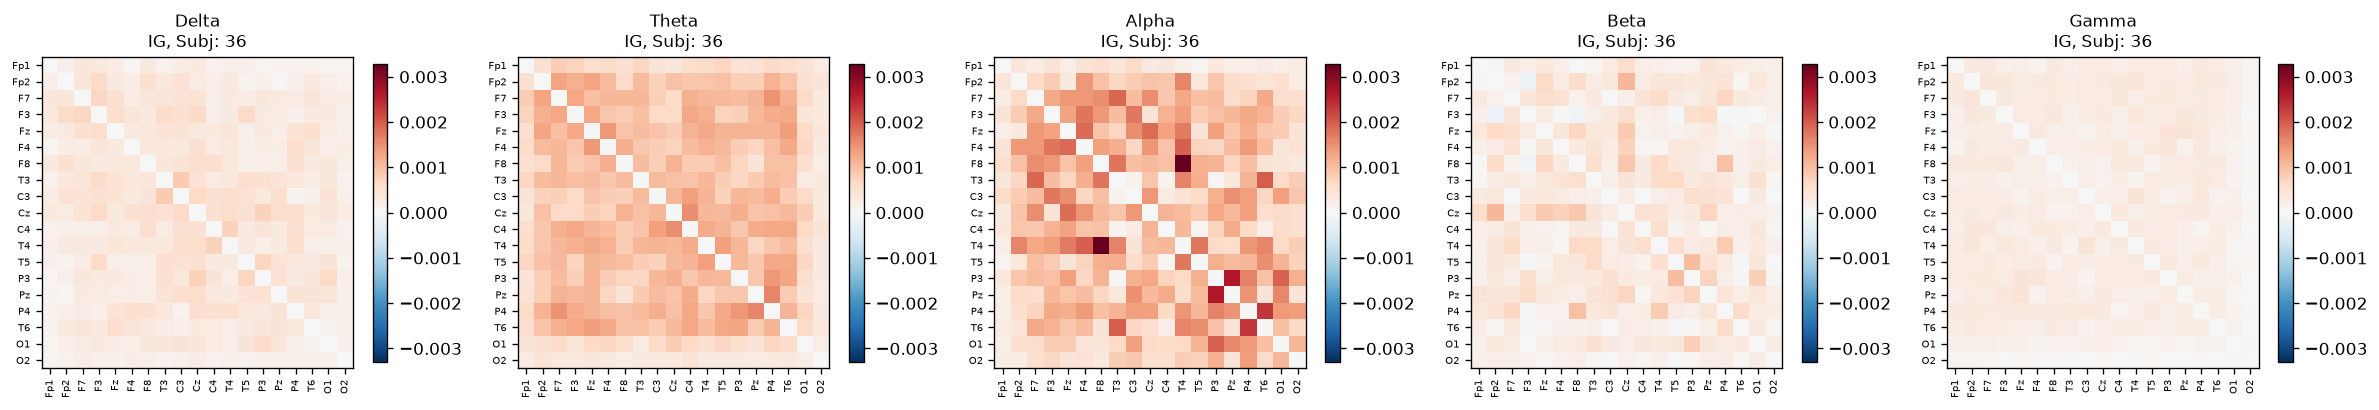


Subject: 9 | True: AD | Predicted: CN | Mean P(AD): 0.491


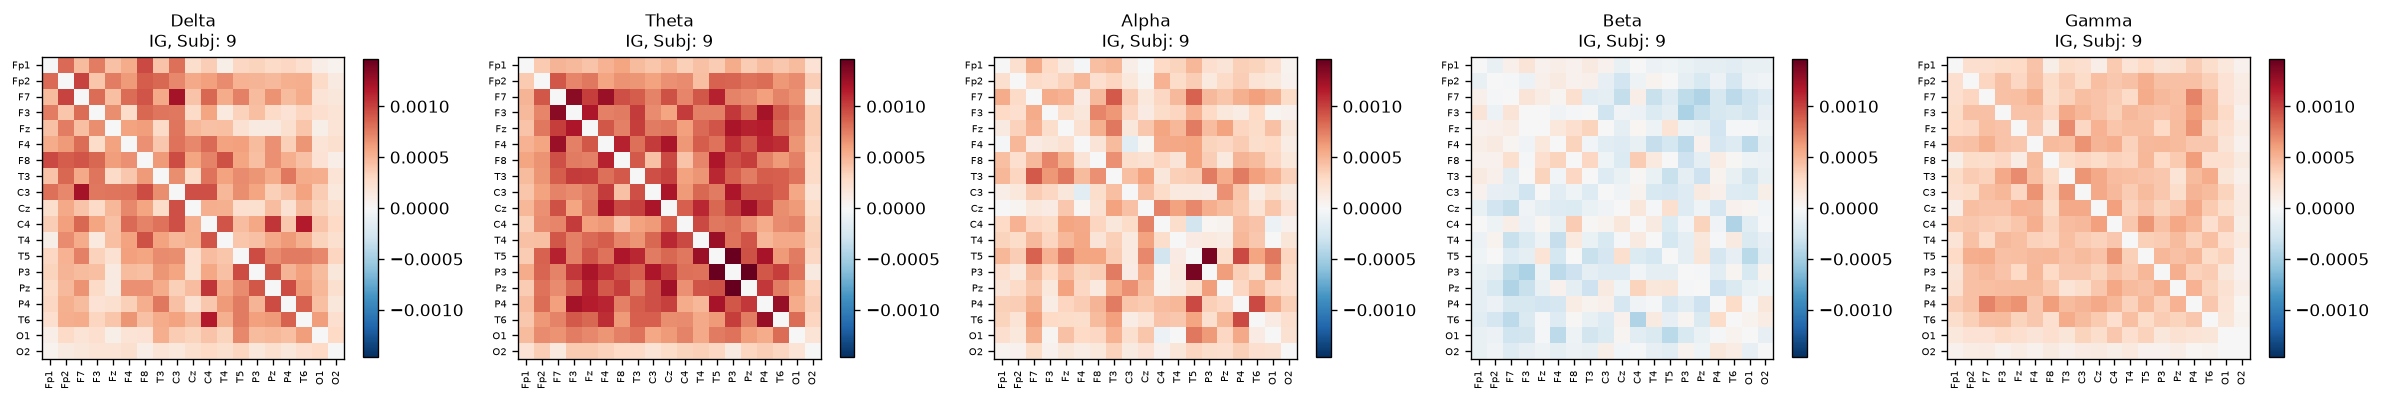


Subject: 10 | True: AD | Predicted: CN | Mean P(AD): 0.483


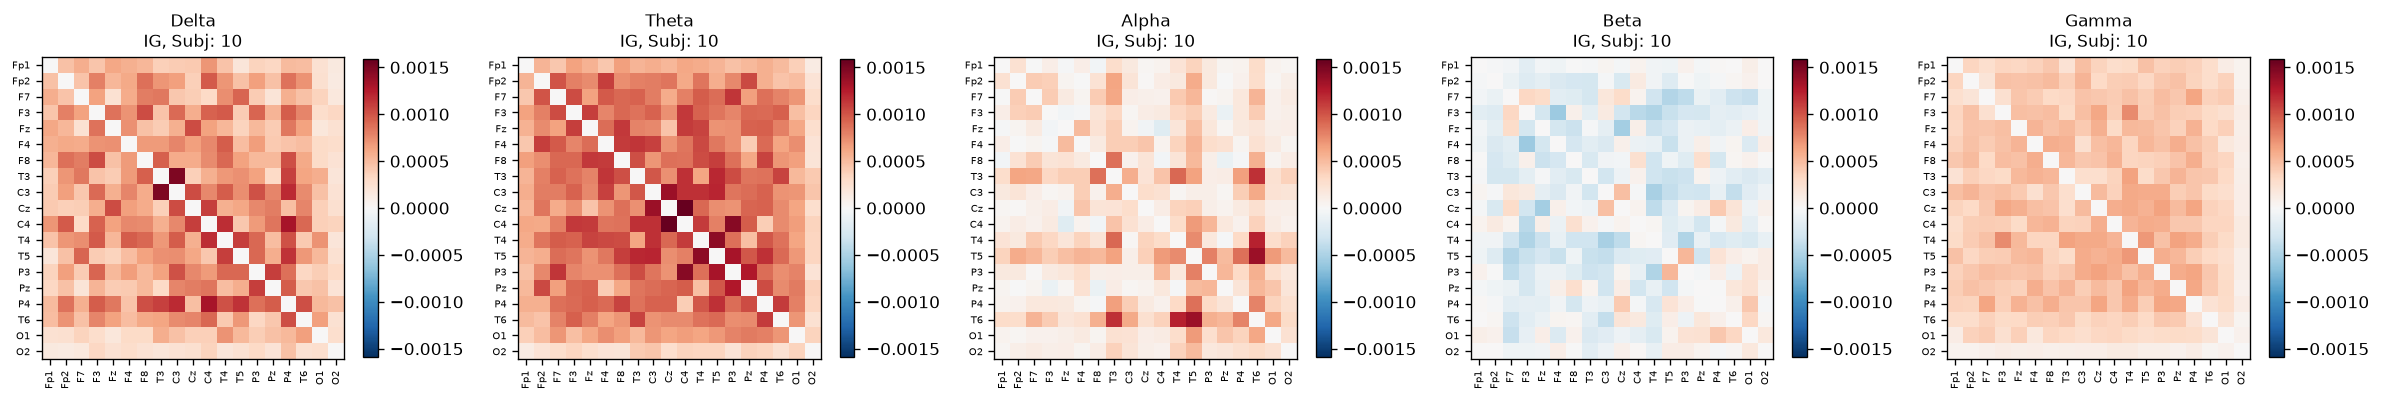


Subject: 32 | True: AD | Predicted: CN | Mean P(AD): 0.498


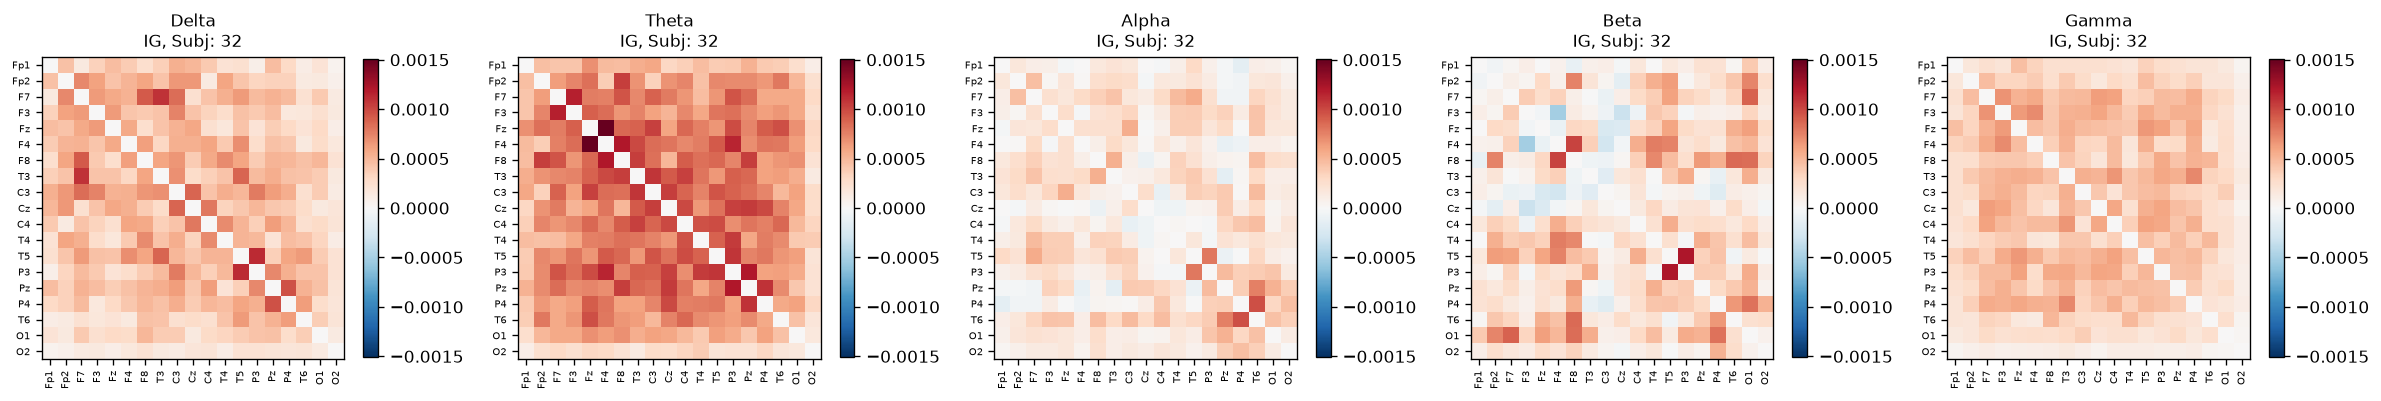


Subject: 2 | True: AD | Predicted: CN | Mean P(AD): 0.464


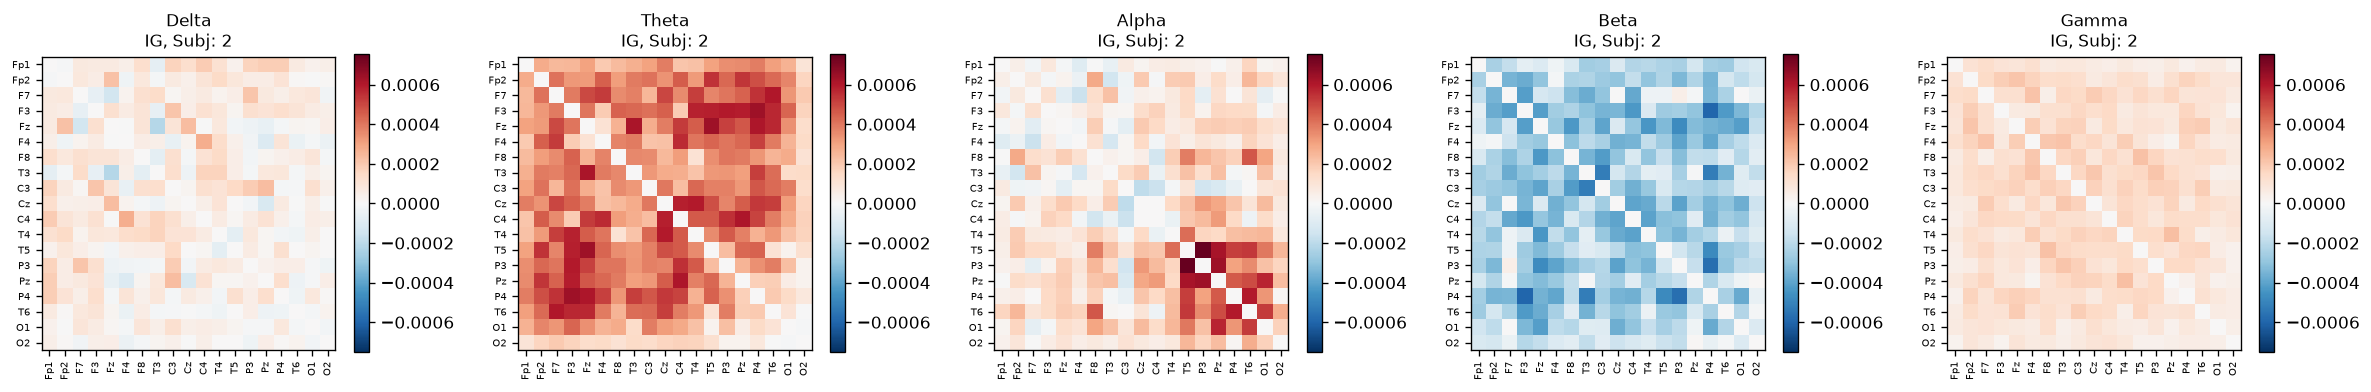


Subject: 31 | True: AD | Predicted: CN | Mean P(AD): 0.467


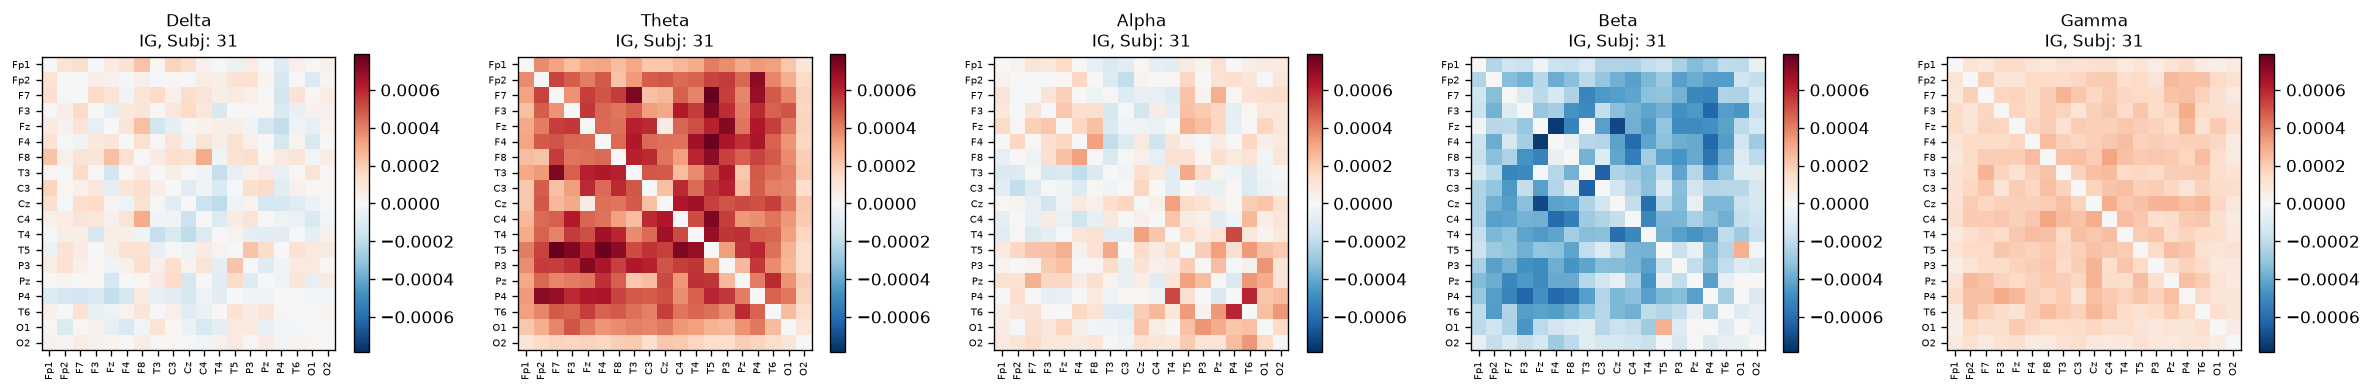


Subject: 3 | True: AD | Predicted: CN | Mean P(AD): 0.488


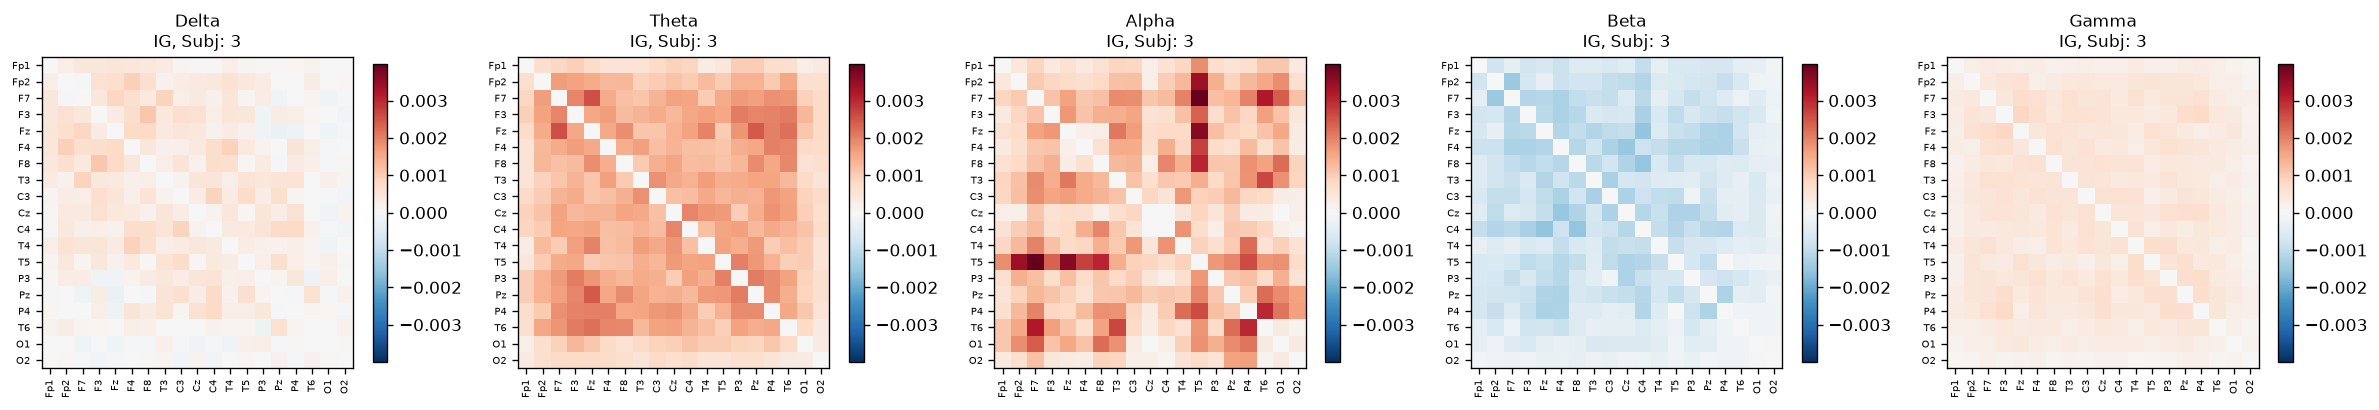


Subject: 6 | True: AD | Predicted: CN | Mean P(AD): 0.440


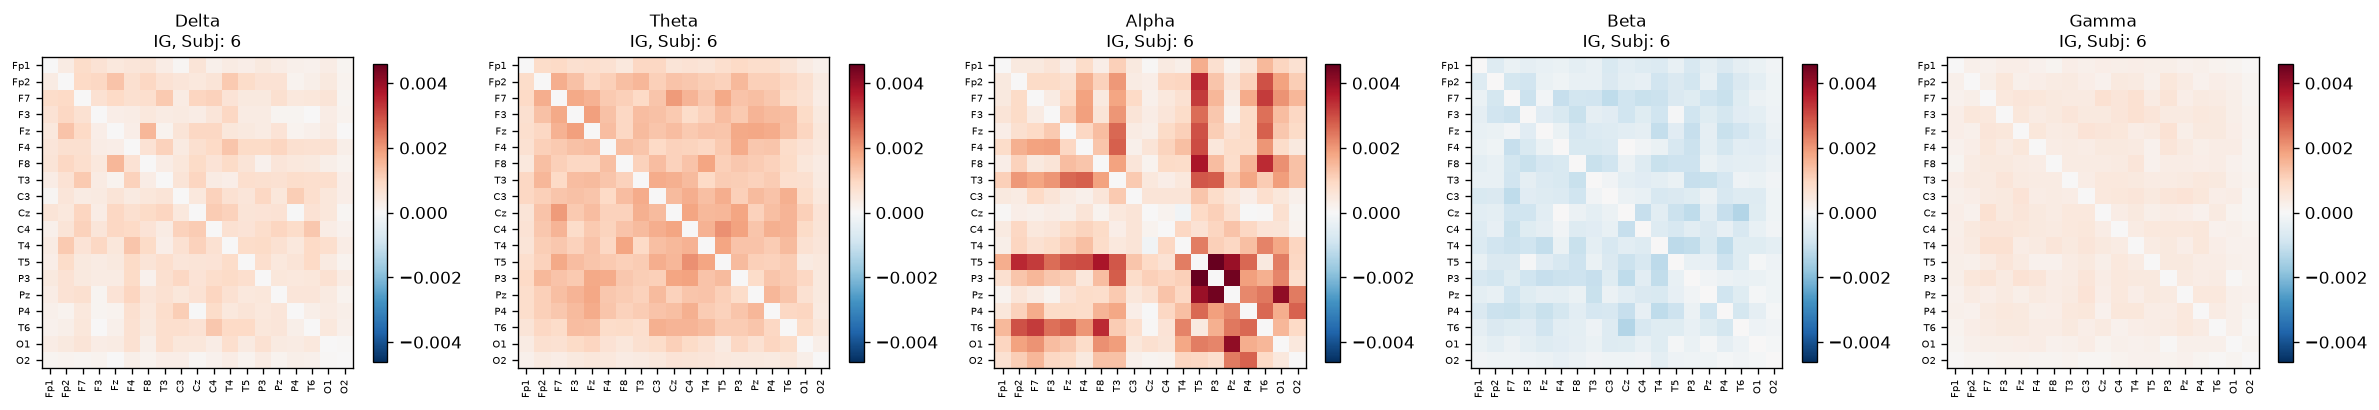


Subject: 11 | True: AD | Predicted: CN | Mean P(AD): 0.482


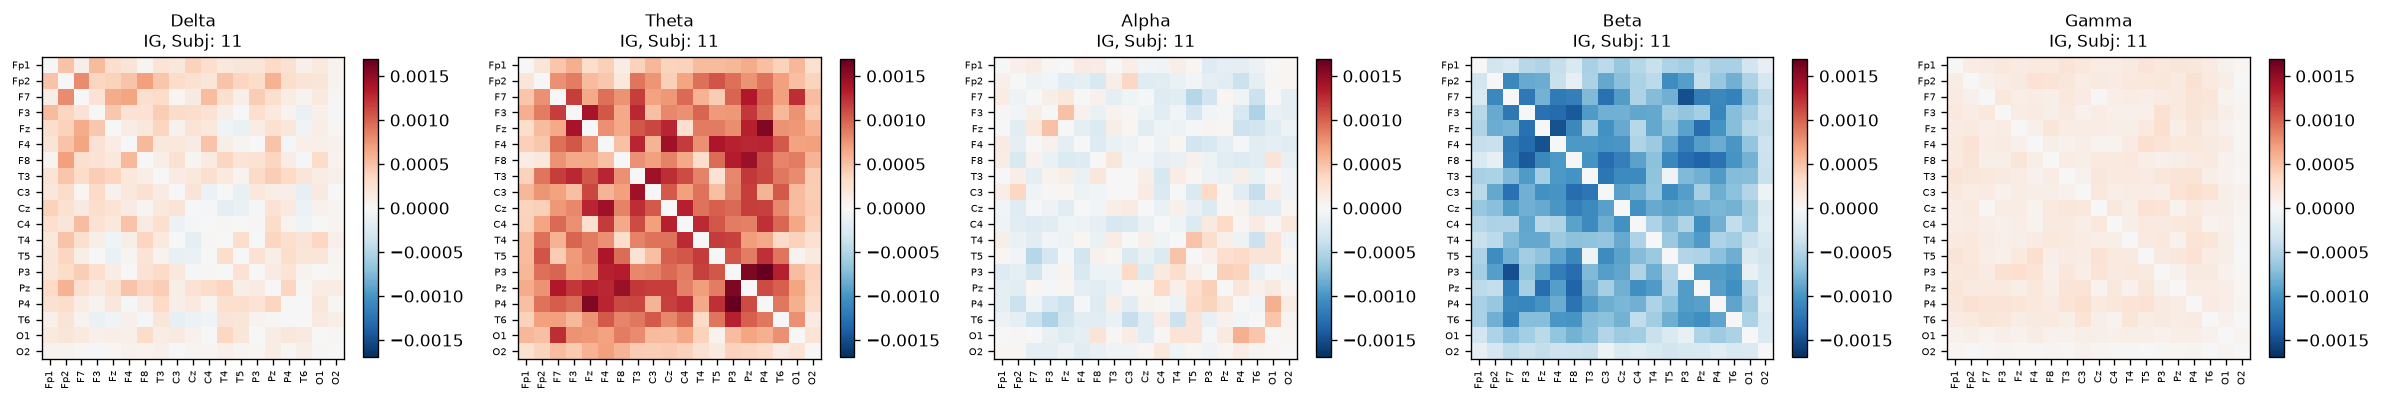


Subject: 15 | True: AD | Predicted: CN | Mean P(AD): 0.483


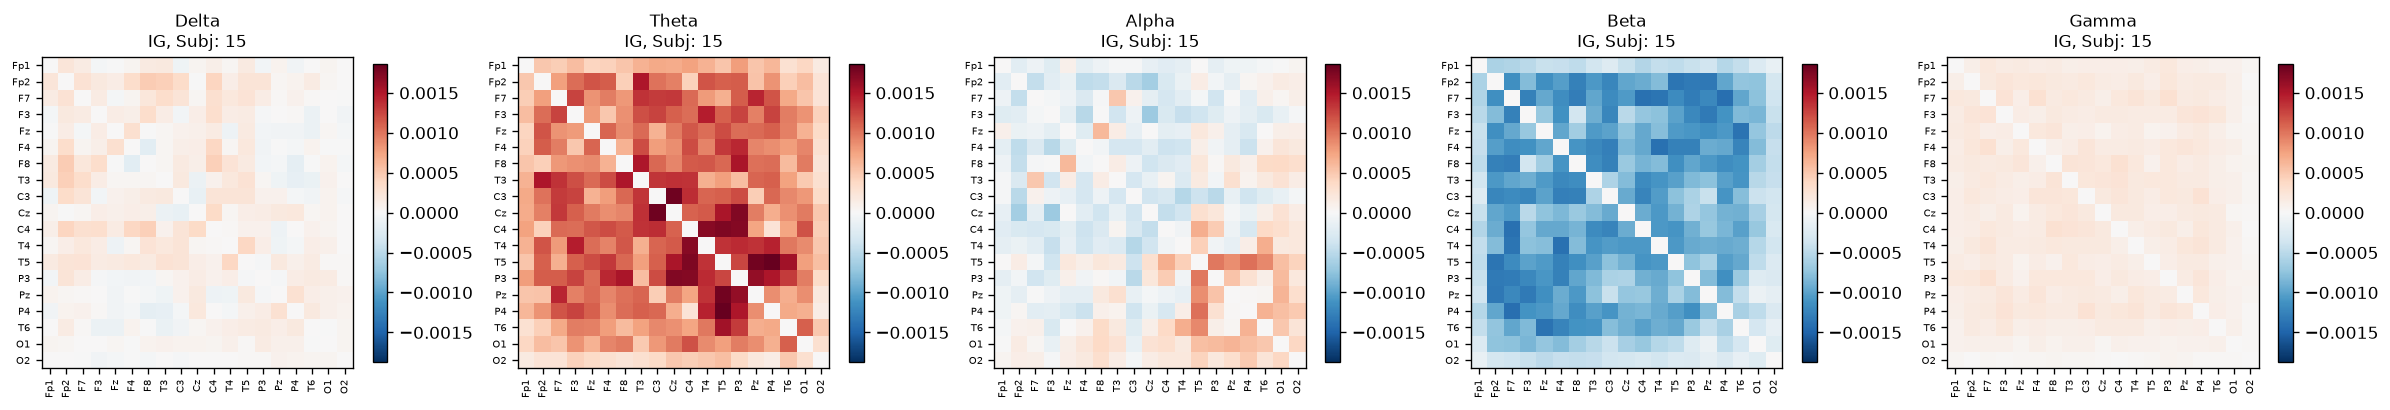


Subject: 33 | True: AD | Predicted: CN | Mean P(AD): 0.477


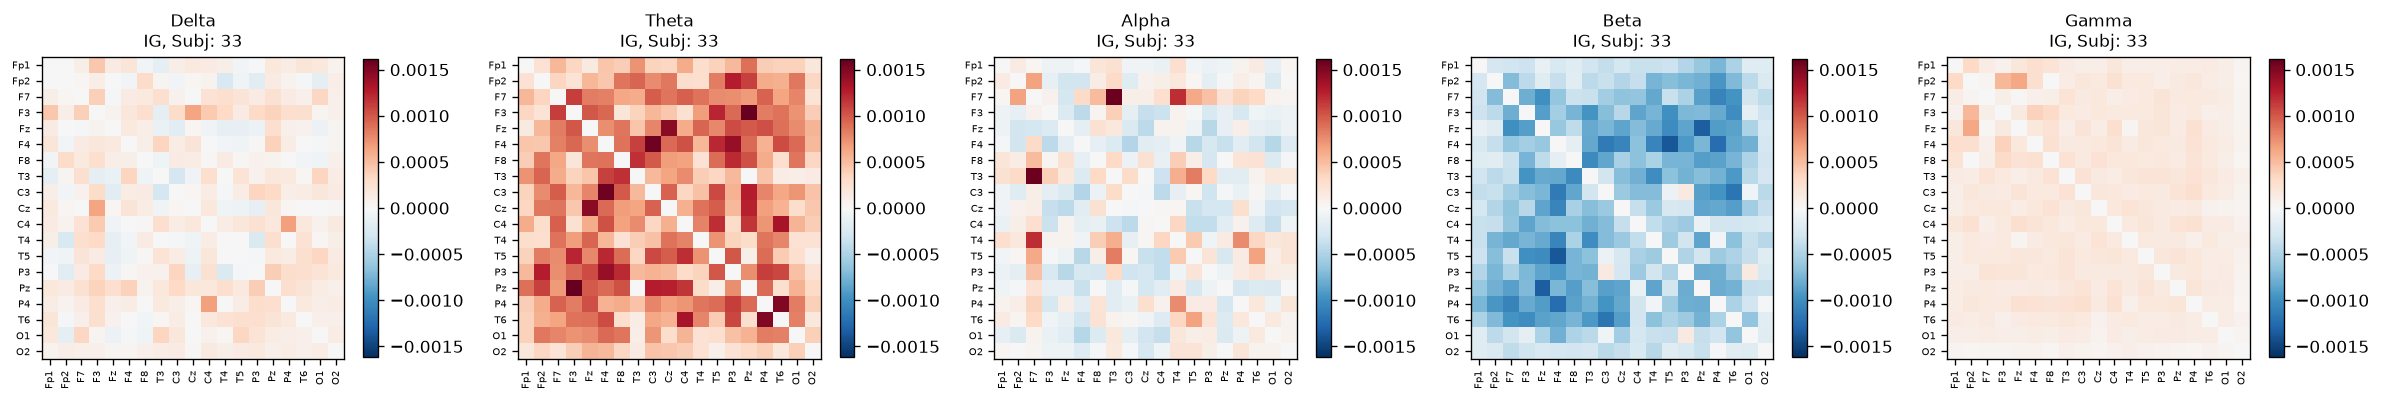

In [7]:
# 3. WRONGLY CLASSIFIED AD : True = AD, Predicted = CN
# ============================================================

wrong_ad = [
subj for subj, meta in subject_meta.items()
if meta["y_true"] == 1 and meta["y_pred"] == 0
]

print(f"Wrongly classified AD subjects: {len(wrong_ad)}")
print(wrong_ad)

for subj in wrong_ad:
    attrib_subj = all_subject_ig[subj]


    print(
        f"\nSubject: {subj} | "
        f"True: AD | "
        f"Predicted: CN | "
        f"Mean P(AD): {subject_meta[subj]['mean_prob_ad']:.3f}"
    )

    plot_subject_attribution(
        attrib_subj,
        subject_id=subj,
        method="IG",
        channel_labels=channel_names,
    )



### False Positive

Wrongly classified CN subjects: 7
[np.int64(43), np.int64(60), np.int64(57), np.int64(52), np.int64(55), np.int64(65), np.int64(61)]

Subject: 43 | True: CN | Predicted: AD | Mean P(AD): 0.534


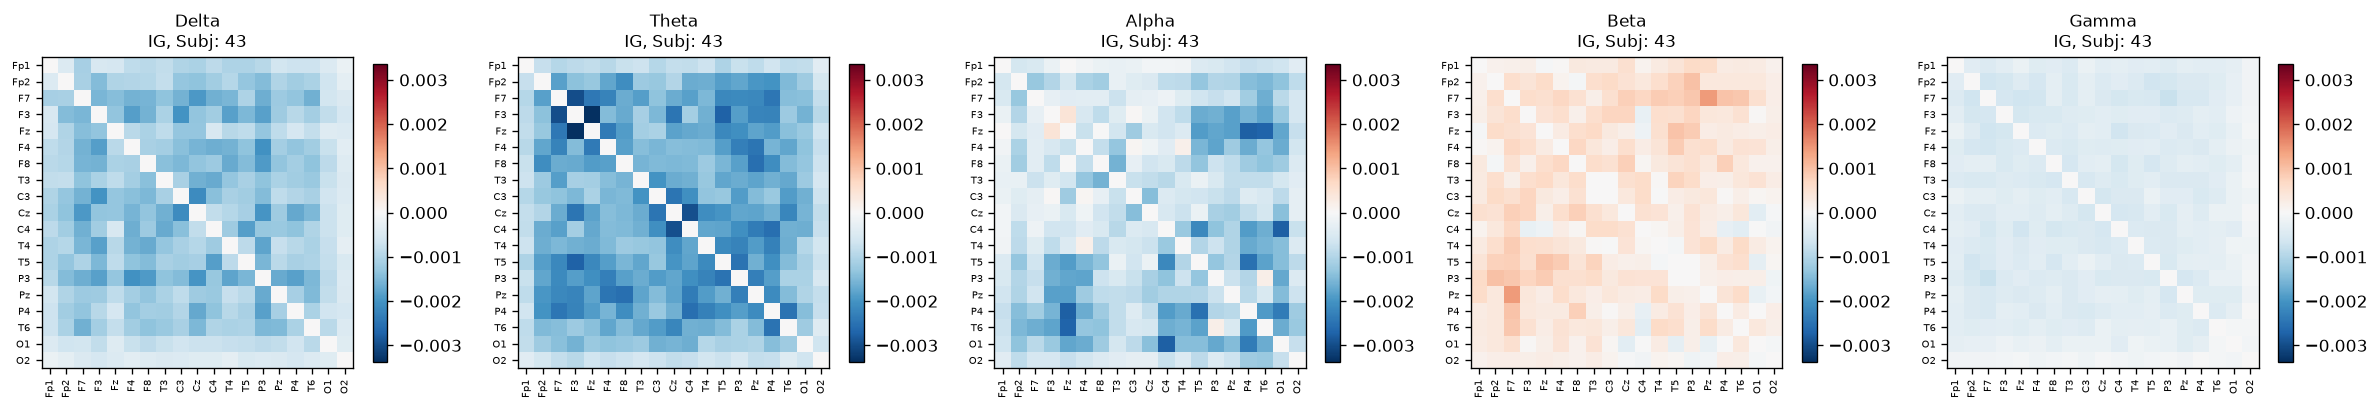


Subject: 60 | True: CN | Predicted: AD | Mean P(AD): 0.501


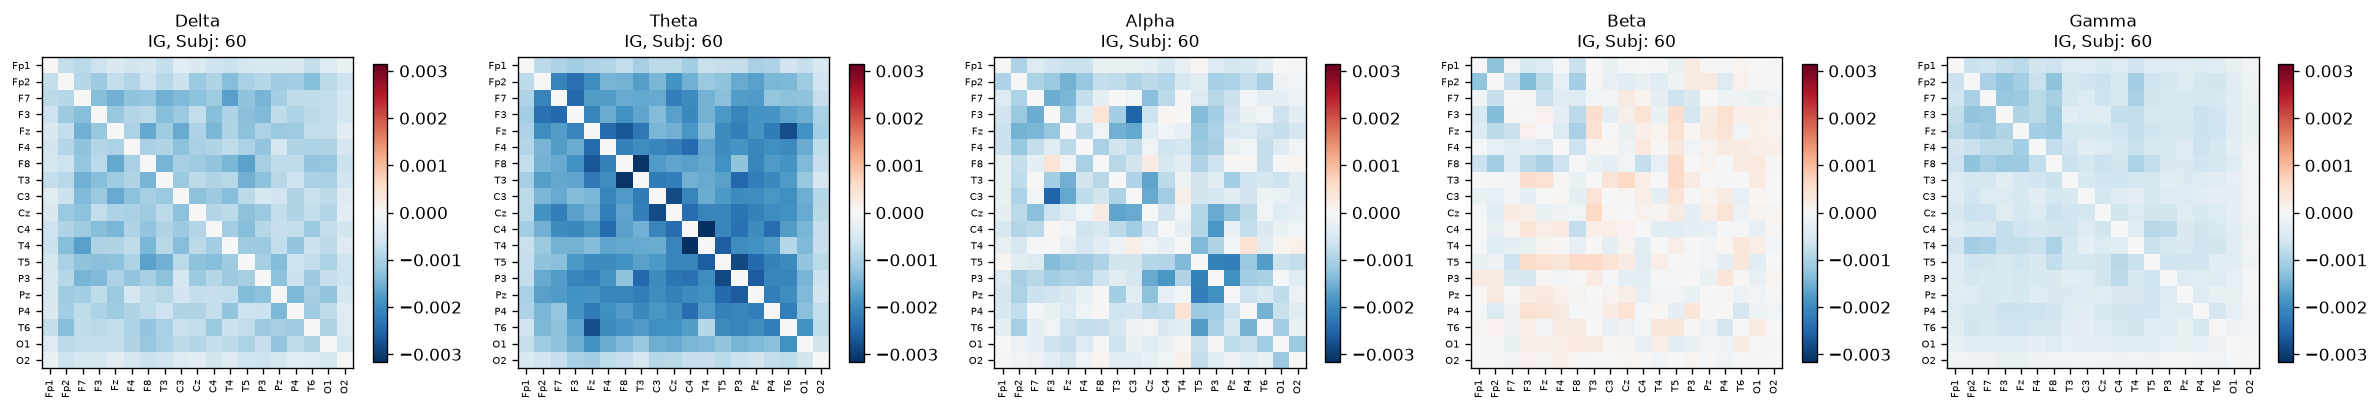


Subject: 57 | True: CN | Predicted: AD | Mean P(AD): 0.502


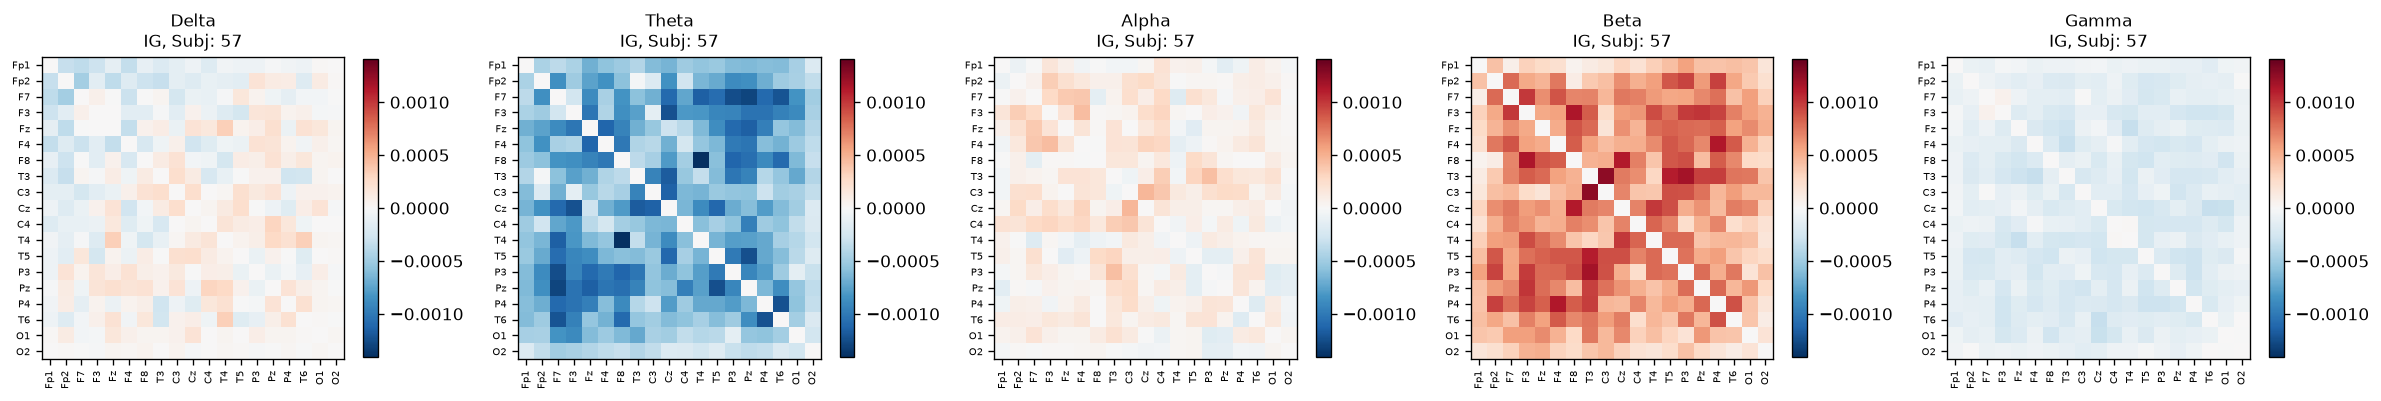


Subject: 52 | True: CN | Predicted: AD | Mean P(AD): 0.506


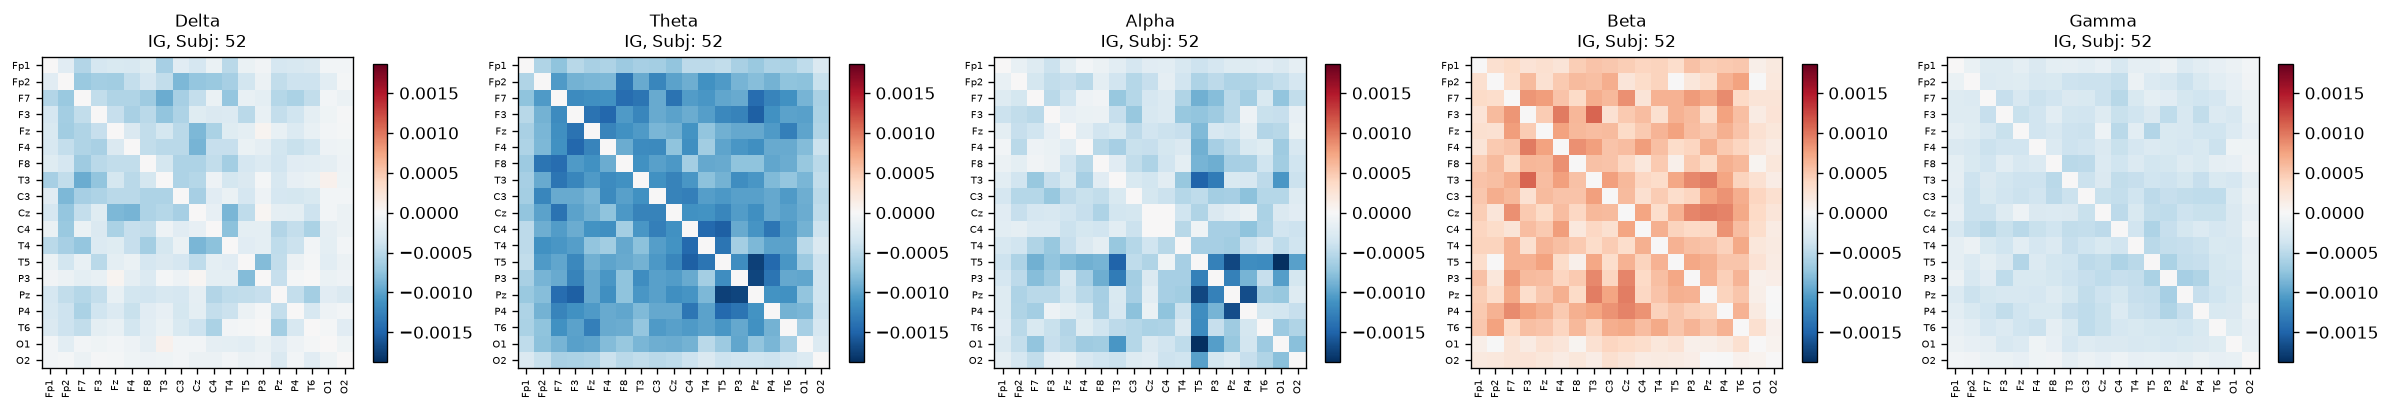


Subject: 55 | True: CN | Predicted: AD | Mean P(AD): 0.511


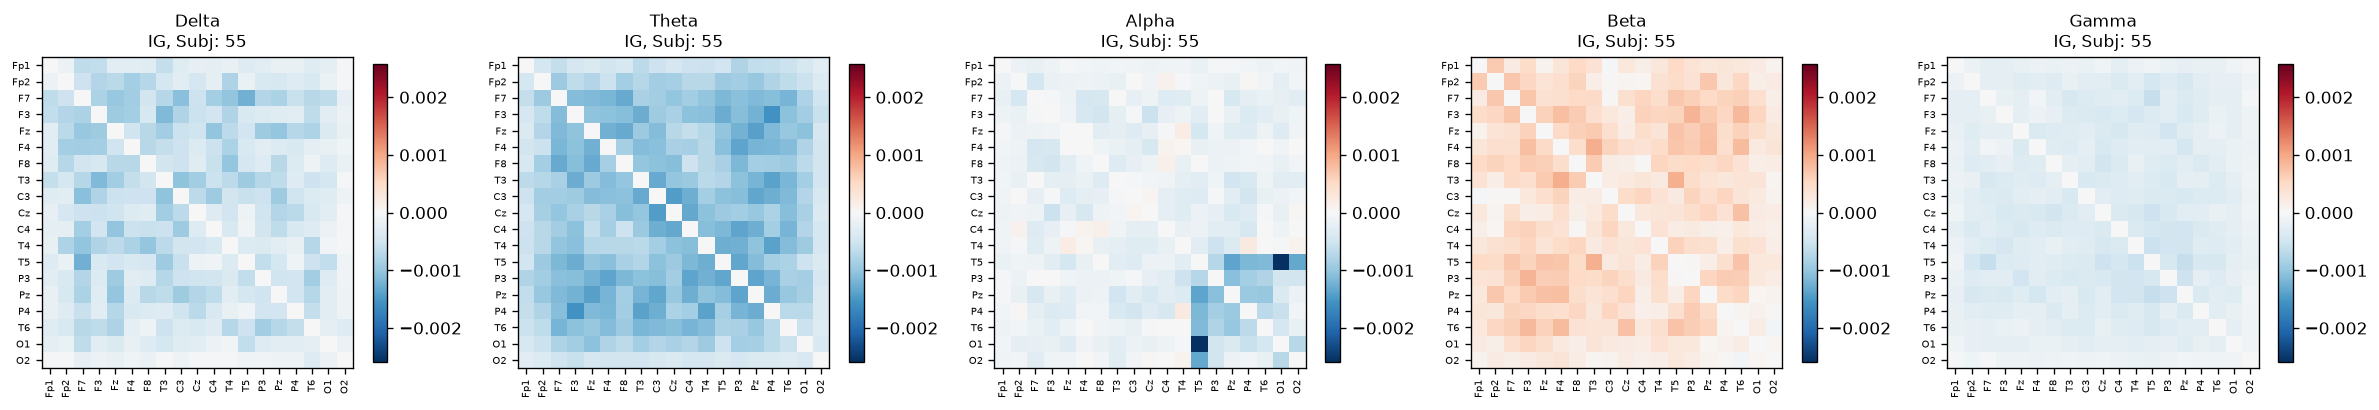


Subject: 65 | True: CN | Predicted: AD | Mean P(AD): 0.546


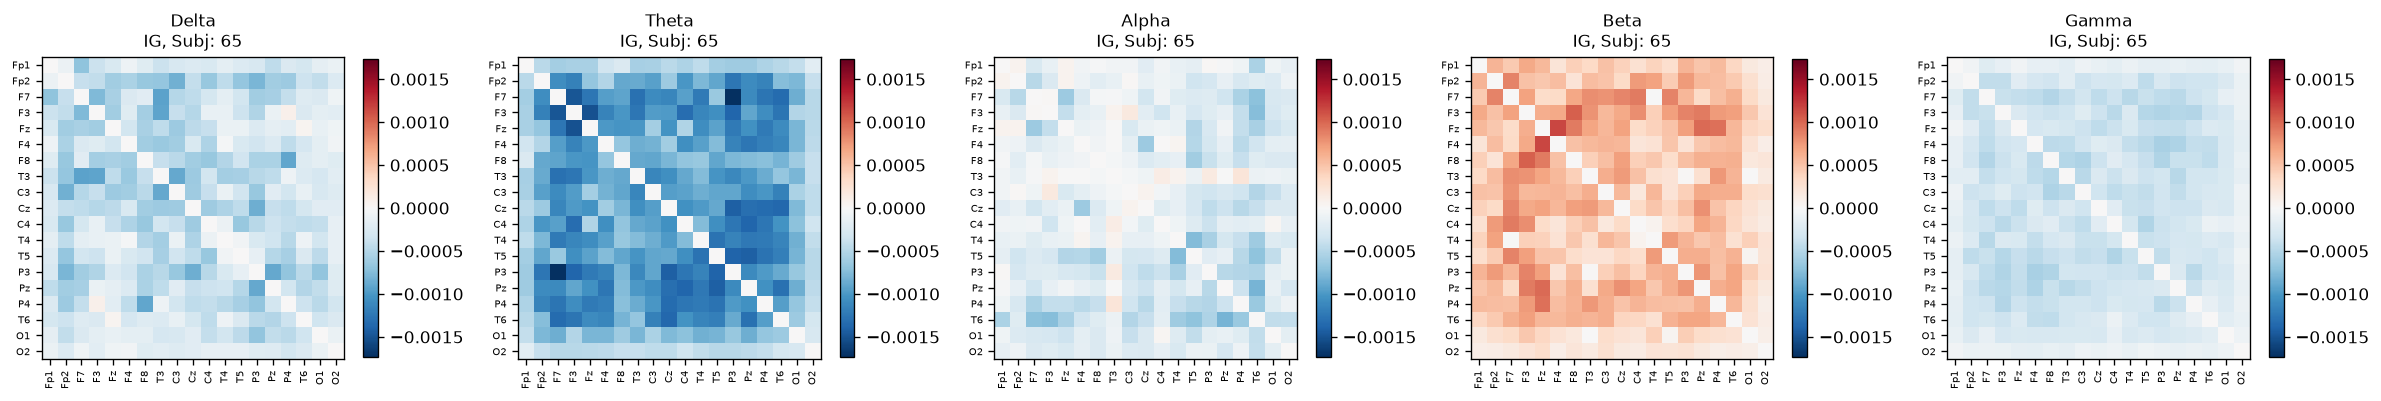


Subject: 61 | True: CN | Predicted: AD | Mean P(AD): 0.502


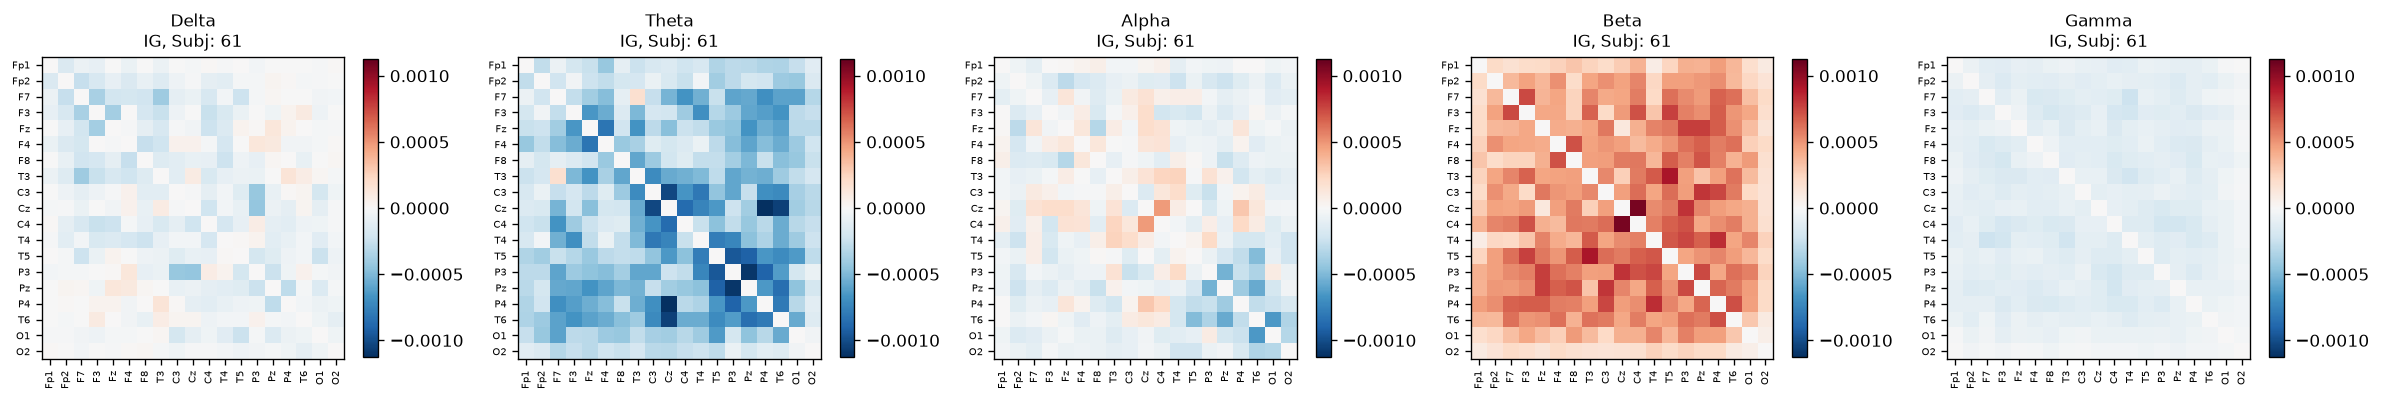

In [8]:
# 4. WRONGLY CLASSIFIED CN : True = CN, Predicted = AD
# ============================================================

wrong_cn = [
subj for subj, meta in subject_meta.items()
if meta["y_true"] == 0 and meta["y_pred"] == 1
]

print(f"Wrongly classified CN subjects: {len(wrong_cn)}")
print(wrong_cn)

for subj in wrong_cn:
    attrib_subj = all_subject_ig[subj]


    print(
        f"\nSubject: {subj} | "
        f"True: CN | "
        f"Predicted: AD | "
        f"Mean P(AD): {subject_meta[subj]['mean_prob_ad']:.3f}"
    )

    plot_subject_attribution(
        attrib_subj,
        subject_id=subj,
        method="IG",
        channel_labels=channel_names,
    )



# Build subject labels and aggregate group importance

In [9]:
all_subject_ig_diff = {}
subject_outer_fold = {}

for fold_idx, loaded in all_models.items():

    X_raw_test, y_test, epoch_subject_ids = load_outer_fold_test_data(
        fold_idx=fold_idx,
        data_npz_path=str(DATA_NPZ_PATH),
        folds_dir=str(FOLDS_DIR),
    )

    # Step 1: Filter ONLY correctly predicted subjects
    X_corr, y_corr, subj_ids_corr, correct_sids = (
        get_correctly_classified_subset(
            loaded=loaded,
            X_raw=X_raw_test,
            y=y_test,
            epoch_subject_ids=epoch_subject_ids,
        )
    )

    print(
        f"Fold {fold_idx}: "
        f"Kept {len(correct_sids)}/"
        f"{len(np.unique(epoch_subject_ids))} "
        f"correctly classified subjects."
    )

    if len(X_corr) == 0:
        continue

    # Step 2: Compute logit-difference IG
    A_ig_diff = compute_ig_attributions(
        loaded=loaded,
        X_raw=X_corr,
        use_logit_diff=True,
        batch_size=4,
        n_steps=100
    )

    # Step 3: Aggregate epoch attributions -> subject maps
    subj_ig_diff = aggregate_attributions_to_subjects(
        A_ig_diff,
        subj_ids_corr
    )

    # Store subject-level maps
    all_subject_ig_diff.update(subj_ig_diff)

    # NEW: remember which outer fold each subject belongs to
    subject_outer_fold.update({
        subj: fold_idx
        for subj in subj_ig_diff
    })


print(
    f"\nTotal correctly predicted subjects across all folds: "
    f"{len(all_subject_ig_diff)}"
)

[data] Filtered to binary task AD vs CN: 4875 epochs from 65 subjects (36 AD, 29 CN)
[load_outer_fold_test_data] Fold 0: 975 test epochs across 13 subjects.
Fold 0: Kept 8/13 correctly classified subjects.
[data] Filtered to binary task AD vs CN: 4875 epochs from 65 subjects (36 AD, 29 CN)
[load_outer_fold_test_data] Fold 1: 975 test epochs across 13 subjects.
Fold 1: Kept 10/13 correctly classified subjects.
[data] Filtered to binary task AD vs CN: 4875 epochs from 65 subjects (36 AD, 29 CN)
[load_outer_fold_test_data] Fold 2: 975 test epochs across 13 subjects.
Fold 2: Kept 10/13 correctly classified subjects.
[data] Filtered to binary task AD vs CN: 4875 epochs from 65 subjects (36 AD, 29 CN)
[load_outer_fold_test_data] Fold 3: 975 test epochs across 13 subjects.
Fold 3: Kept 8/13 correctly classified subjects.
[data] Filtered to binary task AD vs CN: 4875 epochs from 65 subjects (36 AD, 29 CN)
[load_outer_fold_test_data] Fold 4: 975 test epochs across 13 subjects.
Fold 4: Kept 9/13

# Plot AD, CN, and AD − CN maps

In [10]:
subject_labels = {
    subj: meta["y_true"]
    for subj, meta in subject_meta.items()
}

group_ig_diff = aggregate_group_importance(all_subject_ig_diff, subject_labels)

band_names = ["Delta", "Theta", "Alpha", "Beta", "Gamma"]
ad_band = group_ig_diff[1]["mean_abs"].mean(axis=(1, 2))
cn_band = group_ig_diff[0]["mean_abs"].mean(axis=(1, 2))
for b, name in enumerate(band_names):
    print(f"{name:8s}  AD: {ad_band[b]:.4f}   CN: {cn_band[b]:.4f}")

diff_map = group_ig_diff[1]["mean_signed"] - group_ig_diff[0]["mean_signed"]


# ------------------------------------------------------------
# Quantitative band-level summary of AD - CN difference map
# ------------------------------------------------------------

band_names = ["Delta", "Theta", "Alpha", "Beta", "Gamma"]

# Mean absolute difference: magnitude of attribution difference
band_abs_diff = np.mean(np.abs(diff_map), axis=(1, 2))

# Mean signed difference: direction of attribution difference
band_signed_diff = np.mean(diff_map, axis=(1, 2))

print("\nBand-level AD - CN attribution difference:")
for b, name in enumerate(band_names):
    print(
        f"{name:8s} | "
        f"mean |diff| = {band_abs_diff[b]:.4f} | "
        f"mean signed diff = {band_signed_diff[b]:+.4f}"
    )


Delta     AD: 0.0007   CN: 0.0006
Theta     AD: 0.0015   CN: 0.0016
Alpha     AD: 0.0006   CN: 0.0009
Beta      AD: 0.0009   CN: 0.0007
Gamma     AD: 0.0005   CN: 0.0005

Band-level AD - CN attribution difference:
Delta    | mean |diff| = 0.0001 | mean signed diff = -0.0000
Theta    | mean |diff| = 0.0002 | mean signed diff = +0.0001
Alpha    | mean |diff| = 0.0004 | mean signed diff = +0.0004
Beta     | mean |diff| = 0.0003 | mean signed diff = +0.0003
Gamma    | mean |diff| = 0.0001 | mean signed diff = -0.0000


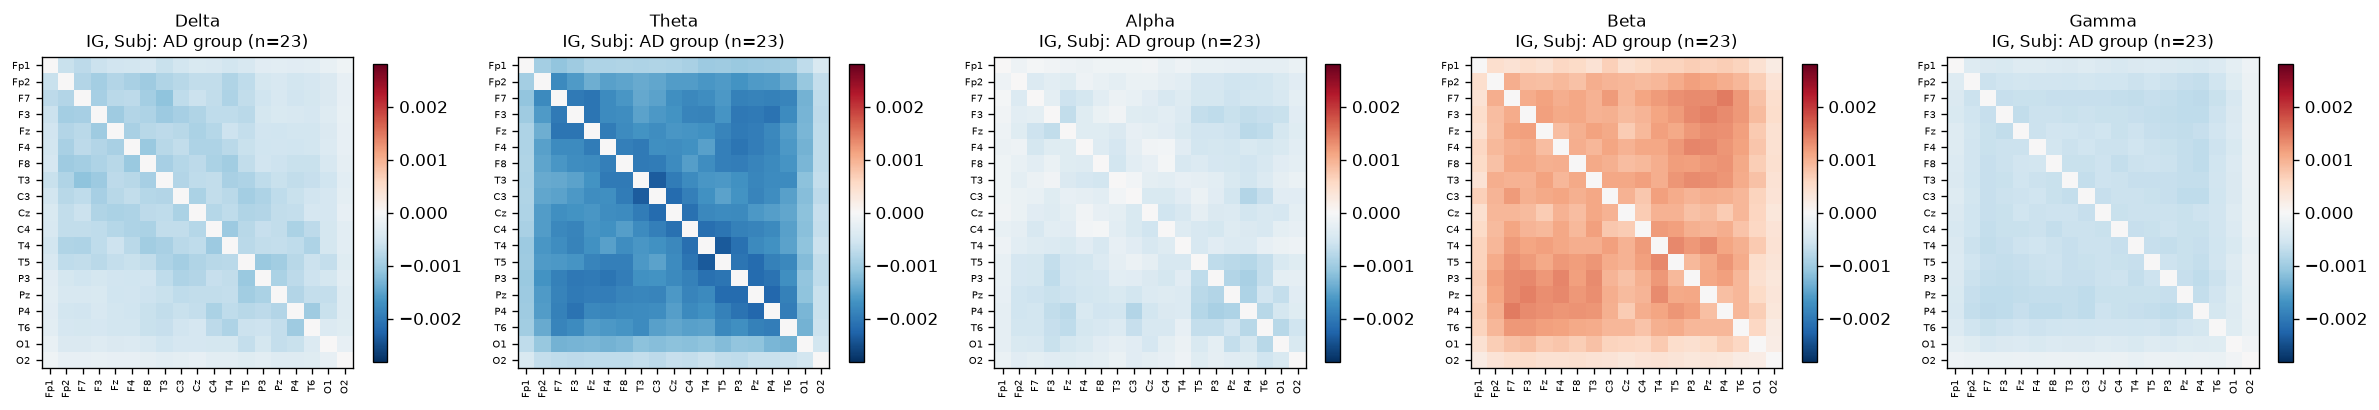

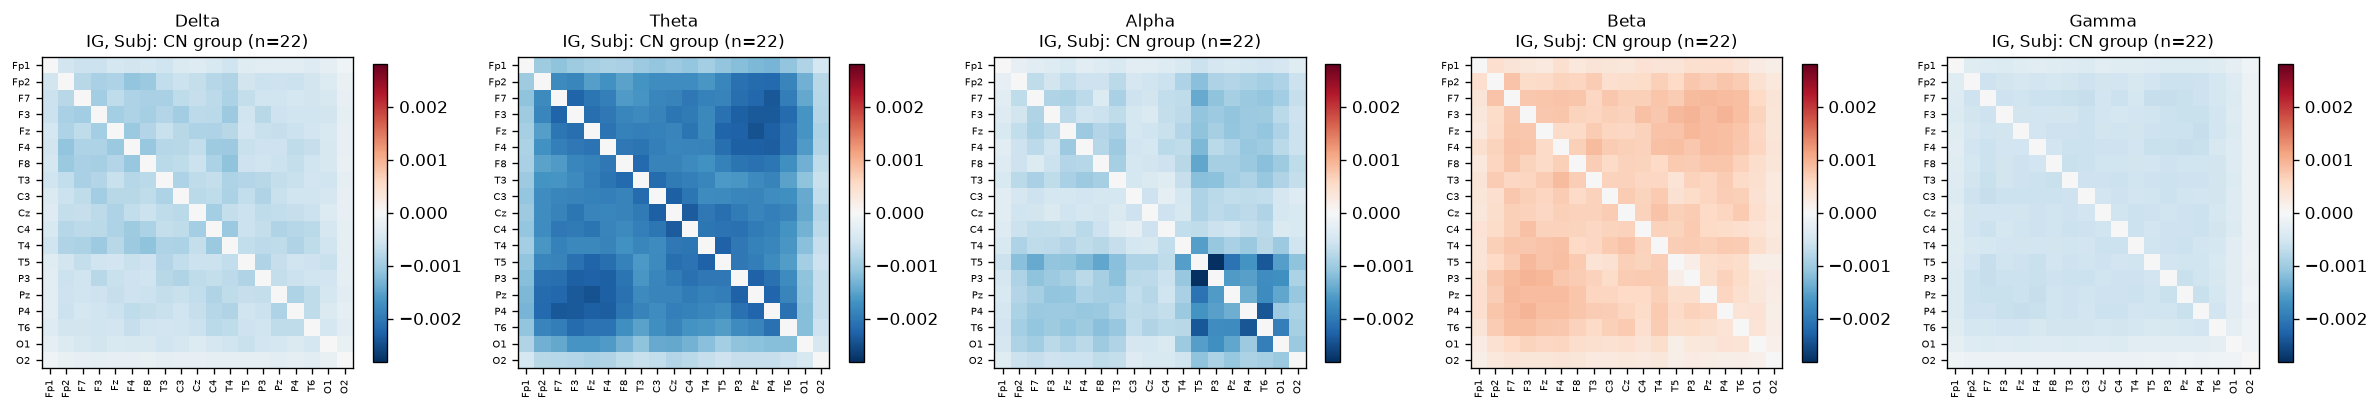

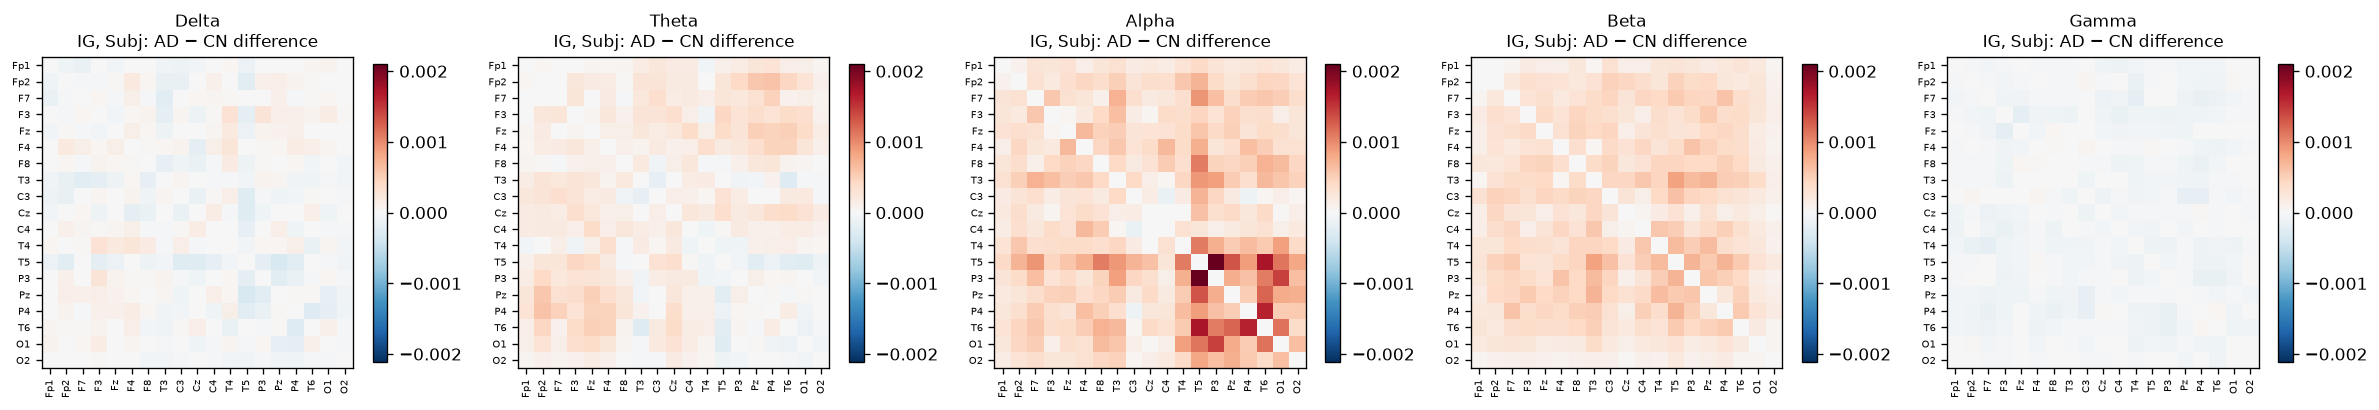

In [12]:
shared_vmax = max(np.max(np.abs(group_ig_diff[1]["mean_signed"])), np.max(np.abs(group_ig_diff[0]["mean_signed"])))
shared_vmin = -shared_vmax

channel_labels = ["Fp1","Fp2", "F7", "F3", "Fz", "F4", "F8","T3", "C3", "Cz", "C4", "T4","T5", "P3", "Pz", "P4", "T6", "O1", "O2"],
plot_subject_attribution(group_ig_diff[1]["mean_signed"], subject_id=f"AD group (n={group_ig_diff[1]['n_subjects']})", 
                                                                                    method="IG",
                                                                                    channel_labels = anterior_to_posterior,
                                                                                    vmin=shared_vmin, vmax=shared_vmax)
                                                                                    
plot_subject_attribution(group_ig_diff[0]["mean_signed"], subject_id=f"CN group (n={group_ig_diff[0]['n_subjects']})", 
                                                                                    method="IG",
                                                                                    channel_labels = anterior_to_posterior, 
                                                                                    vmin=shared_vmin, vmax=shared_vmax)
                                                                                    
plot_subject_attribution(diff_map, subject_id="AD − CN difference", method="IG", channel_labels = anterior_to_posterior,)

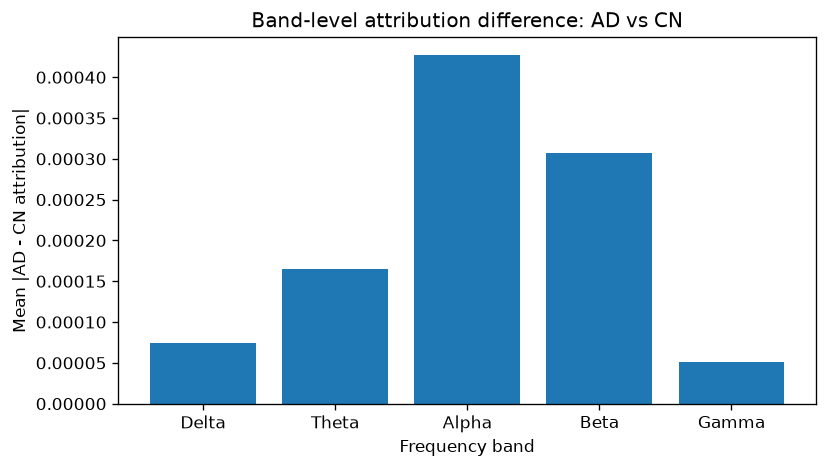

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

plt.bar(band_names, band_abs_diff)

plt.ylabel("Mean |AD - CN attribution|")
plt.xlabel("Frequency band")
plt.title("Band-level attribution difference: AD vs CN")

plt.tight_layout()
plt.show()

In [14]:
import pandas as pd
# ------------------------------------------------------------
# Top channel pairs from the AD - CN difference map
# ------------------------------------------------------------

top_n = 15

rows = []

for b, band in enumerate(band_names):
    for i in range(len(channel_names)):
        for j in range(i + 1, len(channel_names)):
            value = diff_map[b, i, j]

            rows.append({
                "Band": band,
                "Channel A": channel_names[i],
                "Channel B": channel_names[j],
                "Attribution": value,
                "Abs Attribution": abs(value),
            })

top_pairs = (
    pd.DataFrame(rows)
    .sort_values("Abs Attribution", ascending=False)
    .head(top_n)
    .reset_index(drop=True)
)

top_pairs.insert(0, "Rank", np.arange(1, len(top_pairs) + 1))

print("\nTop channel pairs in AD - CN difference map:")
display(top_pairs)


Top channel pairs in AD - CN difference map:


,Rank,Band,Channel A,Channel B,Attribution,Abs Attribution
0,1,Alpha,T5,P3,0.002107,0.002107
1,2,Alpha,T5,T6,0.001721,0.001721
2,3,Alpha,P4,T6,0.001627,0.001627
3,4,Alpha,P3,O1,0.001439,0.001439
4,5,Alpha,T5,Pz,0.001321,0.001321
5,6,Alpha,Pz,T6,0.001227,0.001227
6,7,Alpha,T6,O1,0.001147,0.001147
7,8,Alpha,T5,O1,0.001131,0.001131
8,9,Alpha,T4,T5,0.001089,0.001089
9,10,Alpha,P3,T6,0.001086,0.001086


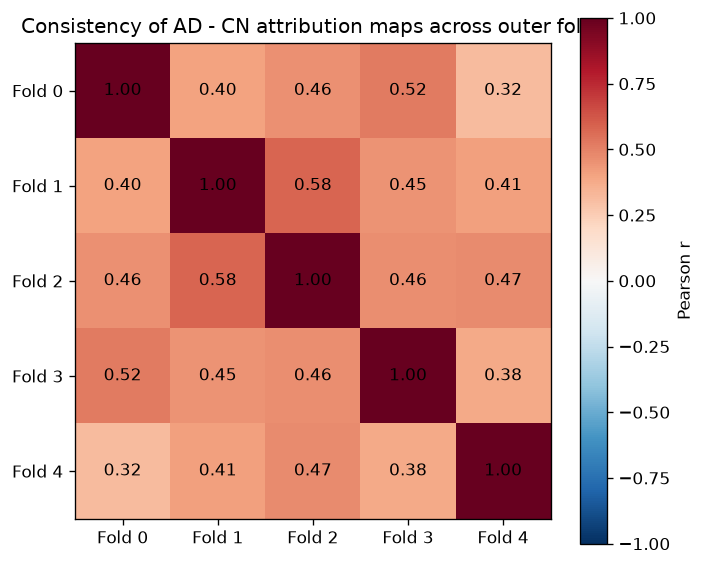


Mean pairwise fold correlation:   r = 0.446
Median pairwise fold correlation: r = 0.455


In [17]:
# ------------------------------------------------------------
# Outer-fold robustness: AD - CN difference map per fold
# ------------------------------------------------------------

fold_diff_maps = {}

for fold in sorted(set(subject_outer_fold.values())):

    fold_subjects = [
        subj
        for subj in all_subject_ig_diff
        if subject_outer_fold[subj] == fold
    ]

    fold_ad = [
        all_subject_ig_diff[subj]
        for subj in fold_subjects
        if subject_labels[subj] == 1
    ]

    fold_cn = [
        all_subject_ig_diff[subj]
        for subj in fold_subjects
        if subject_labels[subj] == 0
    ]

    fold_ad_mean = np.mean(fold_ad, axis=0)
    fold_cn_mean = np.mean(fold_cn, axis=0)

    fold_diff_maps[fold] = fold_ad_mean - fold_cn_mean

folds = sorted(fold_diff_maps.keys())

fold_vectors = {
    fold: fold_diff_maps[fold].ravel()
    for fold in folds
}

fold_corr = np.zeros((len(folds), len(folds)))

for i, fold_i in enumerate(folds):
    for j, fold_j in enumerate(folds):
        fold_corr[i, j] = np.corrcoef(
            fold_vectors[fold_i],
            fold_vectors[fold_j]
        )[0, 1]


plt.figure(figsize=(6, 5))

plt.imshow(fold_corr, vmin=-1, vmax=1)

plt.xticks(range(len(folds)), [f"Fold {f}" for f in folds])
plt.yticks(range(len(folds)), [f"Fold {f}" for f in folds])

plt.colorbar(label="Pearson r")
plt.title("Consistency of AD - CN attribution maps across outer folds")

for i in range(len(folds)):
    for j in range(len(folds)):
        plt.text(
            j, i,
            f"{fold_corr[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

# Mean pairwise correlation, excluding diagonal
upper_triangle = fold_corr[np.triu_indices_from(fold_corr, k=1)]

mean_fold_corr = np.mean(upper_triangle)
median_fold_corr = np.median(upper_triangle)

print(f"\nMean pairwise fold correlation:   r = {mean_fold_corr:.3f}")
print(f"Median pairwise fold correlation: r = {median_fold_corr:.3f}")    